# Acomodo mapper

## Librerías

In [3]:
import pandas as pd
import numpy as np
import random

import plotly
import requests
from bs4 import BeautifulSoup
import ruptures as rpt
import yfinance as yf

import plotly.graph_objects as go
import matplotlib.pyplot as plt

import kmapper as km
import subprocess
import sys
import networkx as nx
subprocess.check_call([sys.executable, "-m", "pip", "install", "plotly", "nbformat>=4.2.0"])
import sklearn.cluster

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.cluster import DBSCAN, KMeans
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots


ModuleNotFoundError: No module named 'pandas'

## Recolección de datos

### Sacar tickers S&P500

In [9]:

# URL de la lista del S&P 500
url = "https://www.slickcharts.com/sp500"


# Hacer la petición con headers para evitar bloqueos
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
}
response = requests.get(url, headers=headers)
response.raise_for_status()  # Raise exception for bad status codes

# Parsear el HTML
soup = BeautifulSoup(response.text, 'html.parser')

# Encontrar la tabla
table = soup.find('table')

if table:
    # Leer la tabla con pandas
    df = pd.read_html(str(table))[0]
    
    # Extraer los tickers
    if 'Symbol' in df.columns:
        tickers = df['Symbol'].tolist()
        print(f"Found {len(tickers)} tickers")
        print("First 10 tickers:", tickers[:10])
    else:
        print("Available columns:", df.columns.tolist())

    # Extraer los pesos
    if 'Weight' in df.columns:
        weights = df['Weight'].tolist()
        print(f"Found {len(weights)} weights")
        print("First 10 weights:", weights[:10])
    else:
        print("Available columns:", df.columns.tolist())
else:
    print("No table found on the page")

# En la lista de ticker, reemplazar los "." por "-"
tickers = [ticker.replace('.', '-') for ticker in tickers]
print("Tickers after replacement:", tickers[:10])

Found 503 tickers
First 10 tickers: ['NVDA', 'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'AVGO', 'GOOG', 'META', 'TSLA', 'BRK.B']
Found 503 weights
First 10 weights: ['7.90%', '6.55%', '6.27%', '4.37%', '2.84%', '2.72%', '2.66%', '2.59%', '2.42%', '1.72%']
Tickers after replacement: ['NVDA', 'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'AVGO', 'GOOG', 'META', 'TSLA', 'BRK-B']


### Información financiera

In [10]:
# =======================================================
# 📊 RECOPILACIÓN DE INFORMACIÓN FUNDAMENTAL DE TICKERS
# =======================================================

import os

# Verificar si el archivo ya existe
csv_filename = 'sp500_ticker_info_database.csv'

if os.path.exists(csv_filename):
    # ✅ ARCHIVO EXISTE - Cargar datos existentes
    print("✅ Archivo 'sp500_ticker_info_database.csv' encontrado")
    print("📂 Cargando información desde archivo guardado...")
    print("=" * 80)
    
    try:
        ticker_info_df = pd.read_csv(csv_filename, index_col=0)
        
        # Convertir DataFrame a diccionario para ticker_info_db
        ticker_info_db = ticker_info_df.to_dict('index')
        
        print(f"✅ Datos cargados exitosamente")
        print(f"   📊 Total de tickers: {len(ticker_info_df)}")
        print(f"   📋 Columnas: {len(ticker_info_df.columns)}")
        print(f"\n💡 Para actualizar los datos, elimina el archivo '{csv_filename}' y vuelve a ejecutar esta celda")
        
    except Exception as e:
        print(f"❌ Error al cargar el archivo: {e}")
        print(f"⚠️  Se procederá a descargar los datos nuevamente...")
        # Si hay error, forzar descarga
        os.remove(csv_filename) if os.path.exists(csv_filename) else None
        ticker_info_df = None

else:
    # ❌ ARCHIVO NO EXISTE - Descargar información
    print("⚠️  Archivo 'sp500_ticker_info_database.csv' no encontrado")
    print("🔍 Descargando información detallada de todos los tickers del S&P 500...")
    print("⏱️  Esto puede tardar varios minutos...")
    print("=" * 80)
    
    ticker_info_db = {}
    failed_tickers = []
    
    for idx, ticker in enumerate(tickers, 1):
        try:
            # Mostrar progreso cada 50 tickers
            if idx % 50 == 0 or idx == 1:
                print(f"   Procesando ticker {idx}/{len(tickers)}: {ticker}")
            
            stock = yf.Ticker(ticker)
            info = stock.info
            
            # Extraer información relevante
            ticker_info_db[ticker] = {
                # Información básica
                'sector': info.get('sector', 'Unknown'),
                'industry': info.get('industry', 'Unknown'),
                'market_cap': info.get('marketCap', None),
                'country': info.get('country', 'Unknown'),
                'full_name': info.get('longName', ticker),
                
                # Métricas de valoración
                'pe_ratio': info.get('trailingPE', None),
                'forward_pe': info.get('forwardPE', None),
                'peg_ratio': info.get('pegRatio', None),
                'price_to_book': info.get('priceToBook', None),
                'price_to_sales': info.get('priceToSalesTrailing12Months', None),
                'enterprise_value': info.get('enterpriseValue', None),
                'ev_to_ebitda': info.get('enterpriseToEbitda', None),
                
                # Dividendos
                'dividend_yield': info.get('dividendYield', None),
                'dividend_rate': info.get('dividendRate', None),
                'payout_ratio': info.get('payoutRatio', None),
                'five_year_avg_dividend_yield': info.get('fiveYearAvgDividendYield', None),
                
                # Rentabilidad
                'profit_margins': info.get('profitMargins', None),
                'operating_margins': info.get('operatingMargins', None),
                'gross_margins': info.get('grossMargins', None),
                'roe': info.get('returnOnEquity', None),
                'roa': info.get('returnOnAssets', None),
                
                # Crecimiento
                'revenue_growth': info.get('revenueGrowth', None),
                'earnings_growth': info.get('earningsGrowth', None),
                'earnings_quarterly_growth': info.get('earningsQuarterlyGrowth', None),
                
                # Riesgo y volatilidad
                'beta': info.get('beta', None),
                '52week_high': info.get('fiftyTwoWeekHigh', None),
                '52week_low': info.get('fiftyTwoWeekLow', None),
                '52week_change': info.get('52WeekChange', None),
                
                # Liquidez y deuda
                'current_ratio': info.get('currentRatio', None),
                'quick_ratio': info.get('quickRatio', None),
                'debt_to_equity': info.get('debtToEquity', None),
                'total_debt': info.get('totalDebt', None),
                'total_cash': info.get('totalCash', None),
                
                # Analistas y recomendaciones
                'recommendation': info.get('recommendationKey', 'Unknown'),
                'recommendation_mean': info.get('recommendationMean', None),
                'target_mean_price': info.get('targetMeanPrice', None),
                'target_high_price': info.get('targetHighPrice', None),
                'target_low_price': info.get('targetLowPrice', None),
                'number_of_analysts': info.get('numberOfAnalystOpinions', None),
                
                # Información adicional
                'employees': info.get('fullTimeEmployees', None),
                'exchange': info.get('exchange', 'Unknown'),
                'quote_type': info.get('quoteType', 'Unknown'),
            }
            
        except Exception as e:
            failed_tickers.append(ticker)
            ticker_info_db[ticker] = {
                'sector': 'Unknown',
                'industry': 'Unknown',
                'error': str(e)
            }
    
    print(f"\n{'='*80}")
    print(f"📊 RESUMEN DE DESCARGA:")
    print(f"   ✅ Tickers procesados: {len(ticker_info_db)}")
    if failed_tickers:
        print(f"   ❌ Tickers fallidos ({len(failed_tickers)}): {', '.join(failed_tickers[:10])}{'...' if len(failed_tickers) > 10 else ''}")
    
    # Crear DataFrame para análisis fácil
    ticker_info_df = pd.DataFrame.from_dict(ticker_info_db, orient='index')
    
    print(f"\n   📋 DataFrame de información creado: {ticker_info_df.shape}")
    
    # Guardar en CSV para uso posterior
    ticker_info_df.to_csv(csv_filename)
    print(f"   💾 Base de datos guardada en '{csv_filename}'")

# Mostrar primeras filas (común para ambos casos)
print(f"\n{'='*80}")
print("📋 Primeras filas de la base de datos:")
display(ticker_info_df.head(10))

✅ Archivo 'sp500_ticker_info_database.csv' encontrado
📂 Cargando información desde archivo guardado...
✅ Datos cargados exitosamente
   📊 Total de tickers: 503
   📋 Columnas: 43

💡 Para actualizar los datos, elimina el archivo 'sp500_ticker_info_database.csv' y vuelve a ejecutar esta celda

📋 Primeras filas de la base de datos:


,sector,industry,market_cap,country,full_name,pe_ratio,forward_pe,peg_ratio,price_to_book,price_to_sales,...,recommendation,recommendation_mean,target_mean_price,target_high_price,target_low_price,number_of_analysts,employees,exchange,quote_type,error
NVDA,Technology,Semiconductors,5.105445e+12,United States,NVIDIA Corporation,59.912860,50.896847,NaN,50.983470,30.900524,...,strong_buy,1.34375,229.32070,350.00,100.0,57.0,36000.0,NMS,EQUITY,NaN
AAPL,Technology,Consumer Electronics,3.961836e+12,United States,Apple Inc.,35.941017,32.264740,NaN,53.720695,9.519959,...,buy,2.00000,278.01633,345.00,200.0,41.0,166000.0,NMS,EQUITY,NaN
MSFT,Technology,Software - Infrastructure,3.842837e+12,United States,Microsoft Corporation,36.721590,34.584614,NaN,10.586404,13.079236,...,strong_buy,1.21053,626.26500,730.00,483.0,52.0,228000.0,NMS,EQUITY,NaN
AMZN,Consumer Cyclical,Internet Retail,2.734878e+12,United States,"Amazon.com, Inc.",36.134182,41.598373,NaN,7.396709,3.955811,...,strong_buy,1.29851,288.83392,351.87,240.0,61.0,1578000.0,NMS,EQUITY,NaN
GOOGL,Communication Services,Internet Content & Information,3.412471e+12,United States,Alphabet Inc.,27.916010,31.530134,NaN,8.819343,8.852615,...,strong_buy,1.48485,310.16370,360.00,185.0,54.0,190167.0,NMS,EQUITY,NaN
AVGO,Technology,Semiconductors,1.721774e+12,United States,Broadcom Inc.,93.010200,59.092384,NaN,6.156600,28.731674,...,strong_buy,1.28261,392.38165,475.00,273.4,41.0,37000.0,NMS,EQUITY,NaN
GOOG,Communication Services,Internet Content & Information,3.410808e+12,United States,Alphabet Inc.,27.964922,31.620672,NaN,8.834795,8.848301,...,strong_buy,1.49254,298.42776,345.00,185.0,18.0,190167.0,NMS,EQUITY,NaN
META,Communication Services,Internet Content & Information,1.621682e+12,United States,"Meta Platforms, Inc.",28.430845,25.430435,NaN,8.357885,8.559387,...,strong_buy,1.47059,844.74884,1117.00,560.0,60.0,78450.0,NMS,EQUITY,NaN
TSLA,Consumer Cyclical,Auto Manufacturers,1.556932e+12,United States,"Tesla, Inc.",320.640400,144.486110,NaN,19.458600,16.279493,...,hold,2.61702,392.04977,600.00,120.0,41.0,125665.0,NMS,EQUITY,NaN
BRK-B,Financial Services,Insurance - Diversified,1.029713e+12,United States,Berkshire Hathaway Inc.,16.362062,23.777142,NaN,0.001028,2.781873,...,buy,1.75000,528.00000,595.00,479.0,3.0,392400.0,NYQ,EQUITY,NaN


### Datos históricos separados

In [11]:

#START_DATE='2025-04-01'
#END_DATE='2025-10-08'
#AN_DATE='2025-08-01'



START_DATE='2020-01-01'
END_DATE='2025-10-01'
AN_DATE='2025-08-01'

In [12]:
# -----------------------------
# Descargar precios históricos
# -----------------------------
# -----------------------------
# Descargar precios históricos
# -----------------------------
all_tickers_data = yf.download(tickers, start=START_DATE, end=END_DATE, auto_adjust=True)['Close']
all_tickers_data = all_tickers_data.dropna(axis=1)  # eliminar columnas con datos faltantes

# DIVIDIR EN DOS PERIODOS
# Período de análisis: desde START_DATE hasta AN_DATE
analysis_data = all_tickers_data.loc[START_DATE:AN_DATE]
tickers_data = analysis_data  # Datos para entrenamiento/análisis

# Período de validación: desde AN_DATE hasta END_DATE
validation_data = all_tickers_data.loc[AN_DATE:END_DATE]  # Datos para validación

print(f"✅ Datos descargados:")
print(f"   📊 Total: {all_tickers_data.shape} (desde {START_DATE} hasta {END_DATE})")
print(f"   📊 Período de análisis: {tickers_data.shape} (desde {START_DATE} hasta {AN_DATE})")
print(f"   📊 Período de validación: {validation_data.shape} (desde {AN_DATE} hasta {END_DATE})")

[*********************100%***********************]  503 of 503 completed

1 Failed download:
['SOLSV']: YFPricesMissingError('possibly delisted; no price data found  (1d 2020-01-01 -> 2025-10-01) (Yahoo error = "Data doesn\'t exist for startDate = 1577854800, endDate = 1759291200")')


✅ Datos descargados:
   📊 Total: (1444, 487) (desde 2020-01-01 hasta 2025-10-01)
   📊 Período de análisis: (1403, 487) (desde 2020-01-01 hasta 2025-08-01)
   📊 Período de validación: (42, 487) (desde 2025-08-01 hasta 2025-10-01)


In [13]:
## Datos S&P500
# Descargar SPY para benchmark
SPY_data = yf.download('SPY', start=START_DATE, end=END_DATE, auto_adjust=True)['Close']

# Verificar si es Serie o DataFrame y convertir apropiadamente
if isinstance(SPY_data, pd.Series):
    SPY = SPY_data.to_frame(name='SPY')
else:
    # Si ya es DataFrame, asegurarse que la columna se llame 'SPY'
    SPY = SPY_data.to_frame() if len(SPY_data.shape) == 1 else SPY_data
    if 'SPY' not in SPY.columns:
        SPY.columns = ['SPY']

# Dividir en períodos
SPY_analysis = SPY.loc[START_DATE:AN_DATE]
SPY_validation = SPY.loc[AN_DATE:END_DATE]

print(f"✅ SPY descargado:")
print(f"   📊 SPY_analysis: {SPY_analysis.shape}")
print(f"   📊 SPY_validation: {SPY_validation.shape}")
print(f"   📋 Columnas: {SPY_analysis.columns.tolist()}")

[*********************100%***********************]  1 of 1 completed

✅ SPY descargado:
   📊 SPY_analysis: (1403, 1)
   📊 SPY_validation: (42, 1)
   📋 Columnas: ['SPY']


#### Ver gráfica todos los tickers

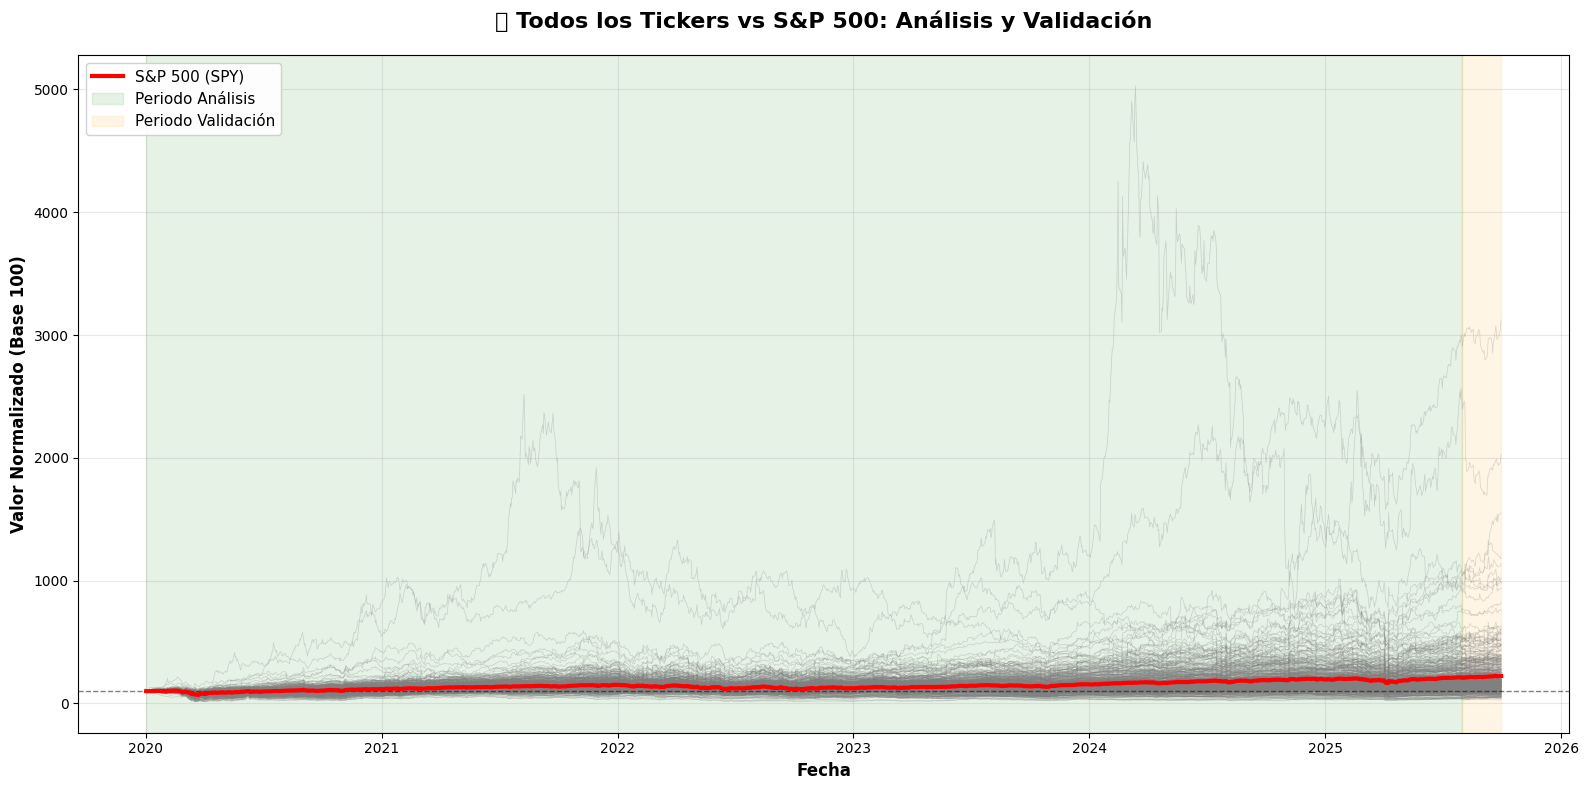

📊 ESTADÍSTICAS RESUMEN

🔍 PERIODO DE ANÁLISIS:
   Fechas: 2020-01-02 a 2025-07-31
   Tickers totales: 487
   S&P 500 retorno: Ticker
SPY    111.111033
dtype: float64%
   Mejor ticker: NVDA (2878.53%)
   Peor ticker: BAX (-71.69%)
   Promedio tickers: 114.23%

🔍 PERIODO DE VALIDACIÓN:
   Fechas: 2025-08-01 a 2025-09-30
   Tickers totales: 487
   S&P 500 retorno: Ticker
SPY    7.448206
Name: 2025-09-30 00:00:00, dtype: float64%
   Mejor ticker: INTC (73.74%)
   Peor ticker: TTD (-43.06%)
   Promedio tickers: 5.06%

🎯 PERIODO COMPLETO:
   Fechas: 2020-01-02 a 2025-09-30
   S&P 500 retorno total: Ticker
SPY    123.117094
Name: 2025-09-30 00:00:00, dtype: float64%
   Promedio tickers retorno total: 122.23%


In [14]:
# Graficamos todos los datos historicos, separados en tiempo de análisis y de validación juntos con el valor del S&P500
# =======================================================
# 📈 VISUALIZACIÓN DE TODOS LOS TICKERS VS S&P 500
# =======================================================

import matplotlib.pyplot as plt
import numpy as np

# Normalizar todos los tickers a base 100
all_tickers_norm = (all_tickers_data / all_tickers_data.iloc[0]) * 100

# Normalizar S&P 500 a base 100
spy_norm = (SPY_data / SPY_data.iloc[0]) * 100

# Crear figura
fig, ax = plt.subplots(figsize=(16, 8))

# Graficar todos los tickers en gris con transparencia
for ticker in all_tickers_norm.columns:
    ax.plot(all_tickers_norm.index, all_tickers_norm[ticker], 
            alpha=0.3, linewidth=0.5, color='gray')

# S&P 500 destacado en rojo
ax.plot(spy_norm.index, spy_norm, 
        linewidth=3, color='red', label='S&P 500 (SPY)', zorder=10)

# Línea vertical separando periodo de análisis y validación
#ax.axvline(x=pd.to_datetime(AN_DATE), color='blue', linestyle='--', linewidth=2.5, label='Inicio Validación', zorder=5)

# Áreas sombreadas para identificar periodos
ax.axvspan(all_tickers_norm.index[0], pd.to_datetime(AN_DATE), 
           alpha=0.1, color='green', label='Periodo Análisis')
ax.axvspan(pd.to_datetime(AN_DATE), all_tickers_norm.index[-1], 
           alpha=0.1, color='orange', label='Periodo Validación')

# Configuración de la gráfica
ax.set_title('📊 Todos los Tickers vs S&P 500: Análisis y Validación', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Fecha', fontsize=12, fontweight='bold')
ax.set_ylabel('Valor Normalizado (Base 100)', fontsize=12, fontweight='bold')
ax.legend(fontsize=11, loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

# --- ESTADÍSTICAS RESUMEN ---
print("="*80)
print("📊 ESTADÍSTICAS RESUMEN")
print("="*80)

# Separar datos por periodo
analysis_data = all_tickers_norm[all_tickers_norm.index < AN_DATE]
validation_data = all_tickers_norm[all_tickers_norm.index >= AN_DATE]

spy_analysis = spy_norm[spy_norm.index < AN_DATE]
spy_validation = spy_norm[spy_norm.index >= AN_DATE]

print("\n🔍 PERIODO DE ANÁLISIS:")
print(f"   Fechas: {analysis_data.index[0].strftime('%Y-%m-%d')} a {analysis_data.index[-1].strftime('%Y-%m-%d')}")
print(f"   Tickers totales: {len(analysis_data.columns)}")
print(f"   S&P 500 retorno: {((spy_analysis.iloc[-1] / spy_analysis.iloc[0]) - 1) * 100}%")
print(f"   Mejor ticker: {analysis_data.iloc[-1].idxmax()} ({((analysis_data.iloc[-1].max() / 100) - 1) * 100:.2f}%)")
print(f"   Peor ticker: {analysis_data.iloc[-1].idxmin()} ({((analysis_data.iloc[-1].min() / 100) - 1) * 100:.2f}%)")
print(f"   Promedio tickers: {((analysis_data.iloc[-1].mean() / 100) - 1) * 100:.2f}%")

print("\n🔍 PERIODO DE VALIDACIÓN:")
print(f"   Fechas: {validation_data.index[0].strftime('%Y-%m-%d')} a {validation_data.index[-1].strftime('%Y-%m-%d')}")
print(f"   Tickers totales: {len(validation_data.columns)}")
# Re-normalizar validación para ver retorno desde inicio de validación
validation_renorm = (validation_data / validation_data.iloc[0]) * 100
spy_val_renorm = (spy_validation / spy_validation.iloc[0]) * 100
print(f"   S&P 500 retorno: {((spy_val_renorm.iloc[-1] / 100) - 1) * 100}%")
print(f"   Mejor ticker: {validation_renorm.iloc[-1].idxmax()} ({((validation_renorm.iloc[-1].max() / 100) - 1) * 100:.2f}%)")
print(f"   Peor ticker: {validation_renorm.iloc[-1].idxmin()} ({((validation_renorm.iloc[-1].min() / 100) - 1) * 100:.2f}%)")
print(f"   Promedio tickers: {((validation_renorm.iloc[-1].mean() / 100) - 1) * 100:.2f}%")

print("\n🎯 PERIODO COMPLETO:")
print(f"   Fechas: {all_tickers_norm.index[0].strftime('%Y-%m-%d')} a {all_tickers_norm.index[-1].strftime('%Y-%m-%d')}")
print(f"   S&P 500 retorno total: {((spy_norm.iloc[-1] / 100) - 1) * 100}%")
print(f"   Promedio tickers retorno total: {((all_tickers_norm.iloc[-1].mean() / 100) - 1) * 100:.2f}%")

In [15]:
# =======================================================
# 📊 ÍNDICE EQUITATIVO CON TODOS LOS TICKERS DEL S&P 500
# =======================================================

import numpy as np
import pandas as pd

def create_equal_weighted_sp500_index(all_tickers_data):
    """
    Crea un índice con todos los tickers del S&P 500 con pesos iguales.
    
    Parameters:
    -----------
    all_tickers_data : DataFrame
        DataFrame con precios de todos los tickers
    
    Returns:
    --------
    index_series : Series
        Serie temporal del índice equitativo
    weights : dict
        Diccionario con los pesos de cada ticker
    """
    
    # Número total de tickers
    num_tickers = len(all_tickers_data.columns)
    
    # Peso equitativo para cada ticker
    equal_weight = 1.0 / num_tickers
    
    # Crear diccionario de pesos
    weights = {ticker: equal_weight for ticker in all_tickers_data.columns}
    
    # Calcular índice: suma ponderada de precios
    index_series = pd.Series(0.0, index=all_tickers_data.index)
    
    for ticker in all_tickers_data.columns:
        index_series += all_tickers_data[ticker] * equal_weight
    
    return index_series, weights


# Crear el índice equitativo
equal_weighted_index, equal_weights = create_equal_weighted_sp500_index(all_tickers_data)

print("="*80)
print("📊 ÍNDICE EQUITATIVO S&P 500")
print("="*80)
print(f"\n✅ Índice creado exitosamente")
print(f"   Tickers incluidos: {len(equal_weights)}")
print(f"   Peso por ticker: {list(equal_weights.values())[0]:.6f} ({list(equal_weights.values())[0]*100:.4f}%)")
print(f"   Periodo: {equal_weighted_index.index[0].strftime('%Y-%m-%d')} a {equal_weighted_index.index[-1].strftime('%Y-%m-%d')}")

# Separar por periodos
equal_analysis = equal_weighted_index[equal_weighted_index.index < AN_DATE]
equal_validation = equal_weighted_index[equal_weighted_index.index >= AN_DATE]

# Calcular métricas
def calcular_metricas(series, name):
    """Calcula métricas para una serie temporal"""
    
    # Asegurar que sea una Serie
    if isinstance(series, pd.DataFrame):
        series = series.iloc[:, 0]
    
    # Normalizar para calcular retorno
    norm_series = series / series.iloc[0]
    retorno_total = (norm_series.iloc[-1] - 1) * 100
    
    # Calcular tendencia con regresión lineal
    x = np.arange(len(series))
    y = series.values
    coefficients = np.polyfit(x, y, 1)
    trend_slope = coefficients[0]
    trend_normalized = (trend_slope / series.iloc[0]) * 100
    
    # Calcular R²
    y_pred = coefficients[0] * x + coefficients[1]
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
    
    # Volatilidad (desviación estándar de retornos diarios)
    daily_returns = series.pct_change().dropna()
    volatilidad = daily_returns.std() * np.sqrt(252) * 100  # Anualizada
    
    # Sharpe Ratio (asumiendo tasa libre de riesgo = 0)
    mean_return = daily_returns.mean() * 252  # Anualizado
    std_return = daily_returns.std()
    sharpe = mean_return / std_return if std_return > 0 else 0
    
    # Max Drawdown
    cumulative = norm_series
    running_max = cumulative.expanding().max()
    drawdown = ((cumulative - running_max) / running_max) * 100
    max_drawdown = drawdown.min()
    
    print(f"\n📈 {name}:")
    print(f"   Retorno total: {retorno_total:.2f}%")
    print(f"   Tendencia: {trend_normalized:.4f}%")
    print(f"   R²: {r_squared:.4f}")
    print(f"   Volatilidad: {volatilidad:.2f}%")
    print(f"   Sharpe Ratio: {sharpe:.4f}")
    print(f"   Max Drawdown: {max_drawdown:.2f}%")
    print(f"   Valor inicial: ${series.iloc[0]:.2f}")
    print(f"   Valor final: ${series.iloc[-1]:.2f}")
    
    return {
        'retorno_total': retorno_total,
        'tendencia': trend_normalized,
        'r_squared': r_squared,
        'volatilidad': volatilidad,
        'sharpe': sharpe,
        'max_drawdown': max_drawdown,
        'valor_inicial': series.iloc[0],
        'valor_final': series.iloc[-1]
    }

# Calcular métricas para cada periodo
print("\n" + "="*80)
print("📊 MÉTRICAS DEL ÍNDICE EQUITATIVO")
print("="*80)

metricas_analysis = calcular_metricas(equal_analysis, "PERIODO DE ANÁLISIS")
metricas_validation = calcular_metricas(equal_validation, "PERIODO DE VALIDACIÓN")
metricas_completo = calcular_metricas(equal_weighted_index, "PERIODO COMPLETO")

# Comparar con S&P 500
print("\n" + "="*80)
print("📊 COMPARACIÓN CON S&P 500")
print("="*80)

# Convertir SPY_data a Serie si es DataFrame
spy_series = SPY_data if isinstance(SPY_data, pd.DataFrame) else SPY_data
spy_analysis = spy_series[spy_series.index < AN_DATE]
spy_validation = spy_series[spy_series.index >= AN_DATE]

metricas_spy_analysis = calcular_metricas(spy_analysis, "S&P 500 - ANÁLISIS")
metricas_spy_validation = calcular_metricas(spy_validation, "S&P 500 - VALIDACIÓN")

print("\n" + "="*80)
print("🎯 ÍNDICE EQUITATIVO vs S&P 500")
print("="*80)
print(f"\n📈 PERIODO DE ANÁLISIS:")
print(f"   Índice Equitativo: {metricas_analysis['retorno_total']:.2f}%")
print(f"   S&P 500: {metricas_spy_analysis['retorno_total']:.2f}%")
print(f"   Diferencia: {metricas_analysis['retorno_total'] - metricas_spy_analysis['retorno_total']:.2f}%")

print(f"\n📈 PERIODO DE VALIDACIÓN:")
print(f"   Índice Equitativo: {metricas_validation['retorno_total']:.2f}%")
print(f"   S&P 500: {metricas_spy_validation['retorno_total']:.2f}%")
print(f"   Diferencia: {metricas_validation['retorno_total'] - metricas_spy_validation['retorno_total']:.2f}%")

📊 ÍNDICE EQUITATIVO S&P 500

✅ Índice creado exitosamente
   Tickers incluidos: 487
   Peso por ticker: 0.002053 (0.2053%)
   Periodo: 2020-01-02 a 2025-09-30

📊 MÉTRICAS DEL ÍNDICE EQUITATIVO

📈 PERIODO DE ANÁLISIS:
   Retorno total: 94.81%
   Tendencia: 0.0677%
   R²: 0.8398
   Volatilidad: 21.44%
   Sharpe Ratio: 10.5914
   Max Drawdown: -36.38%
   Valor inicial: $115.56
   Valor final: $225.13

📈 PERIODO DE VALIDACIÓN:
   Retorno total: 3.88%
   Tendencia: 0.0708%
   R²: 0.6043
   Volatilidad: 10.32%
   Sharpe Ratio: 36.8004
   Max Drawdown: -2.03%
   Valor inicial: $223.40
   Valor final: $232.07

📈 PERIODO COMPLETO:
   Retorno total: 100.81%
   Tendencia: 0.0685%
   R²: 0.8531
   Volatilidad: 21.20%
   Sharpe Ratio: 10.8087
   Max Drawdown: -36.38%
   Valor inicial: $115.56
   Valor final: $232.07

📊 COMPARACIÓN CON S&P 500

📈 S&P 500 - ANÁLISIS:
   Retorno total: 111.11%
   Tendencia: 0.0703%
   R²: 0.8207
   Volatilidad: 21.29%
   Sharpe Ratio: 11.7192
   Max Drawdown: -33.72%


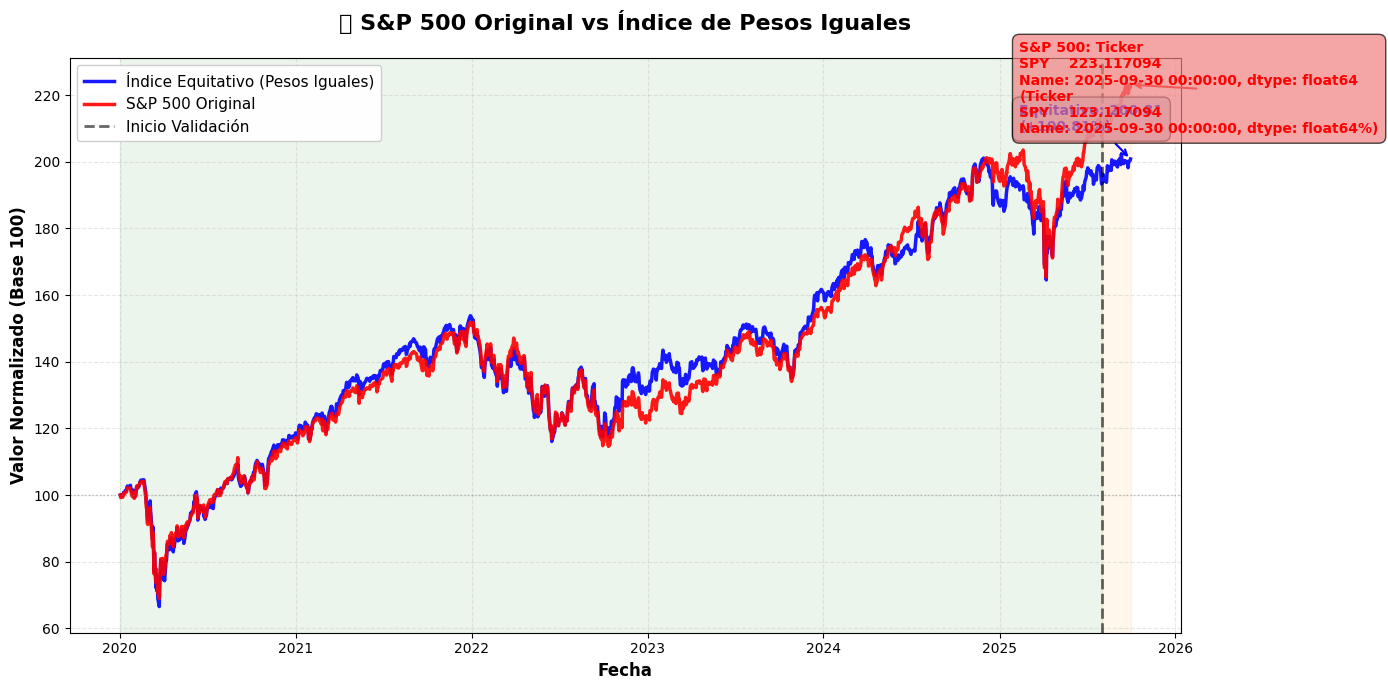

📊 COMPARACIÓN FINAL: S&P 500 vs ÍNDICE EQUITATIVO

📈 RENDIMIENTO TOTAL (completo):
   Índice Equitativo: +100.81%
   S&P 500 Original:  +123.12%
   Diferencia:        -22.30%

❌ El índice equitativo queda DEBAJO del S&P 500 por 22.30%

📊 PERIODO DE ANÁLISIS:
   Índice Equitativo: +94.81%
   S&P 500 Original:  +111.11%
   Diferencia:        -16.30%

📊 PERIODO DE VALIDACIÓN:
   Índice Equitativo: +3.88%
   S&P 500 Original:  +7.45%
   Diferencia:        -3.57%


In [16]:
# =======================================================
# 📊 GRÁFICA: S&P 500 vs ÍNDICE EQUITATIVO
# =======================================================

import matplotlib.pyplot as plt

# Normalizar ambos índices a base 100 para comparación
equal_norm = (equal_weighted_index / equal_weighted_index.iloc[0]) * 100
spy_norm = (SPY_data / SPY_data.iloc[0]) * 100

# Crear figura
fig, ax = plt.subplots(figsize=(14, 7))

# Graficar ambos índices
ax.plot(equal_norm.index, equal_norm, linewidth=2.5, color='blue', 
        label='Índice Equitativo (Pesos Iguales)', alpha=0.9)
ax.plot(spy_norm.index, spy_norm, linewidth=2.5, color='red', 
        label='S&P 500 Original', alpha=0.9)

# Línea separadora de periodos
ax.axvline(x=pd.to_datetime(AN_DATE), color='black', linestyle='--', 
           linewidth=2, label='Inicio Validación', alpha=0.6)

# Áreas sombreadas
ax.axvspan(equal_norm.index[0], pd.to_datetime(AN_DATE), 
           alpha=0.08, color='green')
ax.axvspan(pd.to_datetime(AN_DATE), equal_norm.index[-1], 
           alpha=0.08, color='orange')

# Línea base
ax.axhline(y=100, color='gray', linestyle=':', linewidth=1, alpha=0.5)

# Configuración
ax.set_title('📊 S&P 500 Original vs Índice de Pesos Iguales', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Fecha', fontsize=12, fontweight='bold')
ax.set_ylabel('Valor Normalizado (Base 100)', fontsize=12, fontweight='bold')
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')

# Anotaciones con rendimiento final
equal_final = equal_norm.iloc[-1]
spy_final = spy_norm.iloc[-1]

ax.annotate(f'Equitativo: {equal_final:.2f}\n({((equal_final/100)-1)*100:+.2f}%)',
            xy=(equal_norm.index[-1], equal_final),
            xytext=(-80, 20), textcoords='offset points',
            fontsize=10, fontweight='bold', color='blue',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.7),
            arrowprops=dict(arrowstyle='->', color='blue', lw=1.5))

ax.annotate(f'S&P 500: {spy_final}\n({((spy_final/100)-1)*100}%)',
            xy=(spy_norm.index[-1], spy_final),
            xytext=(-80, -35), textcoords='offset points',
            fontsize=10, fontweight='bold', color='red',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightcoral', alpha=0.7),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

plt.tight_layout()
plt.show()

# Estadísticas resumidas
print("="*80)
print("📊 COMPARACIÓN FINAL: S&P 500 vs ÍNDICE EQUITATIVO")
print("="*80)

# Convertir a escalar si es necesario
equal_return = float(((equal_norm.iloc[-1] / 100) - 1) * 100)
spy_return = float(((spy_norm.iloc[-1] / 100) - 1) * 100)
diferencia = equal_return - spy_return

print(f"\n📈 RENDIMIENTO TOTAL (completo):")
print(f"   Índice Equitativo: {equal_return:+.2f}%")
print(f"   S&P 500 Original:  {spy_return:+.2f}%")
print(f"   Diferencia:        {diferencia:+.2f}%")

if diferencia > 0:
    print(f"\n✅ El índice equitativo SUPERA al S&P 500 por {abs(diferencia):.2f}%")
else:
    print(f"\n❌ El índice equitativo queda DEBAJO del S&P 500 por {abs(diferencia):.2f}%")

# Separar por periodos
equal_analysis = equal_norm[equal_norm.index < AN_DATE]
equal_validation = equal_norm[equal_norm.index >= AN_DATE]
spy_analysis = spy_norm[spy_norm.index < AN_DATE]
spy_validation = spy_norm[spy_norm.index >= AN_DATE]

# Periodo de análisis
equal_ret_analysis = float(((equal_analysis.iloc[-1] / equal_analysis.iloc[0]) - 1) * 100)
spy_ret_analysis = float(((spy_analysis.iloc[-1] / spy_analysis.iloc[0]) - 1) * 100)

print(f"\n📊 PERIODO DE ANÁLISIS:")
print(f"   Índice Equitativo: {equal_ret_analysis:+.2f}%")
print(f"   S&P 500 Original:  {spy_ret_analysis:+.2f}%")
print(f"   Diferencia:        {(equal_ret_analysis - spy_ret_analysis):+.2f}%")

# Periodo de validación
equal_ret_validation = float(((equal_validation.iloc[-1] / equal_validation.iloc[0]) - 1) * 100)
spy_ret_validation = float(((spy_validation.iloc[-1] / spy_validation.iloc[0]) - 1) * 100)

print(f"\n📊 PERIODO DE VALIDACIÓN:")
print(f"   Índice Equitativo: {equal_ret_validation:+.2f}%")
print(f"   S&P 500 Original:  {spy_ret_validation:+.2f}%")
print(f"   Diferencia:        {(equal_ret_validation - spy_ret_validation):+.2f}%")


### Datos de métricas

In [17]:
# =======================================================
# CREAR SUBCARPETA PARA VISUALIZACIONES
# =======================================================

import os

# Crear la subcarpeta para todas las visualizaciones
output_folder = 'Mapper_final'
os.makedirs(output_folder, exist_ok=True)
print(f"📁 Subcarpeta creada: {output_folder}/")
print(f"🌐 Todas las visualizaciones HTML se guardarán en esta carpeta")

📁 Subcarpeta creada: Mapper_final/
🌐 Todas las visualizaciones HTML se guardarán en esta carpeta


In [18]:
# Sacamos métricas de cada ticker

financial_metrics = {}
print("\n🔄 Calculando métricas financieras...")
for ticker in tickers_data.columns:
    try:
        prices = tickers_data[ticker].dropna()
        returns = prices.pct_change().dropna()
        
        # Métricas básicas
        total_return = (prices.iloc[-1] / prices.iloc[0]) - 1
        volatility = returns.std() * np.sqrt(252)  # Anualizada
        sharpe = (returns.mean() * 252) / (returns.std() * np.sqrt(252)) if returns.std() > 0 else 0
        
        # Métricas de riesgo
        max_drawdown = ((prices / prices.cummax()) - 1).min()
        var_95 = returns.quantile(0.05)  # Value at Risk 95%
        skewness = returns.skew()
        kurtosis = returns.kurtosis()
        
        # Métricas de tendencia
        returns_positive_ratio = (returns > 0).mean()
        trend_slope = np.polyfit(range(len(prices)), prices.values, 1)[0]
        
        financial_metrics[ticker] = {
            'total_return': total_return,
            'volatility': volatility,
            'sharpe_ratio': sharpe,
            'max_drawdown': max_drawdown,
            'var_95': var_95,
            'skewness': skewness,
            'kurtosis': kurtosis,
            'positive_ratio': returns_positive_ratio,
            'trend_slope': trend_slope / prices.iloc[0]  # Normalizado
        }
    except Exception as e:
        print(f"❌ Error procesando {ticker}: {e}")

# Convertir a DataFrame
metrics_df = pd.DataFrame(financial_metrics).T

# Normalizar datos
scaler = StandardScaler()
metrics_scaled = scaler.fit_transform(metrics_df.fillna(0))# Datos normalizados que ya tenemos

# Preparar datos para KeplerMapper (usar métricas financieras)

ticker_names = metrics_df.index.tolist()


print(f"📊 Datos preparados: {metrics_scaled.shape[0]} tickers, {metrics_scaled.shape[1]} métricas")


🔄 Calculando métricas financieras...
📊 Datos preparados: 487 tickers, 9 métricas


In [19]:
metrics_df

,total_return,volatility,sharpe_ratio,max_drawdown,var_95,skewness,kurtosis,positive_ratio,trend_slope
A,0.372247,0.301785,0.339333,-0.431929,-0.029914,0.026954,3.458284,0.523538,0.000268
AAPL,1.786803,0.324077,0.730106,-0.333605,-0.031667,0.279151,6.688475,0.530670,0.001395
ABBV,1.775896,0.251207,0.857578,-0.340424,-0.021620,-0.891125,9.751468,0.543509,0.001307
ABT,0.620377,0.260157,0.463563,-0.338767,-0.023623,0.033986,6.680198,0.518545,0.000244
ACGL,1.132351,0.332716,0.576531,-0.538398,-0.030000,-0.329866,9.917739,0.532810,0.001417
...,...,...,...,...,...,...,...,...,...
XYZ,0.159799,0.641180,0.363717,-0.860828,-0.061408,-0.010916,4.779448,0.510699,-0.001430
YUM,0.576569,0.259859,0.442716,-0.468315,-0.021000,1.820397,34.607928,0.526391,0.000472
ZBH,-0.346437,0.310618,-0.090931,-0.497319,-0.028793,0.199971,9.037746,0.486448,-0.000163
ZBRA,0.293664,0.409911,0.319552,-0.677829,-0.035456,-0.347294,7.479186,0.513552,-0.000183


In [20]:
metrics_scaled

array([[-0.34740512, -0.58479039, -0.40880749, ..., -0.86715038,
         0.26350733, -0.34343353],
       [ 0.3121997 , -0.3520733 ,  0.9674619 , ..., -0.55360025,
         0.64452892,  0.4198677 ],
       [ 0.30711374, -1.11280796,  1.41640686, ..., -0.25627973,
         1.33036777,  0.36023568],
       ...,
       [-0.68252607, -0.49258075, -1.92415722, ..., -0.32555978,
        -1.71780492, -0.635589  ],
       [-0.38404856,  0.54399974, -0.47847367, ..., -0.47684702,
        -0.26992289, -0.64850413],
       [-0.45020795, -0.71075405, -0.78292765, ..., -0.48076946,
        -0.15561641, -0.43434467]], shape=(487, 9))

## Creación de mappers

### Mappers con datos completos

In [21]:
# Escalamos
data = StandardScaler().fit_transform(tickers_data.T)

# Inicializamos Mapper
mapper = km.KeplerMapper(verbose=1)  # verbose=1 para ver debug info
# Proyección (lens): PCA a 2D
lens = mapper.fit_transform(data, projection=PCA(n_components=2))

# Construcción del grafo con KMeans
graph_hist_1 = mapper.map(
    lens, 
    data, 
    clusterer=KMeans(n_clusters=3, random_state=0),  # ✅ KMeans más confiable
    cover=km.Cover(n_cubes=10, perc_overlap=0.5)
)

print(f"✅ Nodos encontrados: {len(graph_hist_1['nodes'])}")
print(f"✅ Aristas encontradas: {len(graph_hist_1['links'])}")

# Visualización interactiva
mapper.visualize(graph_hist_1, 
                 title="Mapper de series de tiempo",
                 custom_tooltips=np.array(ticker_names),  # Mostrar nombres de tickers
                 path_html="Mapper_final/mapper_output.html")

KeplerMapper(verbose=1)
..Composing projection pipeline of length 1:
	Projections: PCA(n_components=2)
	Distance matrices: False
	Scalers: MinMaxScaler()
..Projecting on data shaped (487, 1403)

..Projecting data using: 
	PCA(n_components=2)


..Scaling with: MinMaxScaler()

Mapping on data shaped (487, 1403) using lens shaped (487, 2)

Creating 100 hypercubes.

Created 97 edges and 42 nodes in 0:00:02.038549.
✅ Nodos encontrados: 42
✅ Aristas encontradas: 37
Wrote visualization to: Mapper_final/mapper_output.html


'<!DOCTYPE html>\n<html>\n\n<head>\n  <meta charset="utf-8">\n  <meta name="generator" content="KeplerMapper">\n  <title>Mapper de series de tiempo | KeplerMapper</title>\n\n  <link rel="icon" type="image/png" href="http://i.imgur.com/axOG6GJ.jpg" />\n\n  <link href=\'https://fonts.googleapis.com/css?family=Roboto+Mono:700,300\' rel=\'stylesheet\' type=\'text/css\'>\n  <style>* {\n  margin: 0;\n  padding: 0;\n}\n\nhtml, body {\n  height: 100%;\n}\n\nbody {\n  font-family: "Roboto Mono", "Helvetica", sans-serif;\n  font-size: 14px;\n}\n\n#logo {\n  width:  85px;\n  height: 85px;\n}\n\n#display {\n  color: #95A5A6;\n  background: #212121;\n}\n\n#header {\n  background: #111111;\n}\n\n#print {\n  color: #000;\n  background: #FFF;\n}\n\nh1 {\n  font-size: 21px;\n  font-weight: 300;\n  font-weight: 300;\n}\n\nh2 {\n  font-size: 18px;\n  padding-bottom: 20px;\n  font-weight: 300;\n}\n\nh3 {\n  font-size: 14px;\n  font-weight: 700;\n  text-transform: uppercase;\n}\n\nh4 {\n  font-size: 13px;\

In [22]:
# =======================================================
# 📈 MAPPER ENFOCADO EN TENDENCIA DE CRECIMIENTO
# =======================================================

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import kmapper as km

# ==========================================
# 1. CALCULAR FEATURES DE TENDENCIA
# ==========================================

def calcular_features_tendencia(prices_df):
    """
    Calcula features enfocadas en la tendencia de crecimiento porcentual.
    
    Returns:
    --------
    features_matrix : array
        Matriz de features (n_tickers x n_features)
    """
    
    features_list = []
    
    for ticker in prices_df.columns:
        serie = prices_df[ticker].dropna()
        
        if len(serie) < 10:
            # Si no hay suficientes datos, llenar con ceros
            features_list.append(np.zeros(8))
            continue
        
        # 1. RETORNOS PORCENTUALES DIARIOS
        daily_returns = serie.pct_change().dropna()
        
        # 2. TENDENCIA LINEAL (pendiente normalizada)
        x = np.arange(len(serie))
        y = serie.values
        coefficients = np.polyfit(x, y, 1)
        trend_slope = coefficients[0] / serie.iloc[0]  # Normalizado
        
        # 3. ACELERACIÓN (segunda derivada - tendencia de la tendencia)
        # Dividir serie en 2 mitades y comparar pendientes
        mid = len(serie) // 2
        x1, y1 = np.arange(mid), serie.iloc[:mid].values
        x2, y2 = np.arange(len(serie) - mid), serie.iloc[mid:].values
        
        slope1 = np.polyfit(x1, y1, 1)[0] / serie.iloc[0]
        slope2 = np.polyfit(x2, y2, 1)[0] / serie.iloc[mid]
        acceleration = slope2 - slope1  # Aceleración
        
        # 4. MOMENTUM (retorno reciente vs retorno total)
        recent_return = (serie.iloc[-5:].mean() / serie.iloc[-10:-5].mean()) - 1
        total_return = (serie.iloc[-1] / serie.iloc[0]) - 1
        momentum_ratio = recent_return / total_return if total_return != 0 else 0
        
        # 5. CONSISTENCIA DE CRECIMIENTO (% de días positivos)
        pct_positive_days = (daily_returns > 0).sum() / len(daily_returns)
        
        # 6. VOLATILIDAD DE RETORNOS (menor es mejor para predicción)
        volatility = daily_returns.std()
        
        # 7. RETORNO MEDIO DIARIO
        mean_daily_return = daily_returns.mean()
        
        # 8. R² DE LA TENDENCIA (calidad del ajuste lineal)
        y_pred = coefficients[0] * x + coefficients[1]
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
        
        # Crear vector de features
        features = np.array([
            trend_slope,           # Peso alto: tendencia principal
            acceleration,          # Peso alto: ¿está acelerando?
            momentum_ratio,        # Peso medio: momentum reciente
            pct_positive_days,     # Peso medio: consistencia
            mean_daily_return,     # Peso medio: retorno promedio
            r_squared,             # Peso bajo: calidad del ajuste
            -volatility,           # Peso bajo: negativo porque menor es mejor
            total_return           # Peso bajo: retorno total
        ])
        
        features_list.append(features)
    
    return np.array(features_list)

# Calcular features enfocadas en tendencia
print("🔍 Calculando features de tendencia de crecimiento...")
features_tendencia = calcular_features_tendencia(tickers_data)

print(f"✅ Features calculadas: {features_tendencia.shape}")
print(f"   Tickers: {features_tendencia.shape[0]}")
print(f"   Features por ticker: {features_tendencia.shape[1]}")
print(f"\n📊 Features utilizadas:")
print(f"   1. Tendencia lineal (slope normalizado)")
print(f"   2. Aceleración (segunda derivada)")
print(f"   3. Momentum ratio (reciente vs total)")
print(f"   4. % días positivos")
print(f"   5. Retorno medio diario")
print(f"   6. R² de tendencia")
print(f"   7. Volatilidad (negativa)")
print(f"   8. Retorno total")

# ==========================================
# 2. ESCALADO Y MAPPER
# ==========================================

# Escalar features (importante para dar pesos equitativos)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(features_tendencia)

print(f"\n✅ Features escaladas: {data_scaled.shape}")

# Inicializar Mapper
mapper = km.KeplerMapper(verbose=1)

# Proyección (lens): PCA a 2D enfocado en las features de tendencia
lens = mapper.fit_transform(data_scaled, projection=PCA(n_components=2))

print(f"\n✅ Proyección PCA completada: {lens.shape}")

# Construcción del grafo con KMeans
# Ajustar n_clusters basado en cuántos grupos de tendencia esperamos
graph_tendencia = mapper.map(
    lens, 
    data_scaled, 
    clusterer=KMeans(n_clusters=4, random_state=42),  # 4 clusters: alto/medio/bajo/negativo
    cover=km.Cover(n_cubes=12, perc_overlap=0.6)  # Más resolución
)

print(f"\n✅ Grafo de Mapper construido:")
print(f"   Nodos encontrados: {len(graph_tendencia['nodes'])}")
print(f"   Aristas encontradas: {len(graph_tendencia['links'])}")

# ==========================================
# 3. COLOREAR POR TENDENCIA DE CRECIMIENTO
# ==========================================

# Calcular tendencia promedio por ticker para colorear
tendencias_tickers = features_tendencia[:, 0]  # Primera columna = trend_slope

print(f"\n📊 Estadísticas de tendencia:")
print(f"   Máxima: {tendencias_tickers.max():.6f}")
print(f"   Promedio: {tendencias_tickers.mean():.6f}")
print(f"   Mínima: {tendencias_tickers.min():.6f}")

# Visualización interactiva coloreada por tendencia
mapper.visualize(
    graph_tendencia, 
    title="🚀 Mapper: Agrupación por Probabilidad de Crecimiento Porcentual",
    custom_tooltips=np.array(ticker_names),
    color_values=tendencias_tickers,  # ✅ Colorear por tendencia
    color_function_name='Tendencia de Crecimiento',
    path_html="Mapper_final/mapper_tendencia_crecimiento.html"
)

print(f"\n✅ Visualización guardada en: Mapper_final/mapper_tendencia_crecimiento.html")

# ==========================================
# 4. ANÁLISIS DE CLUSTERS POR TENDENCIA
# ==========================================

print("\n" + "="*80)
print("📊 ANÁLISIS DE CLUSTERS POR TENDENCIA DE CRECIMIENTO")
print("="*80)

# Extraer clusters del grafo
cluster_assignments = {}
for node_id, node_members in graph_tendencia['nodes'].items():
    for member_idx in node_members:
        if member_idx not in cluster_assignments:
            cluster_assignments[member_idx] = []
        cluster_assignments[member_idx].append(node_id)

# Agrupar por nodos
nodos_info = []
for node_id, members in graph_tendencia['nodes'].items():
    if len(members) == 0:
        continue
    
    # Calcular tendencia promedio del nodo
    tendencias_nodo = [tendencias_tickers[idx] for idx in members]
    tendencia_promedio = np.mean(tendencias_nodo)
    
    # Obtener nombres de tickers
    tickers_nodo = [ticker_names[idx] for idx in members]
    
    nodos_info.append({
        'node_id': node_id,
        'n_tickers': len(members),
        'tendencia_promedio': tendencia_promedio,
        'tickers': tickers_nodo[:5]  # Mostrar solo primeros 5
    })

# Ordenar por tendencia (de mayor a menor)
nodos_info_sorted = sorted(nodos_info, key=lambda x: x['tendencia_promedio'], reverse=True)

print(f"\n🔝 TOP 5 NODOS CON MAYOR TENDENCIA DE CRECIMIENTO:")
print("="*80)
for i, nodo in enumerate(nodos_info_sorted[:5], 1):
    print(f"\n{i}. Nodo {nodo['node_id']}:")
    print(f"   Tendencia promedio: {nodo['tendencia_promedio']:.6f}")
    print(f"   Tickers en el nodo: {nodo['n_tickers']}")
    print(f"   Ejemplos: {', '.join(nodo['tickers'])}")

print(f"\n\n📉 TOP 5 NODOS CON MENOR TENDENCIA (o negativa):")
print("="*80)
for i, nodo in enumerate(nodos_info_sorted[-5:], 1):
    print(f"\n{i}. Nodo {nodo['node_id']}:")
    print(f"   Tendencia promedio: {nodo['tendencia_promedio']:.6f}")
    print(f"   Tickers en el nodo: {nodo['n_tickers']}")
    print(f"   Ejemplos: {', '.join(nodo['tickers'])}")

🔍 Calculando features de tendencia de crecimiento...
✅ Features calculadas: (487, 8)
   Tickers: 487
   Features por ticker: 8

📊 Features utilizadas:
   1. Tendencia lineal (slope normalizado)
   2. Aceleración (segunda derivada)
   3. Momentum ratio (reciente vs total)
   4. % días positivos
   5. Retorno medio diario
   6. R² de tendencia
   7. Volatilidad (negativa)
   8. Retorno total

✅ Features escaladas: (487, 8)
KeplerMapper(verbose=1)
..Composing projection pipeline of length 1:
	Projections: PCA(n_components=2)
	Distance matrices: False
	Scalers: MinMaxScaler()
..Projecting on data shaped (487, 8)

..Projecting data using: 
	PCA(n_components=2)


..Scaling with: MinMaxScaler()


✅ Proyección PCA completada: (487, 2)
Mapping on data shaped (487, 8) using lens shaped (487, 2)

Creating 144 hypercubes.

Created 1339 edges and 160 nodes in 0:00:00.171996.

✅ Grafo de Mapper construido:
   Nodos encontrados: 160
   Aristas encontradas: 143

📊 Estadísticas de tendencia:
   Máxima:

### Mappers con métricas

In [23]:
# 1. Crear el mapper
mapper = km.KeplerMapper(verbose=1)

KeplerMapper(verbose=1)


In [24]:
# Configuración 1: Proyección por Sharpe
projected_data_sharpe = mapper.fit_transform(metrics_scaled, projection=[2])  # Sharpe ratio (índice 2)
covering = km.Cover(n_cubes=6, perc_overlap=0.5)
G = mapper.map(projected_data_sharpe, metrics_scaled, 
               clusterer=sklearn.cluster.KMeans(n_clusters=2),
               cover=covering)

mapper.visualize(G, 
                title='Mapper: Agrupación por Sharpe',
                color_values=metrics_df['sharpe_ratio'].values,
                color_function_name='Sharpe Ratio',
                node_color_function=np.array(['average','std','sum','max','min']),
                custom_tooltips=np.array(ticker_names),  # Mostrar nombres de tickers
                path_html='Mapper_final/mapper_principal_sharpe.html')  # Guardado en subcarpeta

print(f"Nodos: {len(G['nodes'])}, Aristas: {len(G['links'])}")

..Composing projection pipeline of length 1:
	Projections: [2]
	Distance matrices: False
	Scalers: MinMaxScaler()
..Projecting on data shaped (487, 9)

..Projecting data using: [2]

..Scaling with: MinMaxScaler()

Mapping on data shaped (487, 9) using lens shaped (487, 1)

Creating 6 hypercubes.

Created 16 edges and 12 nodes in 0:00:00.025999.
Wrote visualization to: Mapper_final/mapper_principal_sharpe.html
Nodos: 12, Aristas: 10


In [25]:
# Configuración 2: Proyección por Volatilidad

projected_data_vol = mapper.fit_transform(metrics_scaled, projection=[1])  # Volatilidad (índice 1)
covering_vol = km.Cover(n_cubes=8, perc_overlap=0.4)
G_vol = mapper.map(projected_data_vol, metrics_scaled, 
                   clusterer=sklearn.cluster.KMeans(n_clusters=3),
                   cover=covering_vol)

mapper.visualize(G_vol, 
                title='Mapper: Agrupación por Volatilidad',
                color_values=metrics_df['volatility'].values,
                color_function_name='Volatilidad',
                node_color_function=np.array(['average','max']),
                custom_tooltips=np.array(ticker_names),  # Mostrar nombres de tickers
                path_html='visualizaciones_mapper_indice/mapper_config_volatilidad.html')  # Guardado en subcarpeta

print(f"Nodos: {len(G_vol['nodes'])}, Aristas: {len(G_vol['links'])}")

..Composing projection pipeline of length 1:
	Projections: [1]
	Distance matrices: False
	Scalers: MinMaxScaler()
..Projecting on data shaped (487, 9)

..Projecting data using: [1]

..Scaling with: MinMaxScaler()

Mapping on data shaped (487, 9) using lens shaped (487, 1)

Creating 8 hypercubes.

Created 23 edges and 24 nodes in 0:00:00.031996.
Wrote visualization to: visualizaciones_mapper_indice/mapper_config_volatilidad.html
Nodos: 24, Aristas: 15


In [26]:
# Configuración 3: Proyección por Retorno Total

projected_data_ret = mapper.fit_transform(metrics_scaled, projection=[0])  # Retorno total (índice 0)
covering_ret = km.Cover(n_cubes=7, perc_overlap=0.3)
G_ret = mapper.map(projected_data_ret, metrics_scaled, 
                   clusterer=sklearn.cluster.DBSCAN(eps=0.5, min_samples=1),
                   cover=covering_ret)

mapper.visualize(G_ret, 
                title='Mapper: Agrupación por Retorno Total',
                node_color_function=np.array(['average','std']),
                custom_tooltips=np.array(ticker_names),  # Mostrar nombres de tickers
                path_html='visualizaciones_mapper_indice/mapper_config_retorno_total.html')  # Guardado en subcarpeta

print(f"Nodos: {len(G_ret['nodes'])}, Aristas: {len(G_ret['links'])}")

..Composing projection pipeline of length 1:
	Projections: [0]
	Distance matrices: False
	Scalers: MinMaxScaler()
..Projecting on data shaped (487, 9)

..Projecting data using: [0]

..Scaling with: MinMaxScaler()

Mapping on data shaped (487, 9) using lens shaped (487, 1)

Creating 7 hypercubes.

Created 35 edges and 468 nodes in 0:00:00.053996.
Wrote visualization to: visualizaciones_mapper_indice/mapper_config_retorno_total.html
Nodos: 468, Aristas: 35


In [27]:
# Configuración 4: Proyección Multi-dimensional (PCA)
projected_data_pca = mapper.fit_transform(metrics_scaled, projection='sum')  # Proyección suma
covering_pca = km.Cover(n_cubes=5, perc_overlap=0.6)
G_pca = mapper.map(projected_data_pca, metrics_scaled, 
                   clusterer=sklearn.cluster.KMeans(n_clusters=2),
                   cover=covering_pca)

mapper.visualize(G_pca, 
                title='Mapper: Proyección PCA (Suma)',
                node_color_function=np.array(['min','average']),
                custom_tooltips=np.array(ticker_names),  # Mostrar nombres de tickers
                path_html='visualizaciones_mapper_indice/mapper_config_pca_suma.html')  # Guardado en subcarpeta

..Composing projection pipeline of length 1:
	Projections: sum
	Distance matrices: False
	Scalers: MinMaxScaler()
..Projecting on data shaped (487, 9)

..Projecting data using: sum

..Scaling with: MinMaxScaler()

Mapping on data shaped (487, 9) using lens shaped (487, 1)

Creating 5 hypercubes.

Created 18 edges and 10 nodes in 0:00:00.022996.
Wrote visualization to: visualizaciones_mapper_indice/mapper_config_pca_suma.html


'<!DOCTYPE html>\n<html>\n\n<head>\n  <meta charset="utf-8">\n  <meta name="generator" content="KeplerMapper">\n  <title>Mapper: Proyección PCA (Suma) | KeplerMapper</title>\n\n  <link rel="icon" type="image/png" href="http://i.imgur.com/axOG6GJ.jpg" />\n\n  <link href=\'https://fonts.googleapis.com/css?family=Roboto+Mono:700,300\' rel=\'stylesheet\' type=\'text/css\'>\n  <style>* {\n  margin: 0;\n  padding: 0;\n}\n\nhtml, body {\n  height: 100%;\n}\n\nbody {\n  font-family: "Roboto Mono", "Helvetica", sans-serif;\n  font-size: 14px;\n}\n\n#logo {\n  width:  85px;\n  height: 85px;\n}\n\n#display {\n  color: #95A5A6;\n  background: #212121;\n}\n\n#header {\n  background: #111111;\n}\n\n#print {\n  color: #000;\n  background: #FFF;\n}\n\nh1 {\n  font-size: 21px;\n  font-weight: 300;\n  font-weight: 300;\n}\n\nh2 {\n  font-size: 18px;\n  padding-bottom: 20px;\n  font-weight: 300;\n}\n\nh3 {\n  font-size: 14px;\n  font-weight: 700;\n  text-transform: uppercase;\n}\n\nh4 {\n  font-size: 13p

## Acomodo de indices

In [28]:
graphs={
    'Historic1': graph_hist_1,
    'Historic2_tendencia': graph_tendencia,
    'Sharpe': G,
    'Volatilidad': G_vol,
    'Retorno': G_ret,
    'PCA': G_pca}


graph_names = list(graphs.keys())

categories = {ticker: ticker_info_db[ticker]['sector'] for ticker in ticker_names}
#market_caps = {ticker: ticker_info_db[ticker]['market_cap'] for ticker in ticker_names}
market_caps = {ticker: ticker_info_db.get(ticker, {}).get('market_cap', np.nan) for ticker in ticker_names}

In [29]:
missing_caps = [t for t in ticker_names if 'market_cap' not in ticker_info_db.get(t, {})]
if missing_caps:
    print("Missing market_cap for:", missing_caps)

In [30]:
"""
Analiza todos los clusters encontrados en los diferentes archivos Mapper
"""
print("📊 ANALIZANDO TODOS LOS CLUSTERS DEL MAPPER")
print("=" * 60)

# Diccionario para almacenar todos los clusters encontrados
def extract_clusters_from_all_graphs(graphs_dict, ticker_names, min_cluster_size=2):
    """
    Extrae clusters de todos los grafos en el diccionario graphs.
    
    Parámetros:
    -----------
    graphs_dict : dict
        Diccionario con {graph_label: graph_object}
    ticker_names : list
        Lista de nombres de tickers
    min_cluster_size : int
        Tamaño mínimo de cluster (default: 2)
    
    Retorna:
    --------
    all_clusters : dict
        Diccionario con todos los clusters encontrados
    """
    all_clusters = {}
    total_clusters = 0
    
    for graph_label, graph in graphs_dict.items():
        print(f"\n🔍 Extrayendo clusters del análisis por {graph_label}:")
        print(f"   Total de nodos: {len(graph['nodes'])}")
        
        clusters_in_graph = 0
        for i, (node_name, node_indices) in enumerate(graph['nodes'].items()):
            if len(node_indices) >= min_cluster_size:
                cluster_tickers = [ticker_names[idx] for idx in node_indices]
                cluster_name = f"{graph_label}_Cluster_{i+1}"
                all_clusters[cluster_name] = {
                    'tickers': cluster_tickers,
                    'type': graph_label,
                    'node_name': node_name,
                    'size': len(cluster_tickers)
                }
                print(f"     -{cluster_name}: {cluster_tickers} ({len(cluster_tickers)} tickers)")
                clusters_in_graph += 1
        
        print(f"   📌 {clusters_in_graph} clusters encontrados en {graph_label}")
        total_clusters += clusters_in_graph
    
    print(f"\n{'='*60}")
    print(f"📋 RESUMEN TOTAL: {total_clusters} clusters encontrados en {len(graphs_dict)} grafos")
    print(f"{'='*60}")
    
    return all_clusters


# Ejecutar la extracción para todos los grafos
all_clusters = extract_clusters_from_all_graphs(
    graphs_dict=graphs,
    ticker_names=ticker_names,
    min_cluster_size=4
)

📊 ANALIZANDO TODOS LOS CLUSTERS DEL MAPPER

🔍 Extrayendo clusters del análisis por Historic1:
   Total de nodos: 42
     -Historic1_Cluster_4: ['ADBE', 'ALGN', 'DPZ', 'EPAM', 'HUM', 'IDXX', 'LULU', 'PAYC', 'POOL', 'TMO', 'ZBRA'] (11 tickers)
     -Historic1_Cluster_5: ['BIIB', 'CRL', 'EL', 'GNRC', 'PYPL', 'SBAC'] (6 tickers)
     -Historic1_Cluster_7: ['ACN', 'ADBE', 'DPZ', 'ELV', 'FDS', 'HD', 'HUM', 'IDXX', 'LMT', 'LULU', 'MA', 'MCO', 'MOH', 'MSCI', 'NOC', 'POOL', 'ROP', 'SBAC', 'SPGI', 'TDY', 'TMO', 'TYL', 'ULTA', 'UNH', 'WAT', 'WST', 'ZBRA'] (27 tickers)
     -Historic1_Cluster_8: ['ADSK', 'AKAM', 'ALB', 'AMGN', 'AMT', 'AMZN', 'APD', 'APTV', 'ARE', 'AVB', 'AWK', 'BA', 'BALL', 'BAX', 'BDX', 'BIIB', 'CCI', 'CLX', 'CPAY', 'CRL', 'CRM', 'DAY', 'DG', 'DHR', 'DIS', 'DLTR', 'DXCM', 'EA', 'ECL', 'EFX', 'EL', 'ESS', 'EW', 'FDX', 'FIS', 'GNRC', 'GPN', 'HII', 'HON', 'HSY', 'IEX', 'IFF', 'INCY', 'IQV', 'ITW', 'JBHT', 'JKHY', 'JNJ', 'KEYS', 'KMB', 'LH', 'LHX', 'MAA', 'MDT', 'MHK', 'MMM', 'MRNA',

### Pesos

In [31]:
# Convert market_caps dict to pandas Series
market_caps_series = pd.Series(market_caps)

# Mostrar muestra del DataFrame
print(f"\n📋 Muestra de las capitalizaciones:")
print(market_caps_series.head(10))
print(f"\n📊 Estadísticas de las capitalizaciones:")
print(f"   💰 Capitalización promedio: ${market_caps_series.mean():,.0f}")
print(f"   📈 Capitalización máxima: ${market_caps_series.max():,.0f}")
print(f"   📉 Capitalización mínima: ${market_caps_series.min():,.0f}")


📋 Muestra de las capitalizaciones:
A       4.088926e+10
AAPL    3.961836e+12
ABBV    3.762416e+11
ABT     2.141073e+11
ACGL    3.150516e+10
ACN     1.530565e+11
ADBE    1.413863e+11
ADI     1.152251e+11
ADM     2.927950e+10
ADP     1.037759e+11
dtype: float64

📊 Estadísticas de las capitalizaciones:
   💰 Capitalización promedio: $131,190,595,644
   📈 Capitalización máxima: $5,105,444,716,544
   📉 Capitalización mínima: $6,697,864,704


In [32]:
def create_market_cap_weighted_index(cluster_tickers, data, market_caps_dict, start_value=1):
    """
    Crea un índice ponderado por capitalización de mercado para un cluster específico.
    VALORES REALES SIN NORMALIZACIÓN - usa precios reales ponderados.
    
    Parámetros:
    -----------
    cluster_tickers : list
        Lista de tickers del cluster
    data : pd.DataFrame
        DataFrame con precios históricos (tickers como columnas)
    market_caps_dict : dict
        Diccionario con {ticker: market_cap}
    start_value : float
        Valor inicial del índice (default: 1) - SOLO para compatibilidad, no normaliza
    
    Retorna:
    --------
    index_series : pd.Series
        Serie temporal del índice (PRECIOS REALES PONDERADOS, NO NORMALIZADOS)
    weights : dict
        Diccionario con los pesos de cada ticker
    """
    # Filtrar tickers que existen tanto en data como en market_caps
    valid_tickers = [t for t in cluster_tickers if t in data.columns and t in market_caps_dict]
    
    if not valid_tickers:
        print(f"⚠️  No hay tickers válidos en el cluster")
        return None, None
    
    # Calcular capitalización total del cluster
    total_market_cap = sum([market_caps_dict[ticker] for ticker in valid_tickers])
    
    # Calcular pesos de cada ticker (capitalización / capitalización total)
    weights = {ticker: market_caps_dict[ticker] / total_market_cap for ticker in valid_tickers}
    
    # Crear el índice SIN NORMALIZACIÓN - usa precios reales ponderados
    index_series = pd.Series(0, index=data.index)
    
    for ticker, weight in weights.items():
        ticker_prices = data[ticker].dropna()
        if len(ticker_prices) > 0:
            # NO normalizar - usar precios REALES ponderados por market cap
            weighted_prices = ticker_prices * weight
            index_series = index_series.add(weighted_prices, fill_value=0)
    
    return index_series, weights


def create_all_cluster_indices(all_clusters, data, market_caps_dict, start_value=1):
    """
    Crea índices ponderados por capitalización para todos los clusters.
    
    Parámetros:
    -----------
    all_clusters : dict
        Diccionario con todos los clusters {cluster_name: {tickers: [...], ...}}
    data : pd.DataFrame
        DataFrame con precios históricos
    market_caps_dict : dict
        Diccionario con {ticker: market_cap}
    start_value : float
        Valor inicial del índice (default: 1)
    
    Retorna:
    --------
    cluster_indices : dict
        Diccionario con {cluster_name: {index: serie, weights: dict, metrics: dict}}
    """
    cluster_indices = {}
    
    
    
    for cluster_name, cluster_info in all_clusters.items():
        cluster_tickers = cluster_info['tickers']
        cluster_type = cluster_info['type']
        
        
        
        # Crear índice para este cluster
        index_series, weights = create_market_cap_weighted_index(
            cluster_tickers, data, market_caps_dict, start_value
        )
        
        if index_series is not None:
            # Calcular métricas del índice (VALORES REALES - sin normalización)
            returns = index_series.pct_change().dropna()
            
            # Retorno total
            total_return = (index_series.iloc[-1] / index_series.iloc[0] - 1)
            # Volatilidad anualizada
            volatility = returns.std() * np.sqrt(252)
            # Sharpe Ratio
            sharpe = (returns.mean() * 252) / (returns.std() * np.sqrt(252)) if returns.std() > 0 else 0
            # Max Drawdown
            max_drawdown = ((index_series / index_series.cummax()) - 1).min()
            
            # ✅ TENDENCIA: Pendiente de regresión lineal (métrica principal para ranking)
            # Normalizada por el valor inicial para comparar entre índices
            x = np.arange(len(index_series))
            y = index_series.values
            trend_slope = np.polyfit(x, y, 1)[0]  # Pendiente de la línea de tendencia
            trend_slope_normalized = trend_slope / index_series.iloc[0]  # Normalizado por valor inicial
            
            # Calcular R² para medir qué tan bien la tendencia explica los datos
            y_pred = np.polyval([trend_slope, np.polyfit(x, y, 1)[1]], x)
            ss_res = np.sum((y - y_pred) ** 2)
            ss_tot = np.sum((y - np.mean(y)) ** 2)
            r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
            
            metrics = {
                'retorno_total': total_return,
                'volatilidad': volatility,
                'sharpe_ratio': sharpe,
                'max_drawdown': max_drawdown,
                'tendencia': trend_slope_normalized,  # ✅ MÉTRICA PRINCIPAL
                'tendencia_absoluta': trend_slope,    # Pendiente sin normalizar
                'r_squared': r_squared,               # Calidad del ajuste lineal
                'valor_final': index_series.iloc[-1],
                'valor_inicial': index_series.iloc[0],
                'num_tickers': len(weights)
            }
            
            cluster_indices[cluster_name] = {
                'index': index_series,
                'weights': weights,
                'metrics': metrics,
                'type': cluster_type
            }
            
            
            
            # Mostrar los 3 tickers con mayor peso
            sorted_weights = sorted(weights.items(), key=lambda x: x[1], reverse=True)
            
        else:
            print(f"   ❌ No se pudo crear índice")
    
    
    
    return cluster_indices


def plot_cluster_indices(cluster_indices, benchmark_ticker='SPY', data=None, top_n=10):
    """
    Visualiza los índices de los clusters comparados con un benchmark.
    
    Parámetros:
    -----------
    cluster_indices : dict
        Diccionario con los índices de los clusters
    benchmark_ticker : str
        Ticker del benchmark (default: 'SPY')
    data : pd.DataFrame
        DataFrame con precios históricos (para obtener benchmark)
    top_n : int
        Número de mejores índices a resaltar (default: 10)
    """
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('📊 Análisis de Índices Ponderados por Capitalización de Mercado', 
                 fontsize=16, fontweight='bold')
    
    # Subplot 1: Performance de todos los índices
    ax1 = axes[0, 0]
    for cluster_name, cluster_data in cluster_indices.items():
        ax1.plot(cluster_data['index'], alpha=0.3, linewidth=1)
    
    # Agregar benchmark si está disponible
    if data is not None and benchmark_ticker in data.columns:
        benchmark = (data[benchmark_ticker] / data[benchmark_ticker].iloc[0]) * 1
        ax1.plot(benchmark, color='red', linewidth=2, label=f'{benchmark_ticker} (Benchmark)', linestyle='--')
    
    ax1.set_title('Performance de Todos los Índices', fontweight='bold')
    ax1.set_xlabel('Fecha')
    ax1.set_ylabel('Valor del Índice (Base 1)')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Subplot 2: Top N índices por TENDENCIA (VALORES REALES - sin normalización)
    ax2 = axes[0, 1]
    sorted_by_trend = sorted(cluster_indices.items(), 
                             key=lambda x: x[1]['metrics']['tendencia'], 
                             reverse=True)[:top_n]
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(sorted_by_trend)))
    for i, (cluster_name, cluster_data) in enumerate(sorted_by_trend):
        trend_val = cluster_data['metrics']['tendencia']
        ax2.plot(cluster_data['index'], label=f"{cluster_name} (T={trend_val:.6f})", 
                color=colors[i], linewidth=2, alpha=0.8)
    
    if data is not None and benchmark_ticker in data.columns:
        benchmark_prices = data[benchmark_ticker]
        ax2.plot(benchmark_prices, color='red', linewidth=2, label=f'{benchmark_ticker}', linestyle='--')
    
    ax2.set_title(f'Top {top_n} Índices por TENDENCIA\n(Precios reales ponderados - sin normalización)', fontweight='bold')
    ax2.set_xlabel('Fecha')
    ax2.set_ylabel('Valor del Índice ($ ponderado)')
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=7, loc='best')
    
    # Subplot 3: Retorno vs Volatilidad (Scatter) - VALORES EN DECIMAL
    ax3 = axes[1, 0]
    returns = [data['metrics']['retorno_total'] * 100 for data in cluster_indices.values()]  # Convertir a %
    vols = [data['metrics']['volatilidad'] * 100 for data in cluster_indices.values()]  # Convertir a %
    sharpes = [data['metrics']['sharpe_ratio'] for data in cluster_indices.values()]
    
    scatter = ax3.scatter(vols, returns, c=sharpes, s=100, alpha=0.6, 
                         cmap='RdYlGn', edgecolors='black', linewidth=1)
    
    # Añadir benchmark si está disponible
    if data is not None and benchmark_ticker in data.columns:
        bench_returns = (data[benchmark_ticker].pct_change().dropna())
        bench_ret = (data[benchmark_ticker].iloc[-1] / data[benchmark_ticker].iloc[0] - 1) * 100  # En %
        bench_vol = bench_returns.std() * np.sqrt(252) * 100  # En %
        ax3.scatter(bench_vol, bench_ret, color='red', s=200, marker='*', 
                   edgecolors='black', linewidth=2, label=benchmark_ticker, zorder=5)
    
    ax3.set_title('Retorno vs Volatilidad (Frontera Eficiente)', fontweight='bold')
    ax3.set_xlabel('Volatilidad (%)')
    ax3.set_ylabel('Retorno Total (%)')
    ax3.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax3, label='Sharpe Ratio')
    ax3.legend()
    
    # Subplot 4: Métricas comparativas (barras) - TENDENCIA
    ax4 = axes[1, 1]
    # Ordenar por tendencia
    sorted_indices = sorted(cluster_indices.items(), 
                           key=lambda x: x[1]['metrics']['tendencia'], 
                           reverse=True)[:15]
    cluster_names = [name for name, _ in sorted_indices]
    trend_values = [cluster_indices[name]['metrics']['tendencia'] for name in cluster_names]
    
    bars = ax4.barh(range(len(cluster_names)), trend_values, 
                    color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(cluster_names))))
    ax4.set_yticks(range(len(cluster_names)))
    ax4.set_yticklabels(cluster_names, fontsize=8)
    ax4.set_xlabel('Tendencia (Pendiente normalizada)')
    ax4.set_title(f'Comparación de TENDENCIAS (Top 15)', fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='x')
    
    # Añadir valores en las barras
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax4.text(width, bar.get_y() + bar.get_height()/2, 
                f'{width:.6f}', ha='left', va='center', fontsize=7)
    
    plt.tight_layout()
    plt.show()
    
    return fig


def export_cluster_indices_to_csv(cluster_indices, filename='cluster_indices.csv'):
    """
    Exporta los índices de todos los clusters a un archivo CSV.
    
    Parámetros:
    -----------
    cluster_indices : dict
        Diccionario con los índices de los clusters
    filename : str
        Nombre del archivo CSV (default: 'cluster_indices.csv')
    """
    # Crear DataFrame con todos los índices
    indices_df = pd.DataFrame()
    
    for cluster_name, cluster_data in cluster_indices.items():
        indices_df[cluster_name] = cluster_data['index']
    
    # Guardar a CSV
    indices_df.to_csv(filename)
    print(f"✅ Índices exportados a: {filename}")
    print(f"   Dimensiones: {indices_df.shape}")
    
    # También crear un archivo con las métricas
    metrics_filename = filename.replace('.csv', '_metrics.csv')
    metrics_data = []
    
    for cluster_name, cluster_data in cluster_indices.items():
        metrics = cluster_data['metrics'].copy()
        metrics['cluster_name'] = cluster_name
        metrics['type'] = cluster_data['type']
        metrics_data.append(metrics)
    
    metrics_df = pd.DataFrame(metrics_data)
    metrics_df = metrics_df[['cluster_name', 'type', 'retorno_total', 'volatilidad', 
                             'sharpe_ratio', 'max_drawdown', 'valor_final', 'num_tickers']]
    metrics_df.to_csv(metrics_filename, index=False)
    print(f"✅ Métricas exportadas a: {metrics_filename}")
    
    return indices_df, metrics_df


print("✅ Funciones de índices ponderados cargadas:")
print("   - create_market_cap_weighted_index()")
print("   - create_all_cluster_indices()")
print("   - plot_cluster_indices()")
print("   - export_cluster_indices_to_csv()")

✅ Funciones de índices ponderados cargadas:
   - create_market_cap_weighted_index()
   - create_all_cluster_indices()
   - plot_cluster_indices()
   - export_cluster_indices_to_csv()


In [33]:
# Paso 1: Verificar que tenemos todos los datos necesarios
print("🔍 Verificando datos necesarios...")
print(f"   ✓ all_clusters: {len(all_clusters)} clusters")
print(f"   ✓ tickers_data: {tickers_data.shape}")
print(f"   ✓ market_caps: {len(market_caps)} tickers con capitalización")

# Paso 2: Crear índices para todos los clusters
cluster_indices = create_all_cluster_indices(
    all_clusters=all_clusters,
    data=tickers_data,
    market_caps_dict=market_caps,
    start_value=1
)

# Paso 3: Crear tabla resumen con métricas
print("\n" + "=" * 100)
print("  RESUMEN DE ÍNDICES CREADOS")
print("=" * 100)

summary_data = []
for cluster_name, cluster_data in cluster_indices.items():
    summary_data.append({
        'Cluster': cluster_name,
        'Tipo': cluster_data['type'],
        'Tickers': cluster_data['metrics']['num_tickers'],
        'Tendencia': cluster_data['metrics']['tendencia'],  # ✅ MÉTRICA PRINCIPAL
        'R²': cluster_data['metrics']['r_squared'],
        'Retorno (%)': cluster_data['metrics']['retorno_total'] * 100,
        'Volatilidad (%)': cluster_data['metrics']['volatilidad'] * 100,
        'Sharpe Ratio': cluster_data['metrics']['sharpe_ratio'],
        'Max Drawdown (%)': cluster_data['metrics']['max_drawdown'] * 100,
        'Valor Inicial': cluster_data['metrics']['valor_inicial'],
        'Valor Final': cluster_data['metrics']['valor_final']
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('Tendencia', ascending=False)  # ✅ Ordenar por TENDENCIA

print("\n📊 TOP 10 ÍNDICES POR TENDENCIA (Pendiente normalizada):")
print(summary_df.head(10).to_string(index=False))

print("\n\n📊 ESTADÍSTICAS GENERALES:")
print(f"   📈 Tendencia promedio: {summary_df['Tendencia'].mean():.6f}")
print(f"   📊 R² promedio: {summary_df['R²'].mean():.4f}")
print(f"   💹 Retorno promedio: {summary_df['Retorno (%)'].mean():.2f}%")
print(f"   📊 Volatilidad promedio: {summary_df['Volatilidad (%)'].mean():.2f}%")
print(f"   ⭐ Sharpe Ratio promedio: {summary_df['Sharpe Ratio'].mean():.2f}")
print(f"   📉 Max Drawdown promedio: {summary_df['Max Drawdown (%)'].mean():.2f}%")
print(f"   💰 Valor inicial promedio: ${summary_df['Valor Inicial'].mean():.2f}")
print(f"   💵 Valor final promedio: ${summary_df['Valor Final'].mean():.2f}")

🔍 Verificando datos necesarios...
   ✓ all_clusters: 168 clusters
   ✓ tickers_data: (1403, 487)
   ✓ market_caps: 487 tickers con capitalización

  RESUMEN DE ÍNDICES CREADOS

📊 TOP 10 ÍNDICES POR TENDENCIA (Pendiente normalizada):
                        Cluster                Tipo  Tickers  Tendencia       R²  Retorno (%)  Volatilidad (%)  Sharpe Ratio  Max Drawdown (%)  Valor Inicial  Valor Final
           Historic1_Cluster_17           Historic1        9   0.006835 0.774219  1175.446381        39.080183      1.367797        -44.438831      17.192597   219.282354
Historic2_tendencia_Cluster_127 Historic2_tendencia        6   0.004965 0.787984   903.691353        38.856316      1.261993        -45.898706      28.748894   288.550160
Historic2_tendencia_Cluster_149 Historic2_tendencia        4   0.004923 0.773283   908.881280        40.432459      1.230170        -47.554680      30.002079   302.685359
Historic2_tendencia_Cluster_131 Historic2_tendencia        7   0.004280 0.911018   



📊 Generando visualizaciones...


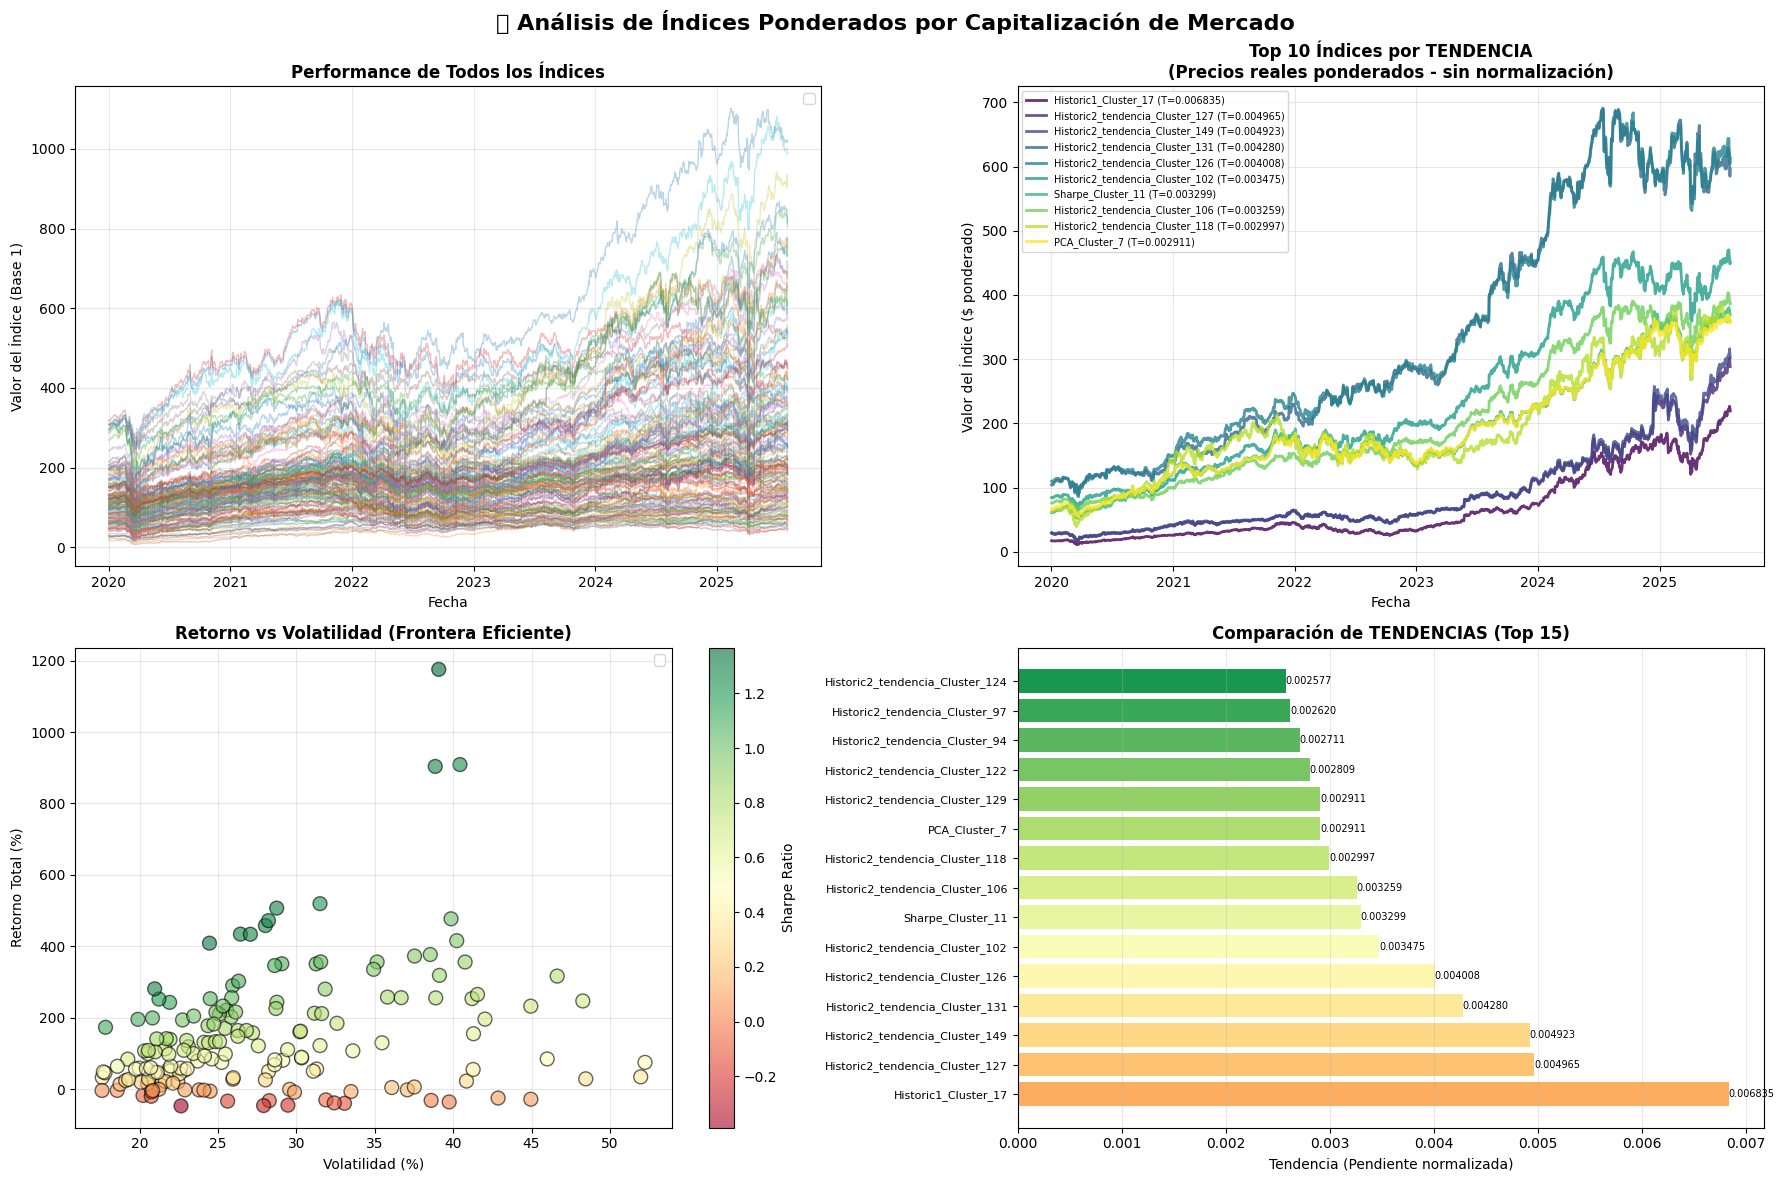

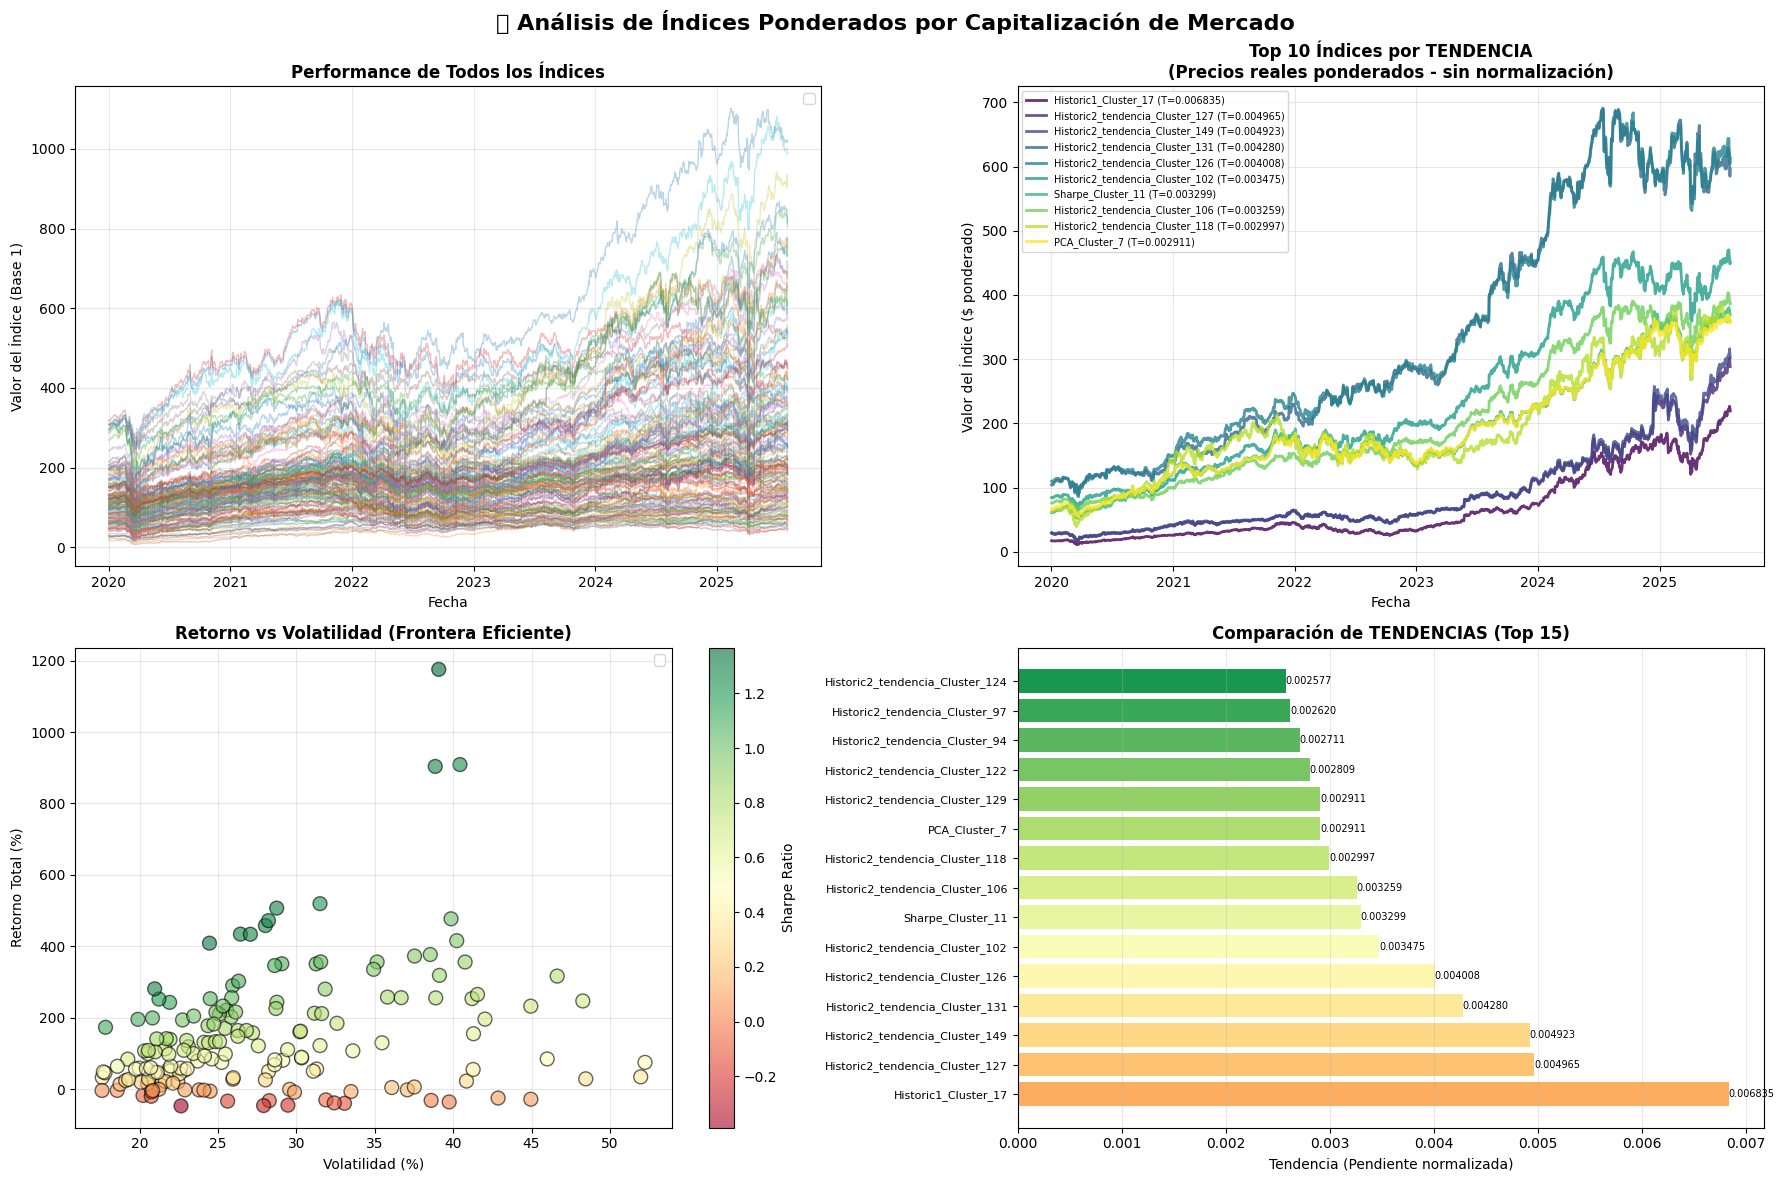

In [34]:

# Paso 4: Visualizar los índices
print("\n\n📊 Generando visualizaciones...")
plot_cluster_indices(
    cluster_indices=cluster_indices,
    benchmark_ticker='SPY',
    data=tickers_data,
    top_n=10
)

# Paso 5: Exportar a CSV
#print("\n\n💾 Exportando resultados...")
#indices_df, metrics_df = export_cluster_indices_to_csv(
#    cluster_indices=cluster_indices,filename='cluster_indices_market_cap_weighted.csv'


🔄 VALIDACIÓN CRUZADA: Top 10 del período de Análisis evaluados en Validación

📋 Top 10 clusters del período de ANÁLISIS (por Tendencia):
    1. Historic1_Cluster_17: Tendencia=0.006835, Ret=1175.45%, R²=0.774
    2. Historic2_tendencia_Cluster_127: Tendencia=0.004965, Ret=903.69%, R²=0.788
    3. Historic2_tendencia_Cluster_149: Tendencia=0.004923, Ret=908.88%, R²=0.773
    4. Historic2_tendencia_Cluster_131: Tendencia=0.004280, Ret=471.94%, R²=0.911
    5. Historic2_tendencia_Cluster_126: Tendencia=0.004008, Ret=458.08%, R²=0.911
    6. Historic2_tendencia_Cluster_102: Tendencia=0.003475, Ret=434.15%, R²=0.914
    7. Sharpe_Cluster_11: Tendencia=0.003299, Ret=506.95%, R²=0.891
    8. Historic2_tendencia_Cluster_106: Tendencia=0.003259, Ret=408.77%, R²=0.918
    9. Historic2_tendencia_Cluster_118: Tendencia=0.002997, Ret=476.99%, R²=0.798
   10. PCA_Cluster_7: Tendencia=0.002911, Ret=433.76%, R²=0.898

🔄 Recalculando índices con datos del período de VALIDACIÓN...
💰 NORMALIZANDO a $1 i

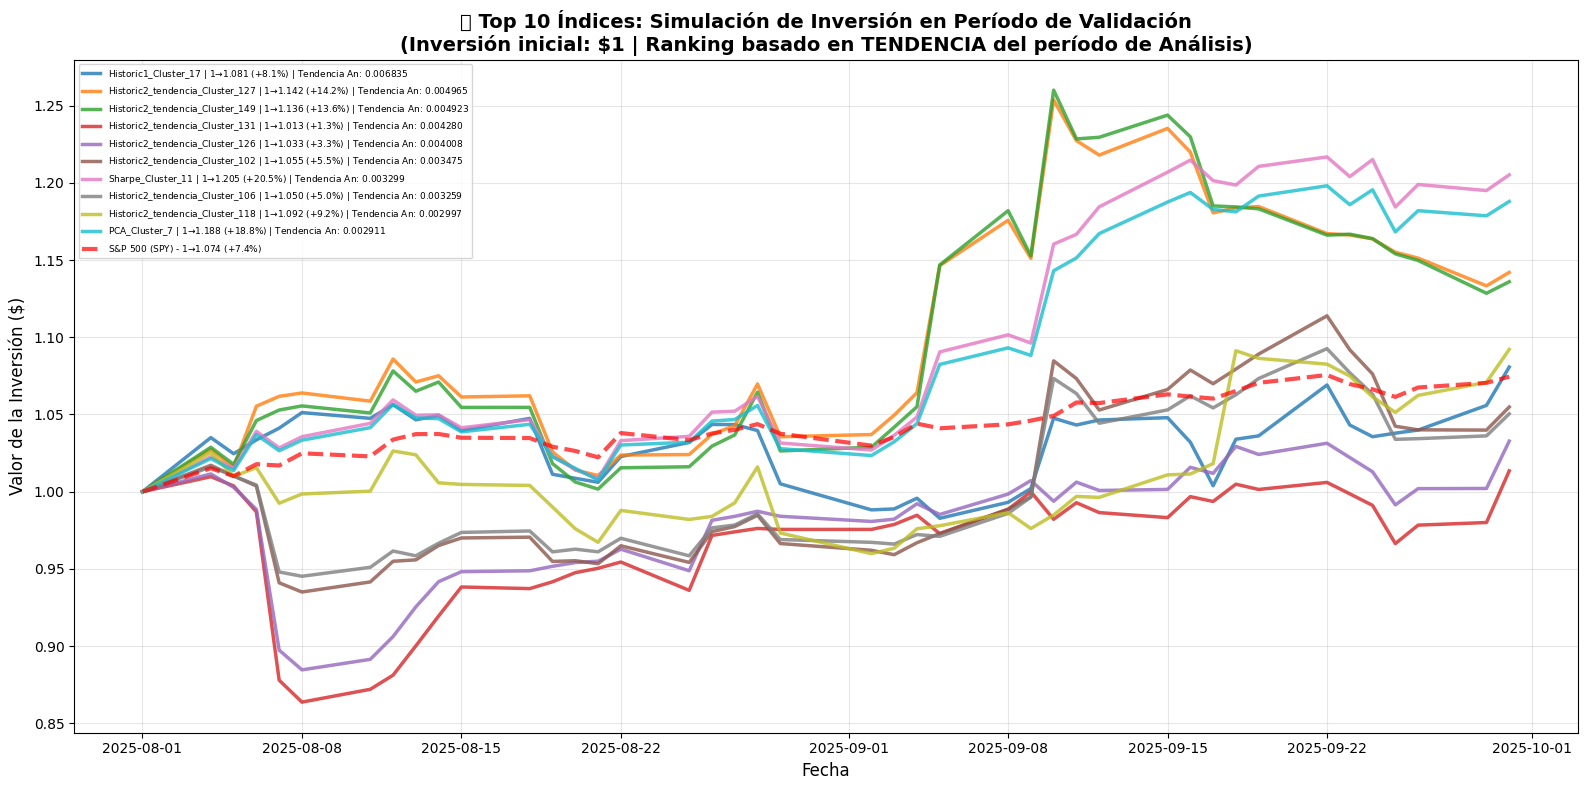


✅ Gráfica generada: Top 10 de Análisis evaluados en Validación
   💰 Simulación de inversión de $1 en cada índice
   📈 Ranking basado en TENDENCIA del período de Análisis
   🎯 Permite verificar si la inversión basada en tendencia fue rentable


In [35]:
# =======================================================
# 📊 VALIDACIÓN CRUZADA: Top 10 de Análisis en Validación
# =======================================================

print("\n" + "="*100)
print("🔄 VALIDACIÓN CRUZADA: Top 10 del período de Análisis evaluados en Validación")
print("="*100)

# Obtener los nombres de los Top 10 clusters del período de análisis
top_10_clusters_analysis = summary_df.head(10)['Cluster'].tolist()

print(f"\n📋 Top 10 clusters del período de ANÁLISIS (por Tendencia):")
for i, cluster_name in enumerate(top_10_clusters_analysis, 1):
    metrics_analysis = summary_df[summary_df['Cluster'] == cluster_name].iloc[0]
    print(f"   {i:2d}. {cluster_name}: Tendencia={metrics_analysis['Tendencia']:.6f}, Ret={metrics_analysis['Retorno (%)']:.2f}%, R²={metrics_analysis['R²']:.3f}")

# Crear índices para estos clusters usando datos de VALIDACIÓN
print(f"\n🔄 Recalculando índices con datos del período de VALIDACIÓN...")
print(f"💰 NORMALIZANDO a $1 inicial para simular inversión real")

cluster_indices_validation = {}
for cluster_name in top_10_clusters_analysis:
    cluster_info = all_clusters[cluster_name]
    cluster_tickers = cluster_info['tickers']
    
    # Crear índice con datos de validación (valores reales ponderados)
    index_series_real, weights = create_market_cap_weighted_index(
        cluster_tickers, validation_data, market_caps, start_value=1
    )
    
    if index_series_real is not None:
        # ✅ NORMALIZAR a $1 inicial para simular inversión
        index_series = (index_series_real / index_series_real.iloc[0]) * 1.0
        
        # Calcular métricas en período de validación (CON NORMALIZACIÓN - inversión desde $1)
        returns = index_series.pct_change().dropna()
        total_return = (index_series.iloc[-1] / index_series.iloc[0] - 1)
        volatility = returns.std() * np.sqrt(252)
        sharpe = (returns.mean() * 252) / (returns.std() * np.sqrt(252)) if returns.std() > 0 else 0
        max_drawdown = ((index_series / index_series.cummax()) - 1).min()
        
        # ✅ TENDENCIA en validación (sobre valores normalizados)
        x = np.arange(len(index_series))
        y = index_series.values
        trend_slope = np.polyfit(x, y, 1)[0]
        trend_slope_normalized = trend_slope / index_series.iloc[0]
        
        y_pred = np.polyval([trend_slope, np.polyfit(x, y, 1)[1]], x)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
        
        metrics = {
            'retorno_total': total_return,
            'volatilidad': volatility,
            'sharpe_ratio': sharpe,
            'max_drawdown': max_drawdown,
            'tendencia': trend_slope_normalized,
            'tendencia_absoluta': trend_slope,
            'r_squared': r_squared,
            'valor_final': index_series.iloc[-1],
            'valor_inicial': index_series.iloc[0],
            'num_tickers': len(weights)
        }
        
        cluster_indices_validation[cluster_name] = {
            'index': index_series,  # ✅ Serie normalizada (Base $1)
            'weights': weights,
            'metrics': metrics,
            'type': cluster_info['type']
        }

# Comparación de métricas
print(f"\n📊 COMPARACIÓN DE MÉTRICAS: Análisis vs Validación")
print("="*100)
print(f"{'Cluster':<20} {'Tendencia Análisis':>18} {'Tendencia Validación':>21} {'Diferencia':>12}")
print("-"*100)

for cluster_name in top_10_clusters_analysis:
    if cluster_name in cluster_indices_validation:
        trend_analysis = summary_df[summary_df['Cluster'] == cluster_name]['Tendencia'].values[0]
        trend_validation = cluster_indices_validation[cluster_name]['metrics']['tendencia']
        diff = trend_validation - trend_analysis
        
        symbol = "✅" if diff >= 0 else "⚠️"
        print(f"{symbol} {cluster_name:<18} {trend_analysis:>18.6f} {trend_validation:>21.6f} {diff:>12.6f}")

# Gráfica del Top 10 en período de validación (NORMALIZADO - inversión desde $1)
print(f"\n📈 Generando gráfica: Top 10 de Análisis en período de Validación...")
print(f"💵 Simulando inversión de $1 en cada índice")

fig, ax = plt.subplots(figsize=(16, 8))

colors = plt.cm.tab10(np.linspace(0, 1, len(top_10_clusters_analysis)))

for i, cluster_name in enumerate(top_10_clusters_analysis):
    if cluster_name in cluster_indices_validation:
        cluster_data = cluster_indices_validation[cluster_name]
        index_series = cluster_data['index']  # ✅ Valores NORMALIZADOS (Base $1)
        metrics_val = cluster_data['metrics']
        metrics_an = summary_df[summary_df['Cluster'] == cluster_name].iloc[0]
        
        ret_val_pct = metrics_val['retorno_total'] * 100
        valor_final = index_series.iloc[-1]
        trend_an = metrics_an['Tendencia']
        
        label = (f"{cluster_name} | $1 → ${valor_final:.3f} ({ret_val_pct:+.1f}%) | "
                f"Tendencia An: {trend_an:.6f}")
        
        ax.plot(index_series, label=label, linewidth=2.5, alpha=0.8, color=colors[i])

# Agregar SPY de validación (NORMALIZADO - inversión desde $1)
try:
    spy_validation_prices = SPY_validation['SPY'].dropna()
    spy_normalized = (spy_validation_prices / spy_validation_prices.iloc[0]) * 1.0
    spy_return = (spy_normalized.iloc[-1] / spy_normalized.iloc[0] - 1) * 100
    ax.plot(spy_normalized, linewidth=3, linestyle='--', color='red', 
            alpha=0.7, label=f'S&P 500 (SPY) - $1 → ${spy_normalized.iloc[-1]:.3f} ({spy_return:+.1f}%)')
except (NameError, KeyError):
    print("⚠️  SPY_validation no disponible")

ax.set_title(f'🔄 Top 10 Índices: Simulación de Inversión en Período de Validación\n(Inversión inicial: $1 | Ranking basado en TENDENCIA del período de Análisis)', 
            fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Valor de la Inversión ($)', fontsize=12)
ax.legend(fontsize=6.5, loc='upper left', ncol=1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✅ Gráfica generada: Top 10 de Análisis evaluados en Validación")
print(f"   💰 Simulación de inversión de $1 en cada índice")
print(f"   📈 Ranking basado en TENDENCIA del período de Análisis")
print(f"   🎯 Permite verificar si la inversión basada en tendencia fue rentable")
print("="*100)

## 🎯 Sistema de Selección Inteligente de Índices

Sistema multi-criterio para seleccionar índices con mayor confianza basado en:
- **Filtros de seguridad** (eliminatorios)
- **Scoring ponderado** (múltiples métricas)
- **Análisis de persistencia** (consistencia temporal)
- **Diversificación del cluster** (análisis de composición)

In [36]:
# =======================================================
# 🎯 SISTEMA DE SCORING COMPUESTO PARA SELECCIÓN DE ÍNDICES
# =======================================================

def calcular_diversificacion_cluster(cluster_name, all_clusters, ticker_info_db):
    """
    Calcula un score de diversificación para un cluster basado en:
    - Diversidad sectorial
    - Concentración de pesos
    - Número de tickers
    """
    cluster_info = all_clusters[cluster_name]
    tickers = cluster_info['tickers']
    
    # 1. Diversidad sectorial (Herfindahl-Hirschman Index inverso)
    sectors = [ticker_info_db.get(t, {}).get('sector', 'Unknown') for t in tickers]
    sector_counts = pd.Series(sectors).value_counts()
    hhi = (sector_counts / len(tickers)) ** 2
    diversidad_sectorial = 1 - hhi.sum()  # 0 = un sector, ~1 = muchos sectores
    
    # 2. Score por número de tickers (óptimo: 4-8 tickers)
    num_tickers = len(tickers)
    if 4 <= num_tickers <= 8:
        score_size = 1.0
    elif num_tickers < 4:
        score_size = num_tickers / 4.0
    else:
        score_size = max(0.5, 1.0 - (num_tickers - 8) * 0.05)
    
    return {
        'diversidad_sectorial': diversidad_sectorial,
        'score_size': score_size,
        'num_sectores': len(sector_counts),
        'sectores': sector_counts.to_dict()
    }


def calcular_persistencia_tendencia(cluster_name, cluster_indices_analysis, cluster_indices_validation):
    """
    Calcula qué tan consistente es la tendencia entre análisis y validación.
    """
    if cluster_name not in cluster_indices_validation:
        return 0.0
    
    trend_analysis = cluster_indices_analysis[cluster_name]['metrics']['tendencia']
    trend_validation = cluster_indices_validation[cluster_name]['metrics']['tendencia']
    
    # Si ambas son positivas y la diferencia es pequeña, alta persistencia
    if trend_analysis > 0 and trend_validation > 0:
        diff_ratio = abs(trend_validation - trend_analysis) / max(abs(trend_analysis), 1e-6)
        persistencia = max(0, 1 - diff_ratio)  # 1 = muy similar, 0 = muy diferente
    else:
        persistencia = 0.0
    
    return persistencia


def sistema_scoring_compuesto(summary_df, cluster_indices, all_clusters, 
                              cluster_indices_validation, ticker_info_db,
                              pesos_config=None):
    """
    Sistema de scoring multi-criterio para ranking de índices.
    
    Parámetros:
    -----------
    summary_df : pd.DataFrame
        DataFrame con métricas de análisis
    cluster_indices : dict
        Índices del período de análisis
    all_clusters : dict
        Información de clusters
    cluster_indices_validation : dict
        Índices del período de validación
    ticker_info_db : dict
        Base de datos de tickers
    pesos_config : dict
        Pesos para cada componente del score (default: None usa pesos por defecto)
    """
    
    # Pesos por defecto (configurables)
    if pesos_config is None:
        pesos_config = {
            'tendencia': 0.30,
            'r_squared': 0.20,
            'sharpe': 0.15,
            'drawdown': 0.10,
            'persistencia': 0.15,
            'diversificacion': 0.10
        }
    
    print("🎯 SISTEMA DE SCORING COMPUESTO")
    print("="*100)
    print(f"\n📊 Configuración de pesos:")
    for metric, peso in pesos_config.items():
        print(f"   • {metric.capitalize()}: {peso*100:.0f}%")
    
    # Paso 1: Filtros eliminatorios
    print(f"\n🔍 PASO 1: FILTROS DE SEGURIDAD (Eliminatorios)")
    print("-"*100)
    
    filtros = {
        'R² > 0.70': lambda row: row['R²'] > 0.70,
        'Tendencia > 0': lambda row: row['Tendencia'] > 0,
        'Max Drawdown > -35%': lambda row: row['Max Drawdown (%)'] > -35,
        'Volatilidad < 40%': lambda row: row['Volatilidad (%)'] < 40,
    }
    
    indices_filtrados = summary_df.copy()
    for filtro_name, filtro_func in filtros.items():
        antes = len(indices_filtrados)
        indices_filtrados = indices_filtrados[indices_filtrados.apply(filtro_func, axis=1)]
        despues = len(indices_filtrados)
        eliminados = antes - despues
        print(f"   ✓ {filtro_name:<25} → {despues:3d} índices pasan ({eliminados:2d} eliminados)")
    
    print(f"\n   📋 Total índices que pasan filtros: {len(indices_filtrados)}/{len(summary_df)}")
    
    # Paso 2: Normalizar métricas (0-1)
    print(f"\n📊 PASO 2: NORMALIZACIÓN Y SCORING")
    print("-"*100)
    
    scoring_results = []
    
    for idx, row in indices_filtrados.iterrows():
        cluster_name = row['Cluster']
        
        # Normalizar cada métrica entre 0 y 1
        # Tendencia (ya normalizada, pero escalar a 0-1)
        tendencia_norm = (row['Tendencia'] - summary_df['Tendencia'].min()) / \
                        (summary_df['Tendencia'].max() - summary_df['Tendencia'].min() + 1e-9)
        
        # R² (ya está entre 0 y 1)
        r_squared_norm = row['R²']
        
        # Sharpe Ratio (normalizar a 0-1)
        sharpe_norm = (row['Sharpe Ratio'] - summary_df['Sharpe Ratio'].min()) / \
                     (summary_df['Sharpe Ratio'].max() - summary_df['Sharpe Ratio'].min() + 1e-9)
        
        # Max Drawdown (convertir a score positivo)
        drawdown_norm = 1 - (abs(row['Max Drawdown (%)']) / 100)  # Menor drawdown = mejor
        
        # Persistencia (comparar con validación)
        persistencia = calcular_persistencia_tendencia(
            cluster_name, cluster_indices, cluster_indices_validation
        )
        
        # Diversificación del cluster
        div_info = calcular_diversificacion_cluster(cluster_name, all_clusters, ticker_info_db)
        diversificacion = (div_info['diversidad_sectorial'] + div_info['score_size']) / 2
        
        # Score compuesto ponderado
        score_total = (
            pesos_config['tendencia'] * tendencia_norm +
            pesos_config['r_squared'] * r_squared_norm +
            pesos_config['sharpe'] * sharpe_norm +
            pesos_config['drawdown'] * drawdown_norm +
            pesos_config['persistencia'] * persistencia +
            pesos_config['diversificacion'] * diversificacion
        )
        
        scoring_results.append({
            'Cluster': cluster_name,
            'Score_Total': score_total,
            'Score_Tendencia': tendencia_norm * pesos_config['tendencia'],
            'Score_R²': r_squared_norm * pesos_config['r_squared'],
            'Score_Sharpe': sharpe_norm * pesos_config['sharpe'],
            'Score_Drawdown': drawdown_norm * pesos_config['drawdown'],
            'Score_Persistencia': persistencia * pesos_config['persistencia'],
            'Score_Diversificacion': diversificacion * pesos_config['diversificacion'],
            'Tendencia': row['Tendencia'],
            'R²': row['R²'],
            'Sharpe_Ratio': row['Sharpe Ratio'],
            'Retorno_%': row['Retorno (%)'],
            'Volatilidad_%': row['Volatilidad (%)'],
            'Max_Drawdown_%': row['Max Drawdown (%)'],
            'Persistencia': persistencia,
            'Diversificacion': diversificacion,
            'Num_Sectores': div_info['num_sectores'],
            'Num_Tickers': row['Tickers']
        })
    
    # Crear DataFrame con resultados
    scoring_df = pd.DataFrame(scoring_results)
    scoring_df = scoring_df.sort_values('Score_Total', ascending=False)
    
    return scoring_df


# EJECUTAR SISTEMA DE SCORING
print("\n" + "="*100)
print("🚀 EJECUTANDO SISTEMA DE SELECCIÓN INTELIGENTE DE ÍNDICES")
print("="*100)

# Configuración de pesos (ajustable)
pesos_personalizados = {
    'tendencia': 0.30,      # 30% - Métrica principal de crecimiento
    'r_squared': 0.20,      # 20% - Calidad/consistencia de la tendencia
    'sharpe': 0.15,         # 15% - Relación riesgo-retorno
    'drawdown': 0.10,       # 10% - Control de pérdida máxima
    'persistencia': 0.15,   # 15% - Consistencia temporal
    'diversificacion': 0.10 # 10% - Diversidad del cluster
}

scoring_df = sistema_scoring_compuesto(
    summary_df=summary_df,
    cluster_indices=cluster_indices,
    all_clusters=all_clusters,
    cluster_indices_validation=cluster_indices_validation,
    ticker_info_db=ticker_info_db,
    pesos_config=pesos_personalizados
)

print(f"\n✅ Scoring completado para {len(scoring_df)} índices")
print("="*100)


🚀 EJECUTANDO SISTEMA DE SELECCIÓN INTELIGENTE DE ÍNDICES
🎯 SISTEMA DE SCORING COMPUESTO

📊 Configuración de pesos:
   • Tendencia: 30%
   • R_squared: 20%
   • Sharpe: 15%
   • Drawdown: 10%
   • Persistencia: 15%
   • Diversificacion: 10%

🔍 PASO 1: FILTROS DE SEGURIDAD (Eliminatorios)
----------------------------------------------------------------------------------------------------
   ✓ R² > 0.70                 →  85 índices pasan (83 eliminados)
   ✓ Tendencia > 0             →  84 índices pasan ( 1 eliminados)
   ✓ Max Drawdown > -35%       →  44 índices pasan (40 eliminados)
   ✓ Volatilidad < 40%         →  44 índices pasan ( 0 eliminados)

   📋 Total índices que pasan filtros: 44/168

📊 PASO 2: NORMALIZACIÓN Y SCORING
----------------------------------------------------------------------------------------------------

✅ Scoring completado para 44 índices


In [37]:
# =======================================================
# 📊 RESULTADOS DEL SISTEMA DE SCORING
# =======================================================

print("\n" + "="*100)
print("🏆 TOP 15 ÍNDICES POR SCORE COMPUESTO")
print("="*100)

# Mostrar tabla completa
display_cols = ['Cluster', 'Score_Total', 'Tendencia', 'R²', 'Sharpe_Ratio', 
                'Retorno_%', 'Max_Drawdown_%', 'Persistencia', 'Diversificacion', 
                'Num_Sectores', 'Num_Tickers']

print("\n📋 Tabla Completa (Top 15):")
print(scoring_df[display_cols].head(15).to_string(index=False))

# Desglose de componentes del score
print("\n\n🔍 DESGLOSE DE SCORES (Top 10):")
print("="*100)
desglose_cols = ['Cluster', 'Score_Total', 'Score_Tendencia', 'Score_R²', 
                'Score_Sharpe', 'Score_Drawdown', 'Score_Persistencia', 'Score_Diversificacion']
print(scoring_df[desglose_cols].head(10).to_string(index=False))

# Estadísticas
print("\n\n📊 ESTADÍSTICAS DE LOS TOP 10:")
print("="*100)
top_10_scoring = scoring_df.head(10)
print(f"   📈 Score promedio: {top_10_scoring['Score_Total'].mean():.4f}")
print(f"   📊 Tendencia promedio: {top_10_scoring['Tendencia'].mean():.6f}")
print(f"   📊 R² promedio: {top_10_scoring['R²'].mean():.3f}")
print(f"   ⭐ Sharpe promedio: {top_10_scoring['Sharpe_Ratio'].mean():.2f}")
print(f"   💹 Retorno promedio: {top_10_scoring['Retorno_%'].mean():.2f}%")
print(f"   📉 Max Drawdown promedio: {top_10_scoring['Max_Drawdown_%'].mean():.2f}%")
print(f"   🔄 Persistencia promedio: {top_10_scoring['Persistencia'].mean():.3f}")
print(f"   🎯 Diversificación promedio: {top_10_scoring['Diversificacion'].mean():.3f}")
print(f"   🏢 Sectores promedio: {top_10_scoring['Num_Sectores'].mean():.1f}")

# Comparación: TOP 10 por Score vs TOP 10 por Tendencia
print("\n\n🔄 COMPARACIÓN: Top 10 por SCORE vs Top 10 por TENDENCIA")
print("="*100)

top_10_por_score = set(scoring_df.head(10)['Cluster'].tolist())
top_10_por_tendencia = set(summary_df.head(10)['Cluster'].tolist())

coincidencias = top_10_por_score.intersection(top_10_por_tendencia)
solo_score = top_10_por_score - top_10_por_tendencia
solo_tendencia = top_10_por_tendencia - top_10_por_score

print(f"\n✅ Índices en AMBOS Top 10 ({len(coincidencias)}):")
for cluster in coincidencias:
    score_rank = scoring_df[scoring_df['Cluster'] == cluster].index[0] + 1
    trend_rank = summary_df[summary_df['Cluster'] == cluster].index[0] + 1
    print(f"   • {cluster}: Score Rank #{score_rank}, Tendencia Rank #{trend_rank}")

print(f"\n🆕 Índices NUEVOS en Top 10 Score (no estaban en Top 10 Tendencia) ({len(solo_score)}):")
for cluster in solo_score:
    row = scoring_df[scoring_df['Cluster'] == cluster].iloc[0]
    print(f"   • {cluster}:")
    print(f"      Score: {row['Score_Total']:.4f} | Tendencia: {row['Tendencia']:.6f} | R²: {row['R²']:.3f} | Persistencia: {row['Persistencia']:.3f}")

print(f"\n❌ Índices REMOVIDOS del Top 10 (estaban en Top 10 Tendencia, no en Top 10 Score) ({len(solo_tendencia)}):")
for cluster in solo_tendencia:
    row = summary_df[summary_df['Cluster'] == cluster].iloc[0]
    # Buscar su score
    if cluster in scoring_df['Cluster'].values:
        score_row = scoring_df[scoring_df['Cluster'] == cluster].iloc[0]
        print(f"   • {cluster}:")
        print(f"      Tendencia: {row['Tendencia']:.6f} | R²: {row['R²']:.3f} | Score: {score_row['Score_Total']:.4f} (Rank #{scoring_df[scoring_df['Cluster'] == cluster].index[0] + 1})")
    else:
        print(f"   • {cluster}: NO PASÓ FILTROS DE SEGURIDAD")

print("\n" + "="*100)


🏆 TOP 15 ÍNDICES POR SCORE COMPUESTO

📋 Tabla Completa (Top 15):
                        Cluster  Score_Total  Tendencia       R²  Sharpe_Ratio  Retorno_%  Max_Drawdown_%  Persistencia  Diversificacion  Num_Sectores  Num_Tickers
Historic2_tendencia_Cluster_102     0.772500   0.003475 0.914281      1.271940 434.152688      -27.317386      0.904560         0.655623             7           17
Historic2_tendencia_Cluster_106     0.752661   0.003259 0.918452      1.318612 408.769252      -28.021473      0.809442         0.640023             6           21
Historic2_tendencia_Cluster_131     0.745122   0.004280 0.911018      1.251526 471.938504      -22.603453      0.418571         0.785714             3            7
Historic2_tendencia_Cluster_126     0.744839   0.004008 0.910703      1.242936 458.079679      -26.493416      0.527564         0.768056             6           12
              Sharpe_Cluster_11     0.665188   0.003299 0.890600      1.272509 506.947233      -30.521516      0.2


📊 Generando visualizaciones del Top 10 por Score Compuesto...


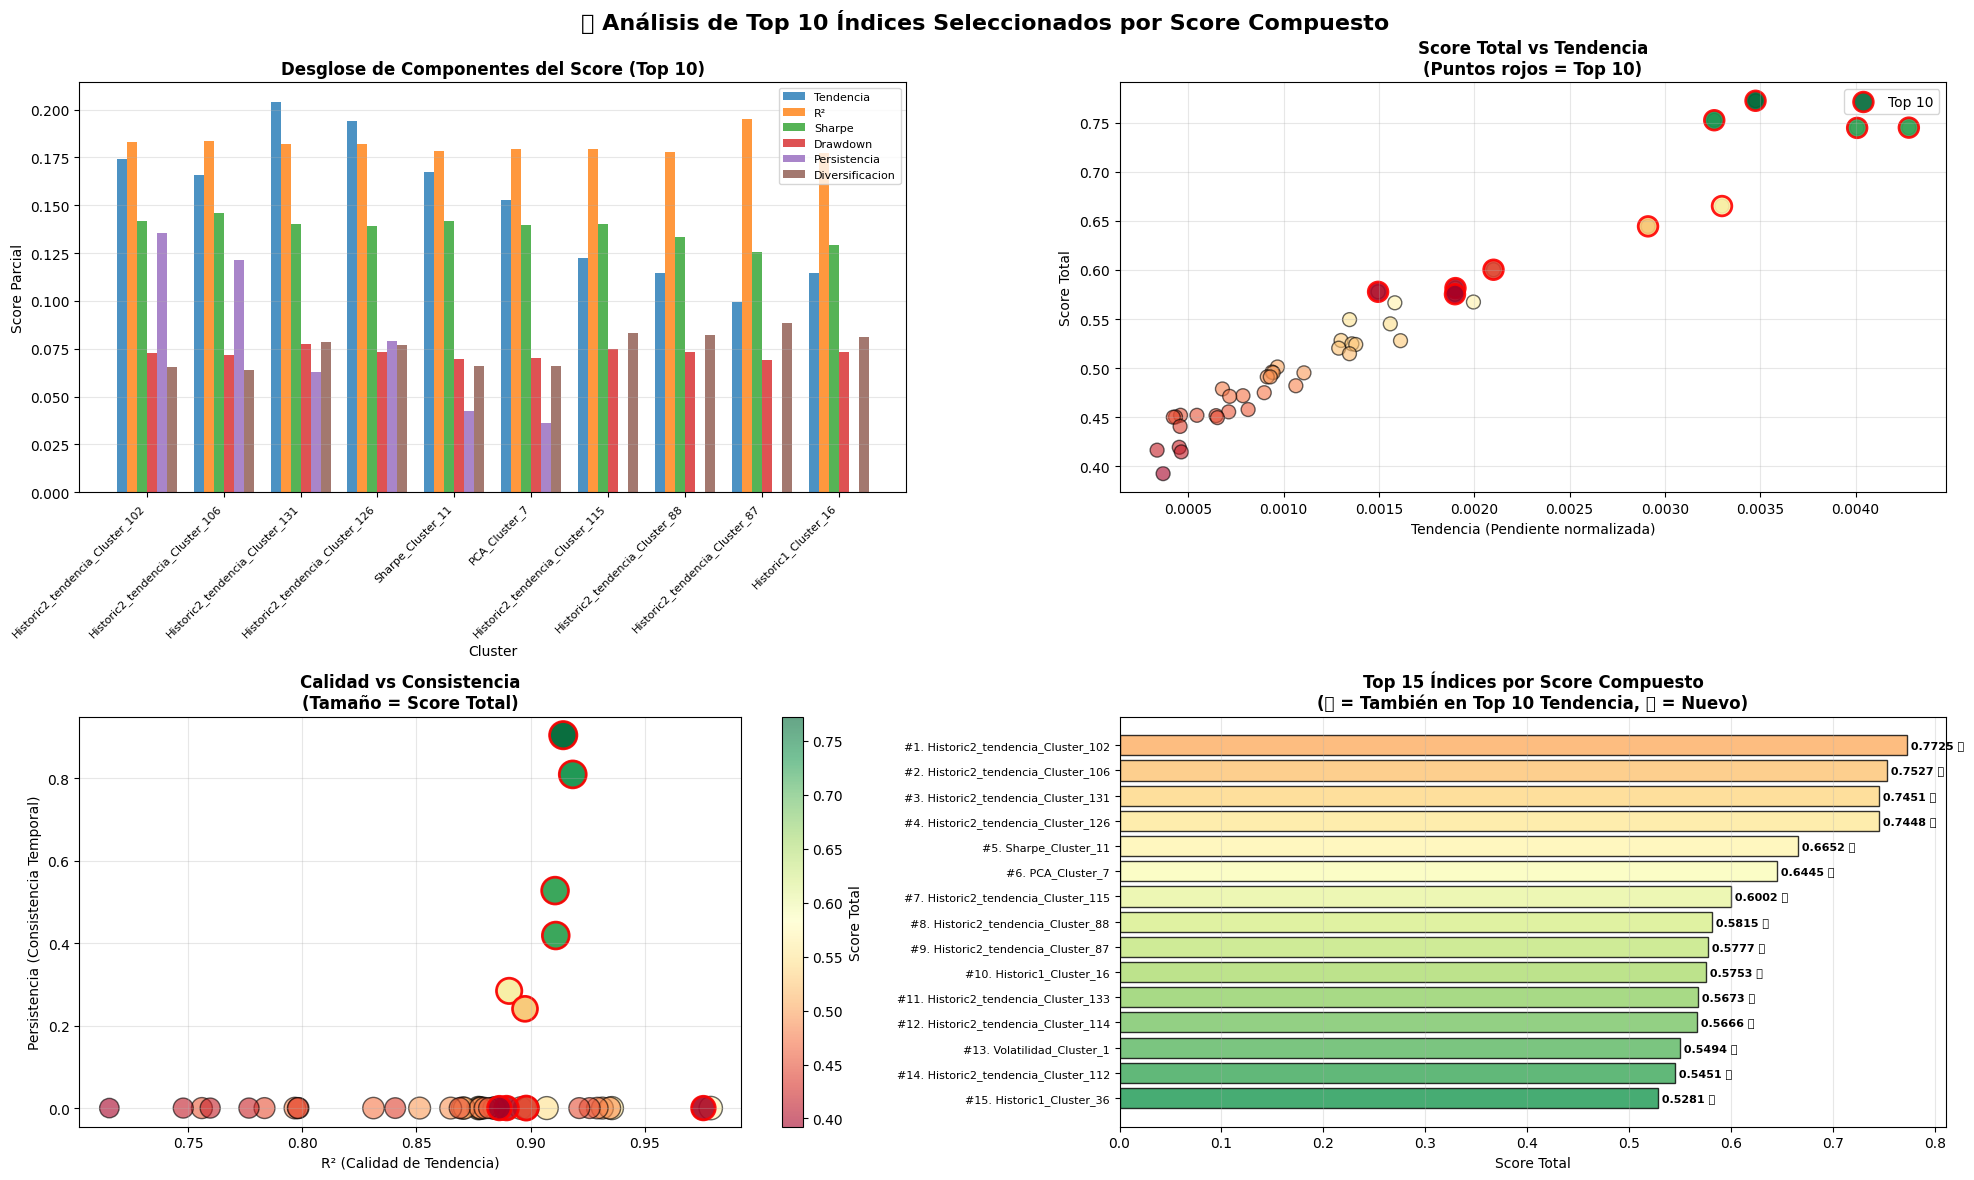

✅ Visualizaciones generadas


In [38]:
# =======================================================
# 📈 VISUALIZACIÓN: TOP 10 POR SCORE COMPUESTO
# =======================================================

print("\n📊 Generando visualizaciones del Top 10 por Score Compuesto...")

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('🎯 Análisis de Top 10 Índices Seleccionados por Score Compuesto', 
             fontsize=16, fontweight='bold')

# Subplot 1: Comparación de componentes del score
ax1 = axes[0, 0]
top_10_scoring = scoring_df.head(10)
componentes = ['Score_Tendencia', 'Score_R²', 'Score_Sharpe', 
               'Score_Drawdown', 'Score_Persistencia', 'Score_Diversificacion']
x = np.arange(len(top_10_scoring))
width = 0.13

for i, comp in enumerate(componentes):
    values = top_10_scoring[comp].values
    ax1.bar(x + i*width, values, width, label=comp.replace('Score_', ''), alpha=0.8)

ax1.set_xlabel('Cluster')
ax1.set_ylabel('Score Parcial')
ax1.set_title('Desglose de Componentes del Score (Top 10)', fontweight='bold')
ax1.set_xticks(x + width * 2.5)
ax1.set_xticklabels(top_10_scoring['Cluster'].values, rotation=45, ha='right', fontsize=8)
ax1.legend(fontsize=8, loc='upper right')
ax1.grid(True, alpha=0.3, axis='y')

# Subplot 2: Score Total vs Tendencia
ax2 = axes[0, 1]
ax2.scatter(scoring_df['Tendencia'], scoring_df['Score_Total'], 
           s=100, alpha=0.6, c=scoring_df['Score_Total'], cmap='RdYlGn', edgecolors='black')

# Resaltar Top 10
top_10_data = scoring_df.head(10)
ax2.scatter(top_10_data['Tendencia'], top_10_data['Score_Total'], 
           s=200, alpha=0.9, c=top_10_data['Score_Total'], cmap='RdYlGn', 
           edgecolors='red', linewidth=2, label='Top 10')

ax2.set_xlabel('Tendencia (Pendiente normalizada)')
ax2.set_ylabel('Score Total')
ax2.set_title('Score Total vs Tendencia\n(Puntos rojos = Top 10)', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Subplot 3: Persistencia vs R²
ax3 = axes[1, 0]
scatter = ax3.scatter(scoring_df['R²'], scoring_df['Persistencia'], 
                     s=scoring_df['Score_Total']*500, 
                     alpha=0.6, c=scoring_df['Score_Total'], 
                     cmap='RdYlGn', edgecolors='black')

# Resaltar Top 10
ax3.scatter(top_10_data['R²'], top_10_data['Persistencia'], 
           s=top_10_data['Score_Total']*500, 
           alpha=0.9, c=top_10_data['Score_Total'], 
           cmap='RdYlGn', edgecolors='red', linewidth=2)

ax3.set_xlabel('R² (Calidad de Tendencia)')
ax3.set_ylabel('Persistencia (Consistencia Temporal)')
ax3.set_title('Calidad vs Consistencia\n(Tamaño = Score Total)', fontweight='bold')
ax3.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax3, label='Score Total')

# Subplot 4: Ranking comparison
ax4 = axes[1, 1]
top_15_clusters = scoring_df.head(15)['Cluster'].tolist()
scores = scoring_df.head(15)['Score_Total'].values
colors_bars = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_15_clusters)))

bars = ax4.barh(range(len(top_15_clusters)), scores, color=colors_bars, alpha=0.8, edgecolor='black')

# Añadir valores en las barras
for i, (bar, cluster) in enumerate(zip(bars, top_15_clusters)):
    width = bar.get_width()
    # Verificar si está en Top 10 por tendencia
    if cluster in summary_df.head(10)['Cluster'].values:
        marker = "✅"
    else:
        marker = "🆕"
    ax4.text(width, bar.get_y() + bar.get_height()/2, 
            f' {width:.4f} {marker}', ha='left', va='center', fontsize=8, fontweight='bold')

ax4.set_yticks(range(len(top_15_clusters)))
ax4.set_yticklabels([f"#{i+1}. {c}" for i, c in enumerate(top_15_clusters)], fontsize=8)
ax4.set_xlabel('Score Total')
ax4.set_title('Top 15 Índices por Score Compuesto\n(✅ = También en Top 10 Tendencia, 🆕 = Nuevo)', fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')
ax4.invert_yaxis()

plt.tight_layout()
plt.show()

print("✅ Visualizaciones generadas")

In [39]:
# =======================================================
# 💰 VALIDACIÓN: TOP 10 POR SCORE en Período de Validación
# =======================================================

print("\n" + "="*100)
print("💰 VALIDACIÓN: Top 10 por SCORE COMPUESTO en Período de Validación")
print("="*100)

# Obtener los nombres de los Top 10 clusters por SCORE
top_10_clusters_score = scoring_df.head(10)['Cluster'].tolist()

print(f"\n📋 Top 10 clusters seleccionados por SCORE COMPUESTO:")
for i, cluster_name in enumerate(top_10_clusters_score, 1):
    score_row = scoring_df[scoring_df['Cluster'] == cluster_name].iloc[0]
    print(f"   {i:2d}. {cluster_name}:")
    print(f"       Score: {score_row['Score_Total']:.4f} | Tendencia: {score_row['Tendencia']:.6f} | "
          f"R²: {score_row['R²']:.3f} | Persistencia: {score_row['Persistencia']:.3f}")

# Calcular performance en validación para estos índices
print(f"\n💵 Simulando inversión de $1 en cada índice (período de validación)...")

validation_results = []
for cluster_name in top_10_clusters_score:
    if cluster_name in cluster_indices_validation:
        metrics_val = cluster_indices_validation[cluster_name]['metrics']
        score_row = scoring_df[scoring_df['Cluster'] == cluster_name].iloc[0]
        
        # Verificar que existan todas las claves necesarias
        if all(k in metrics_val for k in ['valor_final', 'retorno_total', 'sharpe_ratio', 'max_drawdown', 'tendencia']):
            validation_results.append({
                'Cluster': cluster_name,
                'Score_Total': score_row['Score_Total'],
                'Valor_Final': metrics_val['valor_final'],
                'Retorno_%': metrics_val['retorno_total'] * 100,
                'Sharpe_Val': metrics_val['sharpe_ratio'],
                'Max_DD_%': metrics_val['max_drawdown'] * 100,
                'Tendencia_Val': metrics_val['tendencia']
            })
        else:
            print(f"⚠️  {cluster_name}: Faltan métricas de validación")
    else:
        print(f"⚠️  {cluster_name}: No está en cluster_indices_validation")

# Verificar que tengamos datos para mostrar
if len(validation_results) == 0:
    print("\n❌ No hay datos de validación disponibles para los clusters seleccionados.")
    print("   Verifica que cluster_indices_validation se haya creado correctamente.")
else:
    validation_results_df = pd.DataFrame(validation_results)
    validation_results_df = validation_results_df.sort_values('Retorno_%', ascending=False)

    print(f"\n📊 RESULTADOS EN VALIDACIÓN (Top 10 por Score):")
    print("="*100)
    print(validation_results_df.to_string(index=False))

    # Estadísticas comparativas
    print(f"\n\n📊 ESTADÍSTICAS DE VALIDACIÓN:")
    print("="*100)
    print(f"   💵 Valor final promedio: ${validation_results_df['Valor_Final'].mean():.4f}")
    print(f"   📈 Retorno promedio: {validation_results_df['Retorno_%'].mean():.2f}%")
    print(f"   ⭐ Sharpe promedio: {validation_results_df['Sharpe_Val'].mean():.2f}")
    print(f"   📉 Max Drawdown promedio: {validation_results_df['Max_DD_%'].mean():.2f}%")
    print(f"   🎯 Índices con retorno positivo: {(validation_results_df['Retorno_%'] > 0).sum()}/{len(validation_results_df)}")

    # Comparar con SPY
    try:
        spy_return = (spy_normalized.iloc[-1] / spy_normalized.iloc[0] - 1) * 100
        indices_superan_spy = (validation_results_df['Retorno_%'] > spy_return).sum()
        print(f"   📊 SPY retorno: {spy_return:.2f}%")
        print(f"   🏆 Índices que superan SPY: {indices_superan_spy}/{len(validation_results_df)}")
    except:
        print(f"   ⚠️  SPY no disponible para comparación")

    print("="*100)



💰 VALIDACIÓN: Top 10 por SCORE COMPUESTO en Período de Validación

📋 Top 10 clusters seleccionados por SCORE COMPUESTO:
    1. Historic2_tendencia_Cluster_102:
       Score: 0.7725 | Tendencia: 0.003475 | R²: 0.914 | Persistencia: 0.905
    2. Historic2_tendencia_Cluster_106:
       Score: 0.7527 | Tendencia: 0.003259 | R²: 0.918 | Persistencia: 0.809
    3. Historic2_tendencia_Cluster_131:
       Score: 0.7451 | Tendencia: 0.004280 | R²: 0.911 | Persistencia: 0.419
    4. Historic2_tendencia_Cluster_126:
       Score: 0.7448 | Tendencia: 0.004008 | R²: 0.911 | Persistencia: 0.528
    5. Sharpe_Cluster_11:
       Score: 0.6652 | Tendencia: 0.003299 | R²: 0.891 | Persistencia: 0.284
    6. PCA_Cluster_7:
       Score: 0.6445 | Tendencia: 0.002911 | R²: 0.898 | Persistencia: 0.241
    7. Historic2_tendencia_Cluster_115:
       Score: 0.6002 | Tendencia: 0.002101 | R²: 0.898 | Persistencia: 0.000
    8. Historic2_tendencia_Cluster_88:
       Score: 0.5815 | Tendencia: 0.001901 | R²: 0.88


📈 Generando gráfica comparativa: Score vs Tendencia en Validación...


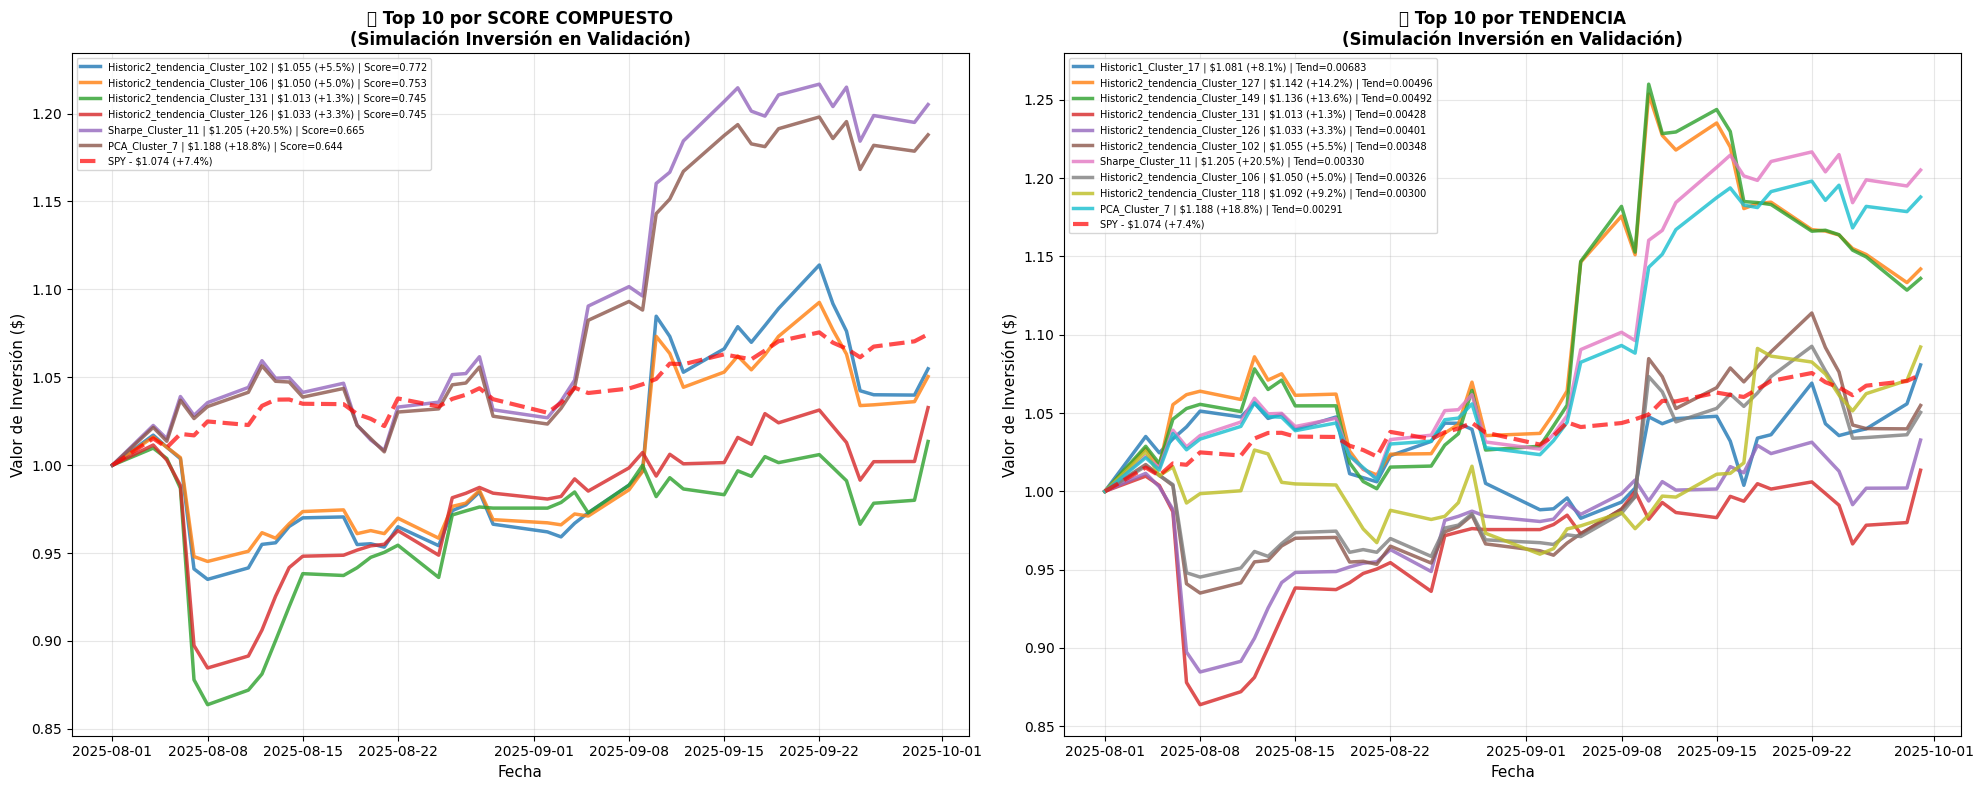

✅ Gráfica comparativa generada



In [40]:
# =======================================================
# 📊 GRÁFICA COMPARATIVA: Top 10 Score vs Top 10 Tendencia en Validación
# =======================================================

print("\n📈 Generando gráfica comparativa: Score vs Tendencia en Validación...")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Subplot 1: Top 10 por SCORE
ax1 = axes[0]
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for i, cluster_name in enumerate(top_10_clusters_score):
    if cluster_name in cluster_indices_validation:
        cluster_data = cluster_indices_validation[cluster_name]
        index_series = cluster_data['index']
        metrics = cluster_data['metrics']
        score_row = scoring_df[scoring_df['Cluster'] == cluster_name].iloc[0]
        
        label = f"{cluster_name} | ${index_series.iloc[-1]:.3f} ({metrics['retorno_total']*100:+.1f}%) | Score={score_row['Score_Total']:.3f}"
        ax1.plot(index_series, label=label, linewidth=2.5, alpha=0.8, color=colors[i])

# SPY
try:
    ax1.plot(spy_normalized, linewidth=3, linestyle='--', color='red', 
            alpha=0.7, label=f'SPY - ${spy_normalized.iloc[-1]:.3f} ({spy_return:+.1f}%)')
except:
    pass

ax1.set_title('🎯 Top 10 por SCORE COMPUESTO\n(Simulación Inversión en Validación)', 
             fontsize=12, fontweight='bold')
ax1.set_xlabel('Fecha', fontsize=11)
ax1.set_ylabel('Valor de Inversión ($)', fontsize=11)
ax1.legend(fontsize=7, loc='upper left')
ax1.grid(True, alpha=0.3)

# Subplot 2: Top 10 por TENDENCIA (original)
ax2 = axes[1]

for i, cluster_name in enumerate(top_10_clusters_analysis):
    if cluster_name in cluster_indices_validation:
        cluster_data = cluster_indices_validation[cluster_name]
        index_series = cluster_data['index']
        metrics = cluster_data['metrics']
        metrics_an = summary_df[summary_df['Cluster'] == cluster_name].iloc[0]
        
        label = f"{cluster_name} | ${index_series.iloc[-1]:.3f} ({metrics['retorno_total']*100:+.1f}%) | Tend={metrics_an['Tendencia']:.5f}"
        ax2.plot(index_series, label=label, linewidth=2.5, alpha=0.8, color=colors[i])

# SPY
try:
    ax2.plot(spy_normalized, linewidth=3, linestyle='--', color='red', 
            alpha=0.7, label=f'SPY - ${spy_normalized.iloc[-1]:.3f} ({spy_return:+.1f}%)')
except:
    pass

ax2.set_title('📈 Top 10 por TENDENCIA\n(Simulación Inversión en Validación)', 
             fontsize=12, fontweight='bold')
ax2.set_xlabel('Fecha', fontsize=11)
ax2.set_ylabel('Valor de Inversión ($)', fontsize=11)
ax2.legend(fontsize=7, loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Gráfica comparativa generada")
print("\n" + "="*100)

In [41]:
# =======================================================
# 🎯 RECOMENDACIÓN FINAL Y ANÁLISIS DETALLADO
# =======================================================

print("\n" + "="*100)
print("🎯 RECOMENDACIÓN FINAL DE INVERSIÓN")
print("="*100)

# Top 5 por score
top_5_score = scoring_df.head(5)

print("\n🏆 TOP 5 ÍNDICES RECOMENDADOS (Mayor confianza):")
print("="*100)

for i, (idx, row) in enumerate(top_5_score.iterrows(), 1):
    cluster_name = row['Cluster']
    
    print(f"\n#{i}. {cluster_name}")
    print("-"*100)
    
    # Información del cluster
    cluster_info = all_clusters[cluster_name]
    print(f"   📊 Tipo de análisis: {cluster_info['type']}")
    print(f"   🎯 Tickers ({len(cluster_info['tickers'])}): {', '.join(cluster_info['tickers'])}")
    
    # Sectores
    tickers_list = cluster_info['tickers']
    sectores = {}
    for ticker in tickers_list:
        sector = ticker_info_db.get(ticker, {}).get('sector', 'Unknown')
        sectores[sector] = sectores.get(sector, 0) + 1
    print(f"   🏢 Sectores representados: {', '.join([f'{s} ({c})' for s, c in sectores.items()])}")
    
    # Métricas de análisis
    print(f"\n   📈 MÉTRICAS DEL PERÍODO DE ANÁLISIS:")
    print(f"      • Score Total: {row['Score_Total']:.4f}")
    print(f"      • Tendencia: {row['Tendencia']:.6f}")
    print(f"      • R² (Calidad): {row['R²']:.3f}")
    print(f"      • Sharpe Ratio: {row['Sharpe_Ratio']:.2f}")
    print(f"      • Retorno: {row['Retorno_%']:.2f}%")
    print(f"      • Max Drawdown: {row['Max_Drawdown_%']:.2f}%")
    print(f"      • Persistencia: {row['Persistencia']:.3f}")
    print(f"      • Diversificación: {row['Diversificacion']:.3f}")
    
    # Métricas de validación
    if cluster_name in cluster_indices_validation:
        val_metrics = cluster_indices_validation[cluster_name]['metrics']
        print(f"\n   💰 RESULTADOS EN VALIDACIÓN (Inversión de $1):")
        print(f"      • Valor final: ${val_metrics['valor_final']:.4f}")
        print(f"      • Retorno: {val_metrics['retorno_total']*100:+.2f}%")
        print(f"      • Sharpe: {val_metrics['sharpe_ratio']:.2f}")
        print(f"      • Max Drawdown: {val_metrics['max_drawdown']*100:.2f}%")
        
        # Comparar con SPY
        try:
            if val_metrics['retorno_total']*100 > spy_return:
                print(f"      ✅ SUPERA SPY por {val_metrics['retorno_total']*100 - spy_return:.2f} puntos porcentuales")
            else:
                print(f"      ⚠️  Por debajo de SPY por {spy_return - val_metrics['retorno_total']*100:.2f} puntos porcentuales")
        except:
            pass
    
    # Nivel de confianza
    if row['Score_Total'] >= 0.7:
        confianza = "🟢 MUY ALTA"
    elif row['Score_Total'] >= 0.6:
        confianza = "🟡 ALTA"
    elif row['Score_Total'] >= 0.5:
        confianza = "🟠 MEDIA"
    else:
        confianza = "🔴 BAJA"
    
    print(f"\n   🎯 NIVEL DE CONFIANZA: {confianza}")

# Resumen ejecutivo
print("\n\n" + "="*100)
print("📋 RESUMEN EJECUTIVO")
print("="*100)

# Calcular retornos promedio
top_5_validation_returns = []
for cluster_name in top_5_score['Cluster'].tolist():
    if cluster_name in cluster_indices_validation:
        ret = cluster_indices_validation[cluster_name]['metrics']['retorno_total'] * 100
        top_5_validation_returns.append(ret)

if top_5_validation_returns:
    avg_return = np.mean(top_5_validation_returns)
    print(f"\n💰 Si hubieras invertido en el TOP 5 por Score:")
    print(f"   • Retorno promedio en validación: {avg_return:.2f}%")
    print(f"   • $1 invertido valdría en promedio: ${1 + avg_return/100:.4f}")
    print(f"   • Índices con retorno positivo: {sum([r > 0 for r in top_5_validation_returns])}/5")
    
    try:
        print(f"\n📊 Comparación con SPY:")
        print(f"   • Retorno SPY: {spy_return:.2f}%")
        print(f"   • Diferencia: {avg_return - spy_return:+.2f} puntos porcentuales")
        if avg_return > spy_return:
            print(f"   ✅ El Top 5 por Score SUPERA al S&P 500")
        else:
            print(f"   ⚠️  El Top 5 por Score está por debajo del S&P 500")
    except:
        pass

print("\n" + "="*100)
print("✅ Análisis completo finalizado")
print("="*100)


🎯 RECOMENDACIÓN FINAL DE INVERSIÓN

🏆 TOP 5 ÍNDICES RECOMENDADOS (Mayor confianza):

#1. Historic2_tendencia_Cluster_102
----------------------------------------------------------------------------------------------------
   📊 Tipo de análisis: Historic2_tendencia
   🎯 Tickers (17): BX, CDNS, DECK, ETN, FTNT, JBL, KKR, KLAC, LLY, MPC, ORCL, PANW, SNPS, STLD, TPL, TRGP, URI
   🏢 Sectores representados: Financial Services (2), Technology (7), Consumer Cyclical (1), Industrials (2), Healthcare (1), Energy (3), Basic Materials (1)

   📈 MÉTRICAS DEL PERÍODO DE ANÁLISIS:
      • Score Total: 0.7725
      • Tendencia: 0.003475
      • R² (Calidad): 0.914
      • Sharpe Ratio: 1.27
      • Retorno: 434.15%
      • Max Drawdown: -27.32%
      • Persistencia: 0.905
      • Diversificación: 0.656

   💰 RESULTADOS EN VALIDACIÓN (Inversión de $1):
      • Valor final: $1.0548
      • Retorno: +5.48%
      • Sharpe: 1.15
      • Max Drawdown: -8.07%
      ⚠️  Por debajo de SPY por 1.97 puntos porc

## 🤖 Machine Learning: Predicción de Mejores Índices

Uso de modelos de ML para predecir qué índices tendrán mejor performance en validación basándose en sus métricas del período de análisis.

In [42]:
# =======================================================
# 🤖 PREPARACIÓN DE DATOS PARA MACHINE LEARNING
# =======================================================

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler as SKStandardScaler

print("🤖 SISTEMA DE MACHINE LEARNING PARA PREDICCIÓN DE ÍNDICES")
print("="*100)

# Paso 1: Preparar dataset de entrenamiento
print("\n📊 PASO 1: PREPARACIÓN DEL DATASET")
print("-"*100)

# Crear dataset combinando métricas de análisis con resultados de validación
ml_data = []

# ✅ FILTRAR: Solo clusters que tienen datos en VALIDACIÓN
clusters_con_validacion = []
for cluster_name in summary_df['Cluster'].tolist():
    if cluster_name in cluster_indices_validation:
        val_metrics = cluster_indices_validation[cluster_name]['metrics']
        # Verificar que el retorno no sea NaN
        if not np.isnan(val_metrics['retorno_total']):
            clusters_con_validacion.append(cluster_name)

print(f"⚠️  FILTRADO: {len(clusters_con_validacion)} de {len(summary_df)} índices tienen datos válidos en validación")
print(f"   Índices sin datos de validación: {len(summary_df) - len(clusters_con_validacion)}")

for cluster_name in clusters_con_validacion:
    # Features: métricas del período de análisis
    analysis_row = summary_df[summary_df['Cluster'] == cluster_name].iloc[0]
    
    # Target: retorno en período de validación
    if cluster_name in cluster_indices_validation:
        val_metrics = cluster_indices_validation[cluster_name]['metrics']
        
        # Calcular features adicionales
        cluster_info = all_clusters[cluster_name]
        tickers_list = cluster_info['tickers']
        
        # Diversificación sectorial
        sectors = [ticker_info_db.get(t, {}).get('sector', 'Unknown') for t in tickers_list]
        num_unique_sectors = len(set(sectors))
        
        # Concentración (índice Herfindahl)
        weights = cluster_indices[cluster_name]['weights']
        weight_values = list(weights.values())
        hhi = sum([w**2 for w in weight_values])
        
        ml_data.append({
            # Features del período de análisis
            'tendencia': analysis_row['Tendencia'],
            'r_squared': analysis_row['R²'],
            'retorno_analysis': analysis_row['Retorno (%)'],
            'volatilidad': analysis_row['Volatilidad (%)'],
            'sharpe': analysis_row['Sharpe Ratio'],
            'max_drawdown': analysis_row['Max Drawdown (%)'],
            'num_tickers': analysis_row['Tickers'],
            'num_sectores': num_unique_sectors,
            'concentracion_hhi': hhi,
            'valor_inicial': analysis_row['Valor Inicial'],
            'valor_final': analysis_row['Valor Final'],
            
            # Targets (período de validación)
            'retorno_validation': val_metrics['retorno_total'] * 100,
            'sharpe_validation': val_metrics['sharpe_ratio'],
            'drawdown_validation': val_metrics['max_drawdown'] * 100,
            
            # Metadata
            'cluster_name': cluster_name
        })

ml_df = pd.DataFrame(ml_data)

# ✅ VERIFICAR: Eliminar filas con NaN en target o features
print(f"\n🔍 Verificando calidad de datos...")
filas_antes = len(ml_df)
ml_df = ml_df.dropna(subset=['retorno_validation'])  # Eliminar NaN en target
filas_despues = len(ml_df)

if filas_antes != filas_despues:
    print(f"   ⚠️  Se eliminaron {filas_antes - filas_despues} filas con datos faltantes")

print(f"\n✅ Dataset final creado:")
print(f"   • Total de índices válidos: {len(ml_df)}")
print(f"   • Features (X): 11 métricas del período de análisis")
print(f"   • Target (y): Retorno en período de validación")
print(f"\n📋 Features utilizadas:")
features_list = ['tendencia', 'r_squared', 'retorno_analysis', 'volatilidad', 'sharpe', 
                'max_drawdown', 'num_tickers', 'num_sectores', 'concentracion_hhi', 
                'valor_inicial', 'valor_final']
for i, feat in enumerate(features_list, 1):
    print(f"   {i:2d}. {feat}")

# Verificar que no haya NaN en features
ml_df[features_list] = ml_df[features_list].fillna(ml_df[features_list].mean())

# Preparar X (features) e y (target)
X = ml_df[features_list].values
y = ml_df['retorno_validation'].values

print(f"\n📊 Estadísticas del target (Retorno en Validación):")
print(f"   • Media: {y.mean():.2f}%")
print(f"   • Desviación estándar: {y.std():.2f}%")
print(f"   • Mínimo: {y.min():.2f}%")
print(f"   • Máximo: {y.max():.2f}%")
print(f"   • Índices con retorno positivo: {(y > 0).sum()}/{len(y)}")
print(f"   • Rango: {y.max() - y.min():.2f}%")

# Normalizar features
scaler_ml = SKStandardScaler()
X_scaled = scaler_ml.fit_transform(X)

print(f"\n✅ Features normalizadas (media=0, std=1)")

# Verificación de calidad
if len(ml_df) < 10:
    print(f"\n⚠️  ADVERTENCIA: Dataset pequeño ({len(ml_df)} muestras)")
    print(f"   Se recomienda tener al menos 20-30 muestras para ML confiable")
    print(f"   Los resultados pueden no ser robustos")
elif len(ml_df) < 30:
    print(f"\n⚠️  Dataset moderado ({len(ml_df)} muestras)")
    print(f"   Resultados aceptables pero podrían mejorar con más datos")
else:
    print(f"\n✅ Dataset robusto ({len(ml_df)} muestras)")

print("="*100)

🤖 SISTEMA DE MACHINE LEARNING PARA PREDICCIÓN DE ÍNDICES

📊 PASO 1: PREPARACIÓN DEL DATASET
----------------------------------------------------------------------------------------------------
⚠️  FILTRADO: 10 de 168 índices tienen datos válidos en validación
   Índices sin datos de validación: 158

🔍 Verificando calidad de datos...

✅ Dataset final creado:
   • Total de índices válidos: 10
   • Features (X): 11 métricas del período de análisis
   • Target (y): Retorno en período de validación

📋 Features utilizadas:
    1. tendencia
    2. r_squared
    3. retorno_analysis
    4. volatilidad
    5. sharpe
    6. max_drawdown
    7. num_tickers
    8. num_sectores
    9. concentracion_hhi
   10. valor_inicial
   11. valor_final

📊 Estadísticas del target (Retorno en Validación):
   • Media: 9.95%
   • Desviación estándar: 6.23%
   • Mínimo: 1.35%
   • Máximo: 20.52%
   • Índices con retorno positivo: 10/10
   • Rango: 19.17%

✅ Features normalizadas (media=0, std=1)

⚠️  Dataset modera

In [43]:
# =======================================================
# 🤖 ENTRENAMIENTO DE MODELOS DE MACHINE LEARNING
# =======================================================

print("\n🤖 PASO 2: ENTRENAMIENTO Y EVALUACIÓN DE MODELOS")
print("="*100)

# Definir modelos a comparar
modelos = {
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Support Vector Machine': SVR(kernel='rbf', C=1.0, gamma='scale')
}

# Validación cruzada (K-Fold) - ajustar splits según tamaño del dataset
n_splits = min(5, len(ml_df))  # No más de 5 splits o el tamaño del dataset
if n_splits < 3:
    n_splits = 2
    print(f"⚠️  Dataset muy pequeño, usando {n_splits}-Fold CV")

kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42)

resultados_cv = {}

print(f"\n📊 Evaluando modelos con Cross-Validation ({n_splits}-Fold):")
print("-"*100)

for nombre, modelo in modelos.items():
    try:
        # Cross-validation scores
        cv_scores = cross_val_score(modelo, X_scaled, y, cv=kfold, 
                                    scoring='neg_mean_squared_error')
        rmse_scores = np.sqrt(-cv_scores)
        
        # R² score
        r2_scores = cross_val_score(modelo, X_scaled, y, cv=kfold, scoring='r2')
        
        resultados_cv[nombre] = {
            'rmse_mean': rmse_scores.mean(),
            'rmse_std': rmse_scores.std(),
            'r2_mean': r2_scores.mean(),
            'r2_std': r2_scores.std()
        }
        
        print(f"\n🔹 {nombre}")
        print(f"   RMSE: {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")
        print(f"   R²:   {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")
    except Exception as e:
        print(f"\n⚠️  {nombre}: Error en entrenamiento - {str(e)[:50]}")

# Seleccionar el mejor modelo
if resultados_cv:
    mejor_modelo_nombre = min(resultados_cv.items(), key=lambda x: x[1]['rmse_mean'])[0]
    print(f"\n🏆 MEJOR MODELO: {mejor_modelo_nombre}")
    print(f"   → Menor RMSE en validación cruzada")
    
    # Entrenar el mejor modelo con todos los datos
    mejor_modelo = modelos[mejor_modelo_nombre]
    mejor_modelo.fit(X_scaled, y)
    
    print(f"\n✅ Modelo {mejor_modelo_nombre} entrenado con todos los datos")
    
    # Predicciones en el dataset completo
    y_pred = mejor_modelo.predict(X_scaled)
    
    # Métricas finales
    rmse_final = np.sqrt(mean_squared_error(y, y_pred))
    mae_final = mean_absolute_error(y, y_pred)
    r2_final = r2_score(y, y_pred)
    
    print(f"\n📊 MÉTRICAS DEL MODELO FINAL:")
    print(f"   • RMSE: {rmse_final:.4f}%")
    print(f"   • MAE:  {mae_final:.4f}%")
    print(f"   • R²:   {r2_final:.4f}")
    
    # Interpretación del R²
    if r2_final > 0.7:
        print(f"   ✅ Excelente ajuste del modelo")
    elif r2_final > 0.5:
        print(f"   🟡 Ajuste moderado del modelo")
    elif r2_final > 0:
        print(f"   ⚠️  Ajuste débil del modelo")
    else:
        print(f"   🔴 Modelo no predictivo (peor que la media)")
else:
    print(f"\n⚠️  No se pudieron entrenar modelos exitosamente")
    mejor_modelo_nombre = None

print("\n" + "="*100)


🤖 PASO 2: ENTRENAMIENTO Y EVALUACIÓN DE MODELOS

📊 Evaluando modelos con Cross-Validation (5-Fold):
----------------------------------------------------------------------------------------------------

🔹 Random Forest
   RMSE: 5.2954 ± 1.7676
   R²:   -1.7730 ± 3.2212

🔹 Gradient Boosting
   RMSE: 4.0159 ± 1.0520
   R²:   -2.0594 ± 3.8375

🔹 Ridge Regression
   RMSE: 6.1700 ± 2.4930
   R²:   -11.1241 ± 18.0631

🔹 Lasso Regression
   RMSE: 10.3080 ± 3.8474
   R²:   -20.7172 ± 25.3473

🔹 Support Vector Machine
   RMSE: 6.1489 ± 2.5266
   R²:   -2.3095 ± 3.5746

🏆 MEJOR MODELO: Gradient Boosting
   → Menor RMSE en validación cruzada

✅ Modelo Gradient Boosting entrenado con todos los datos

📊 MÉTRICAS DEL MODELO FINAL:
   • RMSE: 0.0002%
   • MAE:  0.0001%
   • R²:   1.0000
   ✅ Excelente ajuste del modelo




🔍 PASO 3: ANÁLISIS DE IMPORTANCIA DE FEATURES

📊 Importancia de Features (Gradient Boosting):
          Feature  Importance
      valor_final    0.307233
    valor_inicial    0.188794
     max_drawdown    0.161614
      volatilidad    0.112472
      num_tickers    0.111403
        r_squared    0.045624
     num_sectores    0.033320
concentracion_hhi    0.032971
           sharpe    0.003206
        tendencia    0.002457
 retorno_analysis    0.000908


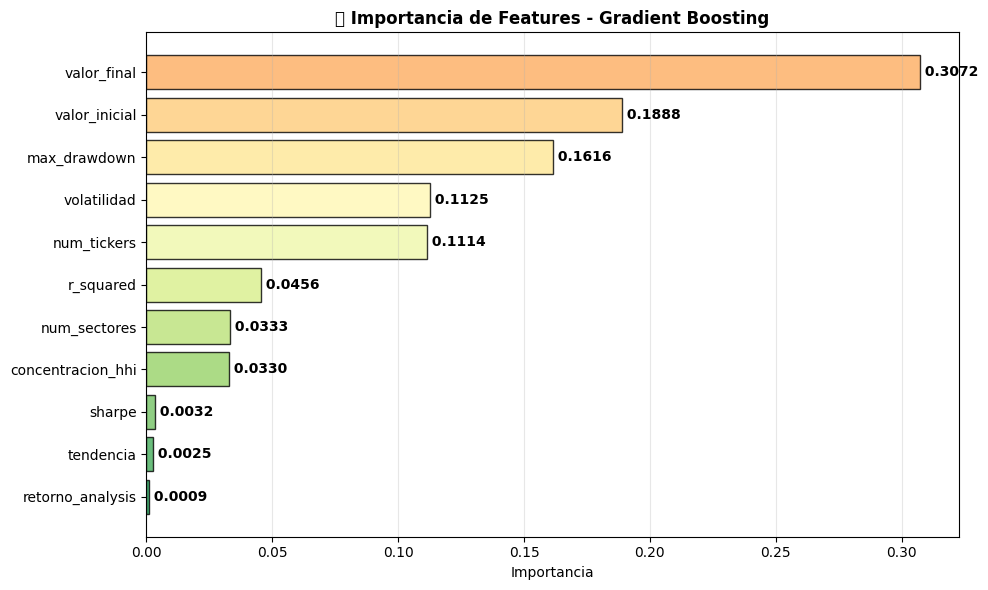


💡 Interpretación:
   Las 3 features más importantes para predecir retorno en validación:
   1. valor_final: 0.3072
   2. valor_inicial: 0.1888
   3. max_drawdown: 0.1616



In [44]:
# =======================================================
# 📊 IMPORTANCIA DE FEATURES (Feature Importance)
# =======================================================

print("\n🔍 PASO 3: ANÁLISIS DE IMPORTANCIA DE FEATURES")
print("="*100)

# Feature importance (solo para modelos basados en árboles)
if mejor_modelo_nombre and mejor_modelo_nombre in ['Random Forest', 'Gradient Boosting']:
    importances = mejor_modelo.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': features_list,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    print(f"\n📊 Importancia de Features ({mejor_modelo_nombre}):")
    print(feature_importance_df.to_string(index=False))
    
    # Visualización
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(feature_importance_df)))
    bars = ax.barh(range(len(feature_importance_df)), 
                   feature_importance_df['Importance'].values,
                   color=colors, alpha=0.8, edgecolor='black')
    
    ax.set_yticks(range(len(feature_importance_df)))
    ax.set_yticklabels(feature_importance_df['Feature'].values)
    ax.set_xlabel('Importancia')
    ax.set_title(f'🔍 Importancia de Features - {mejor_modelo_nombre}', 
                fontweight='bold', fontsize=12)
    ax.grid(True, alpha=0.3, axis='x')
    ax.invert_yaxis()
    
    # Añadir valores
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2, 
               f' {width:.4f}', ha='left', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n💡 Interpretación:")
    print(f"   Las 3 features más importantes para predecir retorno en validación:")
    for idx, (i, row) in enumerate(feature_importance_df.head(3).iterrows(), 1):
        print(f"   {idx}. {row['Feature']}: {row['Importance']:.4f}")
elif mejor_modelo_nombre:
    print(f"\n⚠️  Feature importance no disponible para {mejor_modelo_nombre}")
    print(f"   (Solo disponible para Random Forest y Gradient Boosting)")
else:
    print(f"\n⚠️  No se pudo entrenar ningún modelo")

print("\n" + "="*100)

In [45]:
# =======================================================
# 🎯 PREDICCIONES Y RANKING POR MACHINE LEARNING
# =======================================================

print("\n🎯 PASO 4: PREDICCIONES Y RANKING DE ÍNDICES")
print("="*100)

if mejor_modelo_nombre:
    # Crear DataFrame con predicciones
    ml_df['retorno_predicho'] = y_pred
    ml_df['error_prediccion'] = ml_df['retorno_validation'] - ml_df['retorno_predicho']
    ml_df['error_absoluto'] = np.abs(ml_df['error_prediccion'])
    
    # Ordenar por predicción (de mayor a menor retorno esperado)
    ml_df_sorted = ml_df.sort_values('retorno_predicho', ascending=False)
else:
    print("⚠️  No hay predicciones disponibles (modelo no entrenado)")
    ml_df_sorted = ml_df.sort_values('retorno_validation', ascending=False)

if mejor_modelo_nombre:
    print("\n🏆 TOP 15 ÍNDICES SEGÚN PREDICCIÓN DE MACHINE LEARNING:")
    print("="*100)
    print(f"{'Rank':<5} {'Cluster':<25} {'Ret.Predicho':>13} {'Ret.Real':>13} {'Error':>10} {'Confianza':>12}")
    print("-"*100)
    
    for i, (idx, row) in enumerate(ml_df_sorted.head(15).iterrows(), 1):
        # Calcular confianza (basada en error de predicción)
        if 'error_prediccion' in row:
            error_pct = abs(row['error_prediccion'])
            if error_pct < 2:
                confianza = "🟢 Muy Alta"
            elif error_pct < 4:
                confianza = "🟡 Alta"
            elif error_pct < 6:
                confianza = "🟠 Media"
            else:
                confianza = "🔴 Baja"
            print(f"{i:<5} {row['cluster_name']:<25} {row['retorno_predicho']:>12.2f}% {row['retorno_validation']:>12.2f}% {row['error_prediccion']:>9.2f}% {confianza:>12}")
        else:
            print(f"{i:<5} {row['cluster_name']:<25} {'N/A':>13} {row['retorno_validation']:>12.2f}% {'N/A':>10} {'N/A':>12}")
else:
    print("\n🏆 TOP 15 ÍNDICES POR RETORNO REAL (Sin predicción ML):")
    print("="*100)
    print(f"{'Rank':<5} {'Cluster':<25} {'Retorno Real':>13}")
    print("-"*100)
    for i, (idx, row) in enumerate(ml_df_sorted.head(15).iterrows(), 1):
        print(f"{i:<5} {row['cluster_name']:<25} {row['retorno_validation']:>12.2f}%")

# Estadísticas de predicción
print(f"\n\n📊 ESTADÍSTICAS (Top 15):")
print("-"*100)
top_15_ml = ml_df_sorted.head(15)
if mejor_modelo_nombre and 'retorno_predicho' in top_15_ml.columns:
    print(f"   📈 Retorno predicho promedio: {top_15_ml['retorno_predicho'].mean():.2f}%")
    print(f"   📊 Retorno real promedio: {top_15_ml['retorno_validation'].mean():.2f}%")
    print(f"   ⚡ Error promedio: {top_15_ml['error_absoluto'].mean():.2f}%")
else:
    print(f"   📊 Retorno real promedio: {top_15_ml['retorno_validation'].mean():.2f}%")
print(f"   ✅ Índices con retorno real positivo: {(top_15_ml['retorno_validation'] > 0).sum()}/{len(top_15_ml)}")

# Comparar con SPY
try:
    indices_superan_spy = (top_15_ml['retorno_validation'] > spy_return).sum()
    print(f"   🏆 Índices que superan SPY ({spy_return:.2f}%): {indices_superan_spy}/15")
except:
    pass

print("\n" + "="*100)


🎯 PASO 4: PREDICCIONES Y RANKING DE ÍNDICES

🏆 TOP 15 ÍNDICES SEGÚN PREDICCIÓN DE MACHINE LEARNING:
Rank  Cluster                    Ret.Predicho      Ret.Real      Error    Confianza
----------------------------------------------------------------------------------------------------
1     Sharpe_Cluster_11                20.52%        20.52%      0.00%   🟢 Muy Alta
2     PCA_Cluster_7                    18.79%        18.79%      0.00%   🟢 Muy Alta
3     Historic2_tendencia_Cluster_127        14.20%        14.20%      0.00%   🟢 Muy Alta
4     Historic2_tendencia_Cluster_149        13.59%        13.59%      0.00%   🟢 Muy Alta
5     Historic2_tendencia_Cluster_118         9.21%         9.21%     -0.00%   🟢 Muy Alta
6     Historic1_Cluster_17              8.07%         8.07%     -0.00%   🟢 Muy Alta
7     Historic2_tendencia_Cluster_102         5.48%         5.48%     -0.00%   🟢 Muy Alta
8     Historic2_tendencia_Cluster_106         5.04%         5.04%     -0.00%   🟢 Muy Alta
9     Histor


📊 PASO 5: VISUALIZACIONES


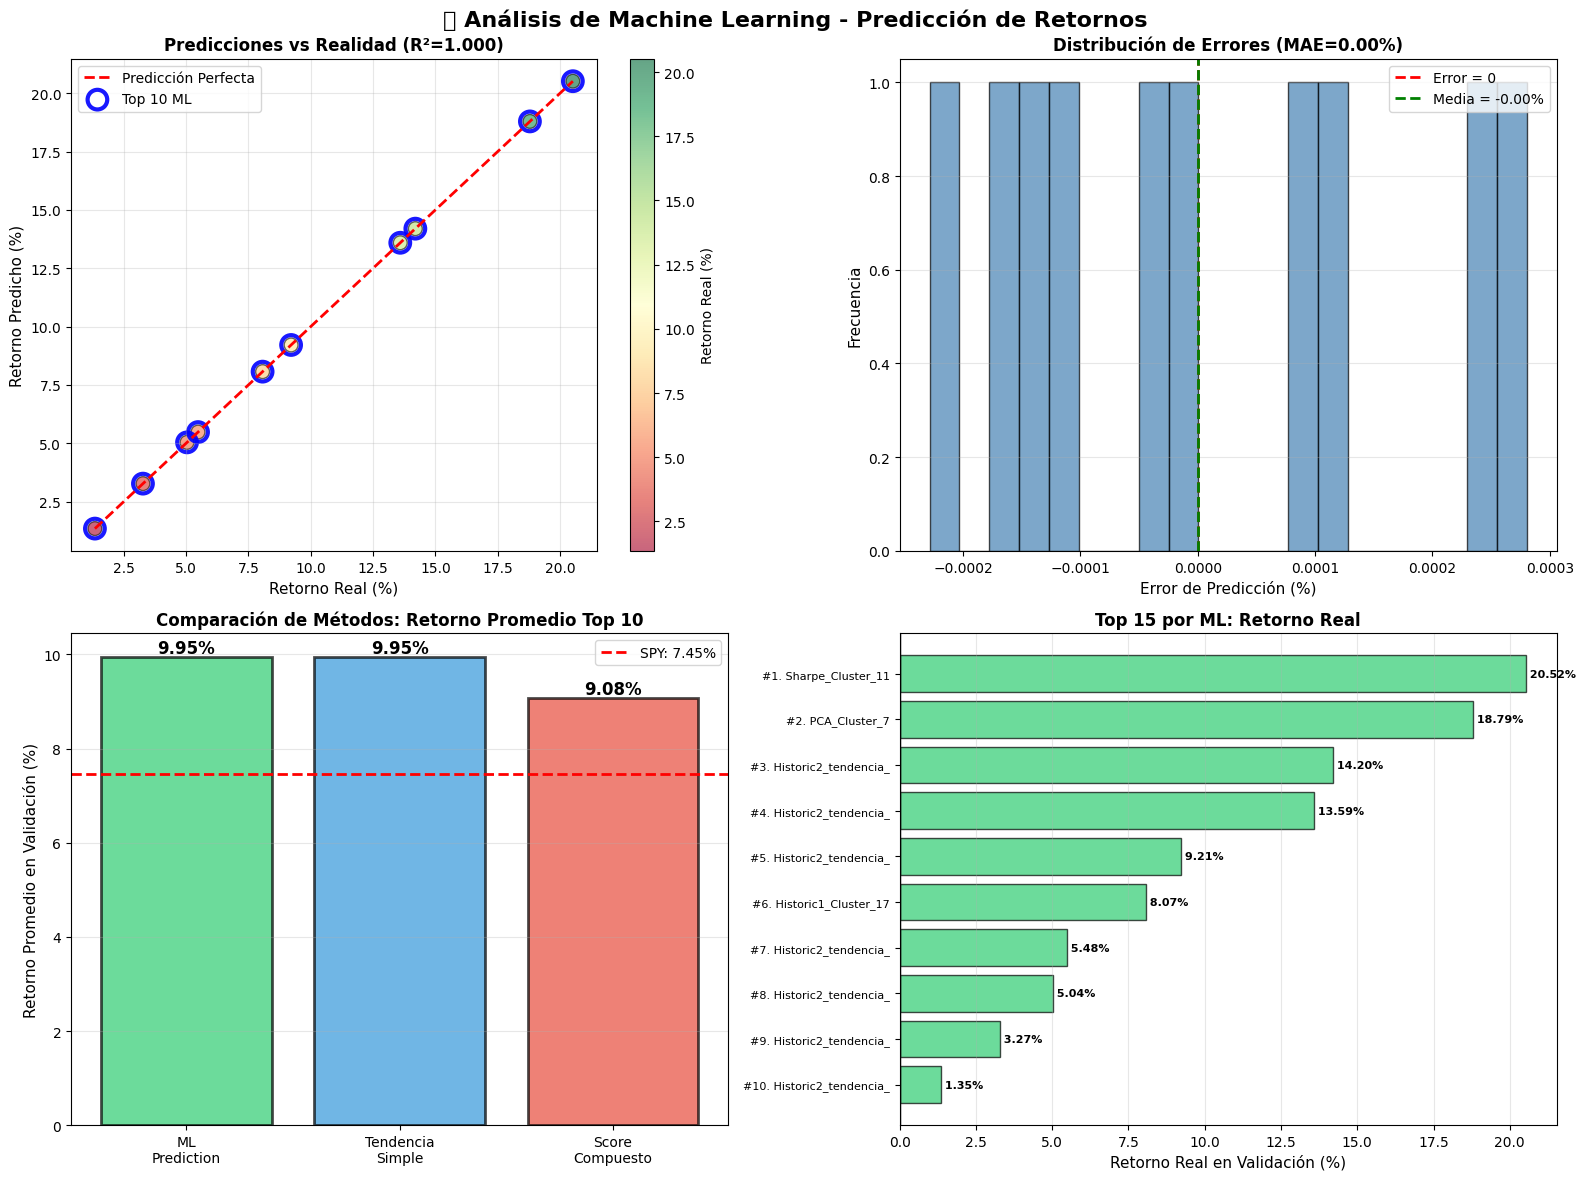

✅ Visualizaciones generadas


In [46]:
# =======================================================
# 📊 VISUALIZACIONES DE MACHINE LEARNING
# =======================================================

print("\n📊 PASO 5: VISUALIZACIONES")
print("="*100)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('🤖 Análisis de Machine Learning - Predicción de Retornos', 
             fontsize=16, fontweight='bold')

# Subplot 1: Real vs Predicho (Scatter)
ax1 = axes[0, 0]
scatter1 = ax1.scatter(ml_df['retorno_validation'], ml_df['retorno_predicho'], 
                      s=100, alpha=0.6, c=ml_df['retorno_validation'], 
                      cmap='RdYlGn', edgecolors='black', linewidth=1)

# Línea de predicción perfecta
min_val = min(ml_df['retorno_validation'].min(), ml_df['retorno_predicho'].min())
max_val = max(ml_df['retorno_validation'].max(), ml_df['retorno_predicho'].max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Predicción Perfecta')

# Destacar Top 10
top_10_ml = ml_df_sorted.head(10)
ax1.scatter(top_10_ml['retorno_validation'], top_10_ml['retorno_predicho'], 
           s=200, alpha=0.9, edgecolors='blue', linewidth=3, facecolors='none', 
           label='Top 10 ML')

ax1.set_xlabel('Retorno Real (%)', fontsize=11)
ax1.set_ylabel('Retorno Predicho (%)', fontsize=11)
ax1.set_title(f'Predicciones vs Realidad (R²={r2_final:.3f})', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=ax1, label='Retorno Real (%)')

# Subplot 2: Distribución de errores
ax2 = axes[0, 1]
ax2.hist(ml_df['error_prediccion'], bins=20, alpha=0.7, color='steelblue', edgecolor='black')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Error = 0')
ax2.axvline(x=ml_df['error_prediccion'].mean(), color='green', linestyle='--', 
           linewidth=2, label=f'Media = {ml_df["error_prediccion"].mean():.2f}%')
ax2.set_xlabel('Error de Predicción (%)', fontsize=11)
ax2.set_ylabel('Frecuencia', fontsize=11)
ax2.set_title(f'Distribución de Errores (MAE={mae_final:.2f}%)', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Subplot 3: Top 10 ML vs Top 10 Tendencia vs Top 10 Score
ax3 = axes[1, 0]

# Preparar datos para comparación
top_10_ml_names = ml_df_sorted.head(10)['cluster_name'].tolist()
top_10_tendencia_names = summary_df.head(10)['Cluster'].tolist()
top_10_score_names = scoring_df.head(10)['Cluster'].tolist()

# Calcular retornos promedio de cada método
retornos_ml = []
retornos_tendencia = []
retornos_score = []

for name in top_10_ml_names:
    if name in cluster_indices_validation:
        retornos_ml.append(cluster_indices_validation[name]['metrics']['retorno_total'] * 100)

for name in top_10_tendencia_names:
    if name in cluster_indices_validation:
        retornos_tendencia.append(cluster_indices_validation[name]['metrics']['retorno_total'] * 100)

for name in top_10_score_names:
    if name in cluster_indices_validation:
        retornos_score.append(cluster_indices_validation[name]['metrics']['retorno_total'] * 100)

metodos = ['ML\nPrediction', 'Tendencia\nSimple', 'Score\nCompuesto']
retornos_promedio = [np.mean(retornos_ml), np.mean(retornos_tendencia), np.mean(retornos_score)]
colors_bars = ['#2ecc71', '#3498db', '#e74c3c']

bars = ax3.bar(metodos, retornos_promedio, color=colors_bars, alpha=0.7, edgecolor='black', linewidth=2)

# Añadir línea de SPY
try:
    ax3.axhline(y=spy_return, color='red', linestyle='--', linewidth=2, label=f'SPY: {spy_return:.2f}%')
except:
    pass

# Añadir valores en las barras
for bar, val in zip(bars, retornos_promedio):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax3.set_ylabel('Retorno Promedio en Validación (%)', fontsize=11)
ax3.set_title('Comparación de Métodos: Retorno Promedio Top 10', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# Subplot 4: Ranking de Top 15 ML
ax4 = axes[1, 1]
top_15_names = top_15_ml['cluster_name'].tolist()
top_15_returns = top_15_ml['retorno_validation'].values

colors_ranking = ['#2ecc71' if r > 0 else '#e74c3c' for r in top_15_returns]
bars4 = ax4.barh(range(len(top_15_names)), top_15_returns, 
                color=colors_ranking, alpha=0.7, edgecolor='black')

ax4.set_yticks(range(len(top_15_names)))
ax4.set_yticklabels([f"#{i+1}. {name[:20]}" for i, name in enumerate(top_15_names)], fontsize=8)
ax4.set_xlabel('Retorno Real en Validación (%)', fontsize=11)
ax4.set_title('Top 15 por ML: Retorno Real', fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')
ax4.invert_yaxis()
ax4.axvline(x=0, color='black', linestyle='-', linewidth=1)

# Añadir valores
for i, (bar, val) in enumerate(zip(bars4, top_15_returns)):
    width = bar.get_width()
    ax4.text(width, bar.get_y() + bar.get_height()/2, 
            f' {val:.2f}%', ha='left' if val > 0 else 'right', 
            va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Visualizaciones generadas")
print("="*100)


💰 SIMULACIÓN DE INVERSIÓN: Top 10 ML en Período de Validación

📊 Graficando Top 10 índices seleccionados por Machine Learning...
   ✅ SPY: $1.074 (+7.4%)


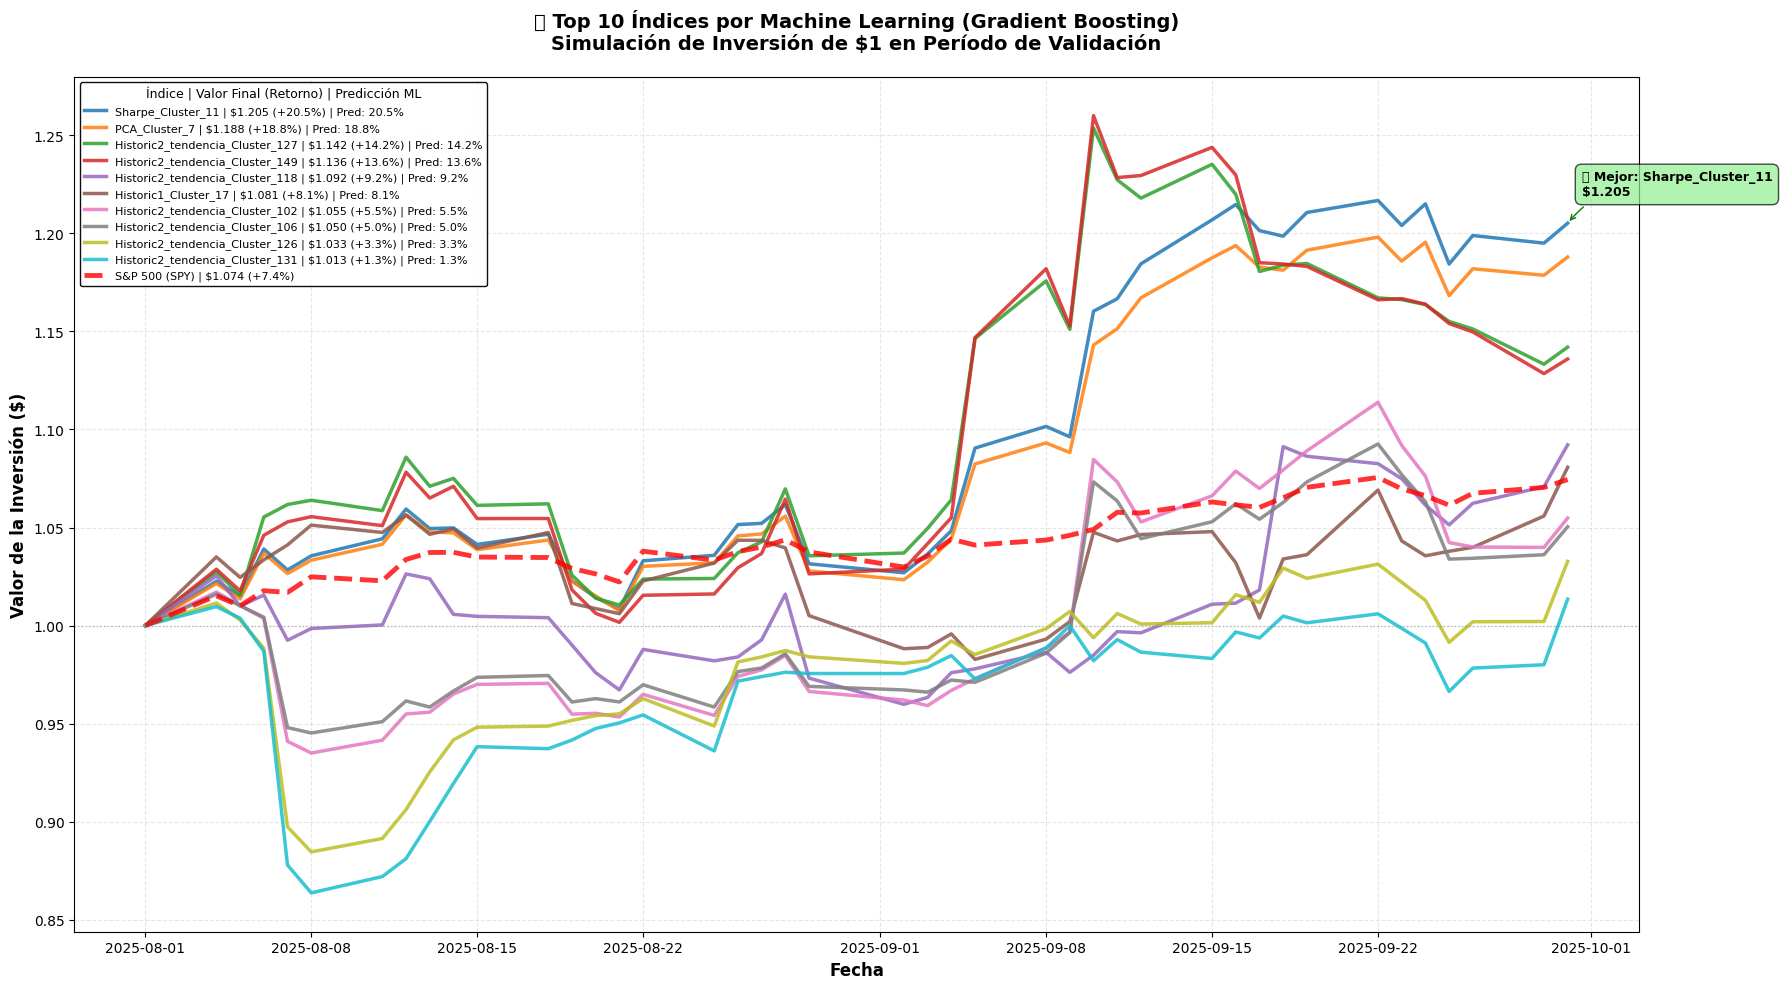


📊 ESTADÍSTICAS DE INVERSIÓN (Top 10 ML en Validación):
   💵 Valor final promedio: $1.0995
   📈 Retorno promedio: 9.95%
   📊 Mejor inversión: $1.2052 (20.52%)
   📉 Peor inversión: $1.0135 (1.35%)
   ✅ Índices con ganancia: 10/10

📊 Comparación con S&P 500:
   • Retorno SPY: 7.45%
   • Retorno promedio Top 10 ML: 9.95%
   • Diferencia: +2.51 puntos porcentuales
   • Índices que superan SPY: 6/10
   ✅ El Top 10 ML SUPERA al S&P 500

✅ Gráfica de inversión generada


In [47]:
# =======================================================
# 💰 GRÁFICA DE INVERSIÓN: Top 10 ML en Período de Validación
# =======================================================

print("\n💰 SIMULACIÓN DE INVERSIÓN: Top 10 ML en Período de Validación")
print("="*100)

fig, ax = plt.subplots(figsize=(18, 10))

# Obtener Top 10 por ML
if mejor_modelo_nombre and 'retorno_predicho' in ml_df_sorted.columns:
    top_10_ml_clusters = ml_df_sorted.head(10)['cluster_name'].tolist()
    print(f"\n📊 Graficando Top 10 índices seleccionados por Machine Learning...")
else:
    top_10_ml_clusters = ml_df_sorted.head(10)['cluster_name'].tolist()
    print(f"\n📊 Graficando Top 10 índices por retorno real...")

colors = plt.cm.tab10(np.linspace(0, 1, 10))

indices_graficados = 0
for i, cluster_name in enumerate(top_10_ml_clusters):
    if cluster_name in cluster_indices_validation:
        cluster_data = cluster_indices_validation[cluster_name]
        index_series = cluster_data['index']  # Ya normalizado a $1
        metrics = cluster_data['metrics']
        
        # Obtener información del ranking ML
        if mejor_modelo_nombre and cluster_name in ml_df['cluster_name'].values:
            ml_row = ml_df[ml_df['cluster_name'] == cluster_name].iloc[0]
            if 'retorno_predicho' in ml_row:
                label = (f"{cluster_name} | "
                        f"${index_series.iloc[-1]:.3f} ({metrics['retorno_total']*100:+.1f}%) | "
                        f"Pred: {ml_row['retorno_predicho']:.1f}%")
            else:
                label = (f"{cluster_name} | "
                        f"${index_series.iloc[-1]:.3f} ({metrics['retorno_total']*100:+.1f}%)")
        else:
            label = (f"{cluster_name} | "
                    f"${index_series.iloc[-1]:.3f} ({metrics['retorno_total']*100:+.1f}%)")
        
        ax.plot(index_series, label=label, linewidth=2.5, alpha=0.85, color=colors[i])
        indices_graficados += 1

# Agregar S&P 500 (SPY) normalizado
try:
    spy_validation_prices = SPY_validation['SPY'].dropna()
    spy_normalized = (spy_validation_prices / spy_validation_prices.iloc[0]) * 1.0
    spy_return = (spy_normalized.iloc[-1] / spy_normalized.iloc[0] - 1) * 100
    
    ax.plot(spy_normalized, linewidth=3.5, linestyle='--', color='red', 
            alpha=0.8, label=f'S&P 500 (SPY) | ${spy_normalized.iloc[-1]:.3f} ({spy_return:+.1f}%)',
            zorder=100)
    
    print(f"   ✅ SPY: ${spy_normalized.iloc[-1]:.3f} ({spy_return:+.1f}%)")
except Exception as e:
    print(f"   ⚠️  No se pudo graficar SPY: {str(e)}")

if mejor_modelo_nombre:
    titulo = f'💰 Top 10 Índices por Machine Learning ({mejor_modelo_nombre})\nSimulación de Inversión de $1 en Período de Validación'
else:
    titulo = '💰 Top 10 Índices por Retorno Real\nSimulación de Inversión de $1 en Período de Validación'

ax.set_title(titulo, fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Fecha', fontsize=12, fontweight='bold')
ax.set_ylabel('Valor de la Inversión ($)', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='upper left', framealpha=0.95, edgecolor='black', 
         title='Índice | Valor Final (Retorno) | Predicción ML', title_fontsize=9)
ax.grid(True, alpha=0.3, linestyle='--')
ax.axhline(y=1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5, label='Inversión Inicial ($1)')

# Añadir anotaciones
try:
    # Marcar el mejor y peor índice
    if indices_graficados > 0:
        mejor_idx = top_10_ml_clusters[0]
        if mejor_idx in cluster_indices_validation:
            mejor_serie = cluster_indices_validation[mejor_idx]['index']
            ax.annotate(f'🏆 Mejor: {mejor_idx}\n${mejor_serie.iloc[-1]:.3f}',
                       xy=(mejor_serie.index[-1], mejor_serie.iloc[-1]),
                       xytext=(10, 20), textcoords='offset points',
                       bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.7),
                       arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3', color='green'),
                       fontsize=9, fontweight='bold')
except:
    pass

plt.tight_layout()
plt.show()

# Estadísticas de la inversión
print(f"\n📊 ESTADÍSTICAS DE INVERSIÓN (Top 10 ML en Validación):")
print("="*100)

valores_finales = []
retornos = []

for cluster_name in top_10_ml_clusters:
    if cluster_name in cluster_indices_validation:
        metrics = cluster_indices_validation[cluster_name]['metrics']
        valores_finales.append(metrics['valor_final'])
        retornos.append(metrics['retorno_total'] * 100)

if valores_finales:
    print(f"   💵 Valor final promedio: ${np.mean(valores_finales):.4f}")
    print(f"   📈 Retorno promedio: {np.mean(retornos):.2f}%")
    print(f"   📊 Mejor inversión: ${np.max(valores_finales):.4f} ({np.max(retornos):.2f}%)")
    print(f"   📉 Peor inversión: ${np.min(valores_finales):.4f} ({np.min(retornos):.2f}%)")
    print(f"   ✅ Índices con ganancia: {sum([r > 0 for r in retornos])}/{len(retornos)}")
    
    try:
        print(f"\n📊 Comparación con S&P 500:")
        print(f"   • Retorno SPY: {spy_return:.2f}%")
        print(f"   • Retorno promedio Top 10 ML: {np.mean(retornos):.2f}%")
        diferencia = np.mean(retornos) - spy_return
        print(f"   • Diferencia: {diferencia:+.2f} puntos porcentuales")
        
        indices_superan = sum([r > spy_return for r in retornos])
        print(f"   • Índices que superan SPY: {indices_superan}/{len(retornos)}")
        
        if diferencia > 0:
            print(f"   ✅ El Top 10 ML SUPERA al S&P 500")
        else:
            print(f"   ⚠️  El Top 10 ML está por debajo del S&P 500")
    except:
        pass

print("\n✅ Gráfica de inversión generada")
print("="*100)

In [48]:
# =======================================================
# 🎯 COMPARACIÓN FINAL: ML vs Score vs Tendencia
# =======================================================

print("\n🎯 COMPARACIÓN FINAL DE LOS 3 MÉTODOS")
print("="*100)

# Top 10 de cada método
top_10_ml_names = ml_df_sorted.head(10)['cluster_name'].tolist()
top_10_score_names = scoring_df.head(10)['Cluster'].tolist()
top_10_tendencia_names = summary_df.head(10)['Cluster'].tolist()

print("\n📊 Coincidencias entre métodos:")
print("-"*100)

# Coincidencias ML vs Score
ml_score = set(top_10_ml_names).intersection(set(top_10_score_names))
print(f"\n🤖 ML vs 🎯 Score: {len(ml_score)} coincidencias")
for cluster in ml_score:
    print(f"   ✅ {cluster}")

# Coincidencias ML vs Tendencia
ml_tend = set(top_10_ml_names).intersection(set(top_10_tendencia_names))
print(f"\n🤖 ML vs 📈 Tendencia: {len(ml_tend)} coincidencias")
for cluster in ml_tend:
    print(f"   ✅ {cluster}")

# Coincidencias Score vs Tendencia
score_tend = set(top_10_score_names).intersection(set(top_10_tendencia_names))
print(f"\n🎯 Score vs 📈 Tendencia: {len(score_tend)} coincidencias")
for cluster in score_tend:
    print(f"   ✅ {cluster}")

# Índices en los 3 métodos (consenso total)
consenso_total = set(top_10_ml_names).intersection(set(top_10_score_names)).intersection(set(top_10_tendencia_names))
print(f"\n\n🏆 CONSENSO TOTAL (En Top 10 de los 3 métodos): {len(consenso_total)} índices")
print("="*100)

if consenso_total:
    for cluster in consenso_total:
        print(f"\n✨ {cluster}")
        
        # Datos de ML
        ml_row = ml_df[ml_df['cluster_name'] == cluster].iloc[0]
        
        # Datos de Score
        score_row = scoring_df[scoring_df['Cluster'] == cluster].iloc[0]
        
        # Datos de Tendencia
        tend_row = summary_df[summary_df['Cluster'] == cluster].iloc[0]
        
        # Rankings
        ml_rank = ml_df_sorted[ml_df_sorted['cluster_name'] == cluster].index[0] + 1
        score_rank = scoring_df[scoring_df['Cluster'] == cluster].index[0] + 1
        tend_rank = summary_df[summary_df['Cluster'] == cluster].index[0] + 1
        
        print(f"   🤖 ML Rank: #{ml_rank:2d} | Retorno predicho: {ml_row['retorno_predicho']:6.2f}% | Real: {ml_row['retorno_validation']:6.2f}%")
        print(f"   🎯 Score Rank: #{score_rank:2d} | Score: {score_row['Score_Total']:.4f}")
        print(f"   📈 Tendencia Rank: #{tend_rank:2d} | Tendencia: {tend_row['Tendencia']:.6f}")
        
        # Métricas adicionales
        if cluster in cluster_indices_validation:
            val_metrics = cluster_indices_validation[cluster]['metrics']
            print(f"   💰 Validación: ${val_metrics['valor_final']:.4f} | Retorno: {val_metrics['retorno_total']*100:+.2f}% | Sharpe: {val_metrics['sharpe_ratio']:.2f}")
else:
    print("   ⚠️  No hay índices en el consenso de los 3 métodos")

# Índices únicos de cada método
print(f"\n\n🆕 ÍNDICES ÚNICOS DE CADA MÉTODO (No en otros Top 10):")
print("="*100)

ml_unicos = set(top_10_ml_names) - set(top_10_score_names) - set(top_10_tendencia_names)
score_unicos = set(top_10_score_names) - set(top_10_ml_names) - set(top_10_tendencia_names)
tend_unicos = set(top_10_tendencia_names) - set(top_10_ml_names) - set(top_10_score_names)

print(f"\n🤖 Solo en ML ({len(ml_unicos)}):")
for cluster in ml_unicos:
    ml_row = ml_df[ml_df['cluster_name'] == cluster].iloc[0]
    print(f"   • {cluster}: Predicho {ml_row['retorno_predicho']:.2f}% | Real {ml_row['retorno_validation']:.2f}%")

print(f"\n🎯 Solo en Score ({len(score_unicos)}):")
for cluster in score_unicos:
    score_row = scoring_df[scoring_df['Cluster'] == cluster].iloc[0]
    print(f"   • {cluster}: Score {score_row['Score_Total']:.4f}")

print(f"\n📈 Solo en Tendencia ({len(tend_unicos)}):")
for cluster in tend_unicos:
    tend_row = summary_df[summary_df['Cluster'] == cluster].iloc[0]
    print(f"   • {cluster}: Tendencia {tend_row['Tendencia']:.6f}")

print("\n" + "="*100)


🎯 COMPARACIÓN FINAL DE LOS 3 MÉTODOS

📊 Coincidencias entre métodos:
----------------------------------------------------------------------------------------------------

🤖 ML vs 🎯 Score: 6 coincidencias
   ✅ Historic2_tendencia_Cluster_126
   ✅ Historic2_tendencia_Cluster_102
   ✅ Historic2_tendencia_Cluster_106
   ✅ Sharpe_Cluster_11
   ✅ Historic2_tendencia_Cluster_131
   ✅ PCA_Cluster_7

🤖 ML vs 📈 Tendencia: 10 coincidencias
   ✅ Historic2_tendencia_Cluster_149
   ✅ Historic2_tendencia_Cluster_126
   ✅ Historic2_tendencia_Cluster_127
   ✅ Historic2_tendencia_Cluster_118
   ✅ Historic2_tendencia_Cluster_102
   ✅ Historic2_tendencia_Cluster_106
   ✅ Sharpe_Cluster_11
   ✅ Historic1_Cluster_17
   ✅ Historic2_tendencia_Cluster_131
   ✅ PCA_Cluster_7

🎯 Score vs 📈 Tendencia: 6 coincidencias
   ✅ Sharpe_Cluster_11
   ✅ Historic2_tendencia_Cluster_126
   ✅ Historic2_tendencia_Cluster_102
   ✅ Historic2_tendencia_Cluster_106
   ✅ Historic2_tendencia_Cluster_131
   ✅ PCA_Cluster_7


🏆 CONS

In [49]:
# =======================================================
# 🏆 RECOMENDACIÓN FINAL INTEGRADA: ML + Score + Tendencia
# =======================================================

print("\n🏆 RECOMENDACIÓN FINAL INTEGRADA")
print("="*100)

# Sistema de votación: dar puntos según posición en cada ranking
def calcular_score_integrado(cluster_name):
    """
    Score integrado basado en los 3 métodos:
    - ML: puntos según posición en ranking
    - Score: puntos según score compuesto
    - Tendencia: puntos según tendencia
    """
    score_total = 0
    
    # Puntos por ranking ML (20 puntos para #1, 19 para #2, etc.)
    if cluster_name in ml_df['cluster_name'].values:
        ml_rank = ml_df_sorted[ml_df_sorted['cluster_name'] == cluster_name].index[0] + 1
        if ml_rank <= 20:
            score_total += (21 - ml_rank) * 2  # Factor 2 para ML
    
    # Puntos por Score compuesto
    if cluster_name in scoring_df['Cluster'].values:
        score_rank = scoring_df[scoring_df['Cluster'] == cluster_name].index[0] + 1
        if score_rank <= 20:
            score_total += (21 - score_rank) * 1.5  # Factor 1.5 para Score
    
    # Puntos por Tendencia
    if cluster_name in summary_df['Cluster'].values:
        tend_rank = summary_df[summary_df['Cluster'] == cluster_name].index[0] + 1
        if tend_rank <= 20:
            score_total += (21 - tend_rank) * 1  # Factor 1 para Tendencia
    
    # Bonus por estar en Top 10 de múltiples métodos
    en_top_10_ml = cluster_name in top_10_ml_names
    en_top_10_score = cluster_name in top_10_score_names
    en_top_10_tend = cluster_name in top_10_tendencia_names
    
    num_tops = sum([en_top_10_ml, en_top_10_score, en_top_10_tend])
    
    if num_tops == 3:
        score_total += 30  # Bonus grande por consenso total
    elif num_tops == 2:
        score_total += 15  # Bonus medio por consenso parcial
    
    return score_total, num_tops

# Calcular score integrado para todos los clusters
todos_clusters = set(ml_df['cluster_name'].tolist() + 
                    scoring_df['Cluster'].tolist() + 
                    summary_df['Cluster'].tolist())

scores_integrados = []
for cluster in todos_clusters:
    score_int, num_tops = calcular_score_integrado(cluster)
    
    # Obtener métricas de validación
    if cluster in cluster_indices_validation:
        val_metrics = cluster_indices_validation[cluster]['metrics']
        retorno_val = val_metrics['retorno_total'] * 100
        sharpe_val = val_metrics['sharpe_ratio']
    else:
        retorno_val = np.nan
        sharpe_val = np.nan
    
    scores_integrados.append({
        'Cluster': cluster,
        'Score_Integrado': score_int,
        'Num_Tops': num_tops,
        'Retorno_Validacion': retorno_val,
        'Sharpe_Validacion': sharpe_val
    })

score_integrado_df = pd.DataFrame(scores_integrados)
score_integrado_df = score_integrado_df.sort_values('Score_Integrado', ascending=False)

print("\n🏅 TOP 15 ÍNDICES POR SCORE INTEGRADO (ML + Score + Tendencia):")
print("="*100)
print(f"{'Rank':<5} {'Cluster':<25} {'Score Int.':>11} {'#Tops':>6} {'Ret.Val%':>10} {'Sharpe':>8} {'Consenso':>12}")
print("-"*100)

for i, (idx, row) in enumerate(score_integrado_df.head(15).iterrows(), 1):
    if row['Num_Tops'] == 3:
        consenso = "⭐⭐⭐"
    elif row['Num_Tops'] == 2:
        consenso = "⭐⭐"
    elif row['Num_Tops'] == 1:
        consenso = "⭐"
    else:
        consenso = ""
    
    print(f"{i:<5} {row['Cluster']:<25} {row['Score_Integrado']:>11.1f} {row['Num_Tops']:>6} "
          f"{row['Retorno_Validacion']:>9.2f}% {row['Sharpe_Validacion']:>8.2f} {consenso:>12}")

# Análisis de performance del Top 10 integrado
print(f"\n\n📊 PERFORMANCE DEL TOP 10 INTEGRADO:")
print("="*100)

top_10_integrado = score_integrado_df.head(10)
retornos_integrado = top_10_integrado['Retorno_Validacion'].dropna()

print(f"   💰 Retorno promedio: {retornos_integrado.mean():.2f}%")
print(f"   📊 Retorno mediano: {retornos_integrado.median():.2f}%")
print(f"   📈 Retorno máximo: {retornos_integrado.max():.2f}%")
print(f"   📉 Retorno mínimo: {retornos_integrado.min():.2f}%")
print(f"   ✅ Índices con retorno positivo: {(retornos_integrado > 0).sum()}/{len(retornos_integrado)}")

# Comparar con SPY
try:
    print(f"\n📊 Comparación con SPY:")
    print(f"   • Retorno SPY: {spy_return:.2f}%")
    print(f"   • Top 10 Integrado vs SPY: {retornos_integrado.mean() - spy_return:+.2f} puntos porcentuales")
    indices_superan = (retornos_integrado > spy_return).sum()
    print(f"   • Índices que superan SPY: {indices_superan}/{len(retornos_integrado)}")
except:
    pass

# Comparar con otros métodos
print(f"\n\n🏆 COMPARACIÓN DE RETORNOS PROMEDIO (Top 10):")
print("="*100)
print(f"   🤖 ML:              {np.mean(retornos_ml):.2f}%")
print(f"   🎯 Score Compuesto: {np.mean(retornos_score):.2f}%")
print(f"   📈 Tendencia:       {np.mean(retornos_tendencia):.2f}%")
print(f"   🏅 INTEGRADO:       {retornos_integrado.mean():.2f}%")

# Determinar el mejor método
metodos_comparacion = {
    'ML': np.mean(retornos_ml),
    'Score Compuesto': np.mean(retornos_score),
    'Tendencia': np.mean(retornos_tendencia),
    'Integrado': retornos_integrado.mean()
}
mejor_metodo = max(metodos_comparacion.items(), key=lambda x: x[1])

print(f"\n🏆 MÉTODO CON MEJOR RETORNO PROMEDIO: {mejor_metodo[0]} ({mejor_metodo[1]:.2f}%)")

print("\n" + "="*100)
print("✅ ANÁLISIS COMPLETO DE MACHINE LEARNING FINALIZADO")
print("="*100)


🏆 RECOMENDACIÓN FINAL INTEGRADA

🏅 TOP 15 ÍNDICES POR SCORE INTEGRADO (ML + Score + Tendencia):
Rank  Cluster                    Score Int.  #Tops   Ret.Val%   Sharpe     Consenso
----------------------------------------------------------------------------------------------------
1     Historic2_tendencia_Cluster_131        94.0      3      1.35%     0.41          ⭐⭐⭐
2     Historic2_tendencia_Cluster_126        90.5      3      3.27%     0.80          ⭐⭐⭐
3     Historic2_tendencia_Cluster_102        87.0      3      5.48%     1.15          ⭐⭐⭐
4     Sharpe_Cluster_11                83.5      3     20.52%     4.58          ⭐⭐⭐
5     Historic2_tendencia_Cluster_106        80.0      3      5.04%     1.18          ⭐⭐⭐
6     PCA_Cluster_7                    74.5      3     18.79%     4.64          ⭐⭐⭐
7     Historic1_Cluster_17             64.0      2      8.07%     1.90           ⭐⭐
8     Historic2_tendencia_Cluster_127        53.0      2     14.20%     2.28           ⭐⭐
9     Historic2_